In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import plotly.graph_objects as go
import json

In [2]:
from src.datasets.datamodules import DataModule
from src.my_model.transformer import *

In [3]:
publication = False
# if publication:
#     plt.style.use('seaborn-whitegrid')
#     plt.rcParams['font.family'] = 'serif'
#     plt.rcParams['font.serif'] = ['Times New Roman']
#     plt.rcParams['font.size'] = 12
#     plt.rcParams['axes.titlesize'] = 12
#     plt.rcParams['axes.labelsize'] = 12
#     plt.rcParams['xtick.labelsize'] = 12
#     plt.rcParams['ytick.labelsize'] = 12
#     plt.rcParams['legend.fontsize'] = 12
#     plt.rcParams['figure.titlesize'] = 12
#     plt.rcParams['figure.figsize'] = (6, 4)
#     plt.rcParams['lines.linewidth'] = 1.5
#     plt.rcParams['lines.markersize'] = 6
#     plt.rcParams['axes.linewidth'] = 1.5
#     plt.rcParams['legend.frameon'] = False
#     plt.rcParams['legend.handlelength'] = 1.5
#     plt.rcParams['legend.handleheight'] = 0.5
#     plt.rcParams['legend.borderpad'] = 0.5
#     plt.rcParams['legend.borderaxespad'] = 0.5
#     plt.rcParams['legend.labelspacing'] = 0.5
#     plt.rcParams['legend.columnspacing'] = 1.0
#     plt.rcParams['legend.loc'] = 'best'
#     plt.rcParams['legend.framealpha'] = 0.5

In [4]:
config = {}

In [5]:
# test_dir = "odd_output_muons_1"
# test_dir = "odd_output_muons_1_single_charge"
# test_dir = "test"
# test_dir = "geant4_test_2"
test_dir = "odd_output_muons_2"

In [6]:
dataset_name = "Acts_muons"
if "TrackML" in dataset_name:
    dataset_type = "tml"
elif "Acts" in dataset_name:
    dataset_type = "acts"
if dataset_name == "Acts_muons":
    dataset_dir = Path("Data/Acts/Muons")

In [7]:
if dataset_name == "Acts_muons":
    config = {
        "min_hits": 7,
        "particle_types": [13, -13],
        "max_abs_eta": 1,
        # "max_abs_eta": 3,
    }
    config["sort_by_radius"] = True
    config["truth_position"] = True
    # config["verbose"] = True

In [8]:
config["input_variables"] = ["tx", "ty", "tz"]
# config["input_variables"] = ["tr", "tphi", "tz"]
config["input_variables"] = ["tr", "dphi", "tz"]
# config["input_variables"] = ["tx", "ty", "tz", "pT_circle_estimate"]


config["output_variables"] = ['pT', 'pz']
config["output_variables"] = ["qopT", "pz"]
# config["output_variables"] = ["qpT", "pz"]

In [9]:
import pandas as pd

# Creating a structured dataframe for the models
model_data = [
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/TrackML/version_533", None, None),
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/TrackML/version_648", None, None), # eta 1 # no z symmetry
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/TrackML/version_652", None, None), # eta 1 # z symmetry
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_5", None, None),
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_4", None, None), # eta 1
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_26", None, None), # eta 3; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_28", None, None), # eta 3; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_63", None, None), # eta 3; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_69", None, None), # eta 3; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_72", None, None), # eta 3; min 7 hits; padding issue
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_121", None, None), # eta 3; min 7 hits
    (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_113", None, None), # eta 1; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_85", None, None), # eta 1; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_89", None, None), # eta 1; min 7 hits; with scattered
]

# Creating a DataFrame
model_df = pd.DataFrame(
    model_data,
    columns=[
        "input_variables",
        "dataset_name",
        "output_variables",
        "mse_dir",
        "mse_inv_dir",
        "qloss_dir",
    ],
)
model_df["input_variables"] = model_df["input_variables"].apply(tuple)
model_df["output_variables"] = model_df["output_variables"].apply(tuple)

In [10]:
# Function to retrieve available models based on input configuration, dataset name, and DataFrame
def get_available_models(model_df, config_input, dataset_name, config_output):
    config_input = tuple(config_input)
    config_output = tuple(config_output)

    filtered_df = model_df[
        (model_df["input_variables"] == config_input)
        & (model_df["dataset_name"] == dataset_name)
        & (model_df["output_variables"] == config_output)
    ]

    if not filtered_df.empty:
        model_dict = {
            "mse_dir": filtered_df.iloc[0]["mse_dir"],
            "mse_inv_dir": filtered_df.iloc[0]["mse_inv_dir"],
            "qloss_dir": filtered_df.iloc[0]["qloss_dir"],
        }
        return {
            k: v for k, v in model_dict.items() if v is not None
        }  # Remove None values
    else:
        return {}


available_models = get_available_models(
    model_df, config["input_variables"], dataset_name, config["output_variables"]
)
print(available_models)

{'mse_dir': 'Models/ActsODD/version_113'}


In [11]:
models_dir = {
    "MSE": Path(available_models["mse_dir"]),
}
if "qloss_dir" in available_models:
    models_dir["QLoss"] = Path(available_models["qloss_dir"])
if "mse_inv_dir" in available_models:
    models_dir["MSE_inv"] = Path(available_models["mse_inv_dir"])

In [12]:
# Define models. (Assumes that p_pred_mse_list and p_pred_qloss_list are defined externally.)
models = {
    "MSE": {
        "color": "skyblue",
        "cmap": "Blues",
        "label": "MSE",
        "marker": "o",
    },
}
if "QLoss" in models_dir:
    models["QLoss"] = {
        "color": "coral",
        "cmap": "Reds",
        "label": "Quantile Loss",
        "marker": "^",
    }

In [13]:
from src.analysis.utils import (
    get_model_checkpoint_path,
    get_config,
    validate_model_config,
    compute_track_resolution,
)

In [14]:
mse_config = get_config(models_dir["MSE"])
print("MSE config:", mse_config)
validate_model_config(mse_config, config, dataset_dir=dataset_dir, criterion="mse", allow_other_datasets=True)

MSE config: {'seed_everything': 0, 'trainer': {'accelerator': 'auto', 'strategy': 'auto', 'devices': 'auto', 'num_nodes': 1, 'precision': 32, 'logger': [{'class_path': 'lightning.pytorch.loggers.TensorBoardLogger', 'init_args': {'save_dir': 'Models/ActsODD', 'name': 'lightning_logs', 'version': None, 'log_graph': False, 'default_hp_metric': False, 'prefix': '', 'sub_dir': None, 'comment': '', 'purge_step': None, 'max_queue': 10, 'flush_secs': 120, 'filename_suffix': ''}}], 'callbacks': [{'class_path': 'lightning.pytorch.callbacks.LearningRateMonitor', 'init_args': {'logging_interval': 'step', 'log_momentum': False, 'log_weight_decay': False}}, {'class_path': 'src.utils.ParmSummary'}, {'class_path': 'lightning.pytorch.callbacks.ModelCheckpoint', 'init_args': {'dirpath': None, 'filename': 'model-{epoch:03d}-{val_loss:.3e}', 'monitor': 'val_loss', 'verbose': False, 'save_last': True, 'save_top_k': 1, 'save_weights_only': False, 'mode': 'min', 'auto_insert_metric_name': True, 'every_n_trai

In [15]:
# Load models
for model in models_dir:
    if model not in models:
        print(f"Skipping {model} model (not defined in models)")
        continue
    print(f"Loading {model} model")
    ml_model_path = get_model_checkpoint_path(models_dir[model])[0]
    # _instantiator is a function that is called to instantiate the model
    # Here the models have been trained using cli raising an error if _instantiator is not None
    ml_model = TrackFormer.load_from_checkpoint(
        checkpoint_path=ml_model_path, _instantiator=None, metric="sign",
    )
    ml_model.eval().to("cpu")
    ml_model_ = torch.load(ml_model_path, map_location="cpu")
    print(list(ml_model_['callbacks'].values())[0])

    # ml_model_ = torch.load(Path("/".join(str(ml_model_path).split("/")[:-1]) + "/last-v1.ckpt"), map_location="cpu")
    # ml_model_ = torch.load(Path("/".join(str(ml_model_path).split("/")[:-1]) + "/last.ckpt"), map_location="cpu")
    # print(list(ml_model_['callbacks'].values())[0])
    # print(ml_model_)
    print(ml_model)
    models[model]["model"] = ml_model

Loading MSE model
Found 1 checkpoints in Models/ActsODD/version_113/checkpoints
{'monitor': 'val_loss', 'best_model_score': tensor(0.0002), 'best_model_path': 'Models/ActsODD/lightning_logs/version_113/checkpoints/model-epoch=997-val_loss=1.972e-04.ckpt', 'current_score': tensor(0.0002), 'dirpath': 'Models/ActsODD/lightning_logs/version_113/checkpoints', 'best_k_models': {'Models/ActsODD/lightning_logs/version_113/checkpoints/model-epoch=997-val_loss=1.972e-04.ckpt': tensor(0.0002)}, 'kth_best_model_path': 'Models/ActsODD/lightning_logs/version_113/checkpoints/model-epoch=997-val_loss=1.972e-04.ckpt', 'kth_value': tensor(0.0002), 'last_model_path': 'Models/ActsODD/lightning_logs/version_113/checkpoints/last.ckpt'}
TrackFormer(
  (embedding): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=3, out_features=32, bias=True)
    (2): LeakyReLU(negative_slope=0.01, inplace=True)
    (3): Linear(in_features=32, out_features=32, bias=True)
  )
  (transformer): Tra

/tmp/ipykernel_63674/1146144803.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ml_model_ = torch.load(ml_model_path, map_location="cpu")


In [16]:
variable_labels = {
    "tx": r"x_{truth}",
    "ty": r"y_{truth}",
    "tz": r"z_{truth}",
    "tr": r"r_{truth}",
    "tphi": r"\varphi_{truth}",
    "dphi": r"\Delta\varphi",
    "pT": "p_T",
    # "qopT": r"\frac{q}{p_T}",
    "qopT": "q/p_T",
    "qpT": "q*p_T",
    "pz": "p_z",
    "pT_circle_estimate": "p_T (circle estimate)",
}

# variable_filenames is a reverse mapping of variable_labels
variable_filenames = {v: k for k, v in variable_labels.items()}

variable_units = {
    "tx": "mm",
    "ty": "mm",
    "tz": "mm",
    "tr": "mm",
    "tphi": "rad",
    "dphi": "rad",
    "pT": "GeV",
    "qopT": "1/GeV",
    "qpT": "GeV",
    "pz": "GeV",
}

In [17]:
title_suffix = ""

# if publication:
#     title_suffix += r"$\mathrm{(TrackML)}$"
# else:
#     title_suffix += r"$\mathrm{(TrackML , \textit{zenodo})}$"
#     # title_suffix += r"$\mathrm{(Acts)}$"
#     # title_suffix += r"$\mathrm{(Acts \, \textit{zenodo})}$"
#     # title_suffix += r"$\mathrm{(Acts \, \textit{zenodo \, full})}$"

if not publication:
    # Add input and output variables to the title suffix
    title_suffix += (
        f" ((${'$, $'.join([variable_labels[var] for var in config['input_variables']])}$)"
    )
    title_suffix += r" $ \to $ "
    title_suffix += (
        f"(${'$, $'.join([variable_labels[var] for var in config['output_variables']])}$))"
    )

In [18]:
output_dir = Path("Results/TrackML/")
if dataset_type == "acts" or True:
    output_dir = Path("Results/ActsODD/")

input_variables = "".join(config["input_variables"]).replace("t", "")

output_variables = "_".join(config["output_variables"])

experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_{dataset_name}"
# experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_{dataset_name}_full_dataset"
# experiment_name += "_batch_size_2048"
# experiment_name += "_eta_4"
# experiment_name += "_eta_3"
experiment_name += f"_eta_{config['max_abs_eta']}"
# experiment_name += "_eta_1"
# experiment_name += "_trained_eta_1"
# experiment_name += "_trained_eta_3"
# experiment_name += "_trained_TrackML"
# experiment_name += "_trained_TrackML_first"
# experiment_name += "_z_symmetry"
experiment_name += "_trained_ODD_full"
# experiment_name += "_" + "_".join(test_dir.split("_")[-2:])  # Use the last two parts of the test_dir name
experiment_name += "_" + test_dir  # Use the last two parts of the test_dir name
# experiment_name += "_e_32_h_8"
# experiment_name += "_e_128_h_2"
# experiment_name += "_trained_7_hits"
# experiment_name += "_huber"
# experiment_name += "_trained_with_scat"
# experiment_name += "_huber_resolution_e_32_h_2"
# experiment_name += "_huber_resolution_huber_e_32_h_2"
# experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_no_scat_{dataset_name}_e_128_h_2_no_droupout"

output_dir = output_dir / experiment_name

# Create the output directory if it does not exist
output_dir.mkdir(exist_ok=True, parents=True)

In [19]:
# Instantiate the DataModule num_workers=16)
# dataset_wrapper = DataModule(dataset_type="tml", dataset_dir="Data/Tml/trackml_100_events_splits") # 20 000 particles
dataset_wrapper = DataModule(
    dataset_type=dataset_type,
    dataset_dir=dataset_dir,
    use_wrapper=False,
    kwargs=config,
)  # 1 404 273 particles

# dataset_wrapper.setup(stage="test")
dataset_wrapper.test_dataset = dataset_wrapper._create_dataset(test_dir)
tl = dataset_wrapper.test_dataloader()
# 1 min 41.4 s

In [20]:
def compute_resolution_bins(peta, bins, pi_true_values, pi_pred_values, model_data_bins, model_name="MSE"):
    # Initialize the model data bins dictionary if it doesn't exist
    model_data_bins[model_name] = []

    # Loop over each bin
    for i in range(len(bins) - 1):
        # Get the indices of the points in this bin
        bin_indices = np.where((peta >= bins[i]) & (peta < bins[i + 1]))[0]
        # Get the values in this bin
        pi_pred_values_bin = pi_pred_values[bin_indices]
        pi_true_values_bin = pi_true_values[bin_indices]
        # If there are no values in this bin, skip it
        if len(pi_pred_values_bin) == 0 or len(pi_true_values_bin) == 0:
            # Append the bin data to the model data
            model_data_bins[model_name].append((np.nan, np.nan, 0, np.nan, np.nan, np.nan))
            continue
        bin_values, removed_outliers_bin = (
                        compute_track_resolution(
                            pi_true_values_bin,
                            pi_pred_values_bin,
                        )
                    )

        # Compute the mean and std of the values in this bin
        n_bins = 100
        # n_bins = 20
        n, model_bins = np.histogram(
            bin_values, bins=n_bins, density=True#, range=fit_range
        )
        # Fit a Gaussian to the histogram.
        from scipy.stats import norm
        from scipy.optimize import curve_fit
        if not all(np.isnan(val) for val in n):
            param_model, cov_model = curve_fit(
            norm.pdf,
            model_bins[:-1],
            n,
            p0=[np.mean(bin_values), np.std(bin_values)],
            bounds=([-np.inf, 0], [np.inf, np.inf]),
        )
            perr_model = np.sqrt(np.diag(cov_model))
            model_mean, model_std = param_model
            model_mean_err, model_std_err = perr_model
        else:
            model_mean = np.nan
            model_std = np.nan
            model_mean_err = np.nan
            model_std_err = np.nan
    
        bin_mean = model_mean
        bin_std = model_std
        bin_mean_err = model_mean_err
        bin_std_err = model_std_err
        bin_count = len(bin_indices)
        bin_pi_true_value = np.mean(np.abs(1/pi_true_values_bin))
        # Append the bin data to the model data
        model_data_bins[model_name].append((bin_mean, bin_std, bin_count, bin_pi_true_value, bin_mean_err, bin_std_err))
    return model_data_bins

In [21]:
from src.datasets.datamodules import parse_particle_id
from copy import deepcopy
all_events_tracks_list = []
all_events_processed = []
all_hits_list = []
dataset_wrapper.test_dataset.truth_tracks = False
for i in range(len(dataset_wrapper.test_dataset.available_events)):
    event = dataset_wrapper.test_dataset.available_events[i]
    # print(f"Loading event {event}")
    event_files = dataset_wrapper.test_dataset._load_event(event)
    processed_event = dataset_wrapper.test_dataset._preprocessor(event_files=deepcopy(event_files))
    # print(f"{list(processed_event) = }")
    hits, tracks, particles = event_files
    # Add Hit_ID to the hits dataframe (index)
    hits["hit_id"] = hits.index
    # Save number of hits
    number_of_hits = len(hits)
    
    tracks["particle_id"] = tracks["particleId"].apply(parse_particle_id)
    del tracks["particleId"]
    # print(f"{tracks = }")
    # print(f"{particles = }")

    # Add pT and p columns to the particles dataframe
    particles["pT"] = np.sqrt(particles["px"]**2 + particles["py"]**2)
    particles["p"] = np.sqrt(particles["px"]**2 + particles["py"]**2 + particles["pz"]**2)
    # Add eta column to the particles dataframe
    # Use np.arctanh to compute eta from pz and p
    # eta = 0.5 * np.log((1 + pz / p) / (1 - pz / p))
    # or equivalently
    # eta = np.arctanh(pz / p)
    particles["eta"] = np.arctanh(particles["pz"] / particles["p"])
    
    # Add "_truth" suffix to the columns of the particles dataframe
    particles = particles.rename(columns=lambda x: f"{x}_truth" if x not in ["particle_id", "particle_type", "process"] else x)
    # Count the number of hits per particle
    hit_particle_counts = hits.groupby("particle_id").size().to_frame(name="n_particle_hits")
    # This must be an integer
    assert hit_particle_counts["n_particle_hits"].dtype == "int64", f"n_particle_hits is not an integer, it is {hit_particle_counts['n_particle_hits'].dtype}"
    # Add index as a column
    hit_particle_counts = hit_particle_counts.reset_index()
    # Merge the hit counts with the particles dataframe
    particles = particles.merge(hit_particle_counts, on="particle_id", how="left")

    # print(f"{particles.columns = }")
    # Match the tracks with the particles
    tracks = tracks.merge(particles, on="particle_id", how="left", suffixes=("", "_truth"))
    # processed_event = list(processed_event)

    # Keep only the particles that are in the specified particle types
    particle_types = config["particle_types"]
    tracks = tracks[tracks["particle_type"].isin(particle_types)]

    # Add the event number to the tracks and hits dataframes
    tracks["event"] = event
    hits["event"] = event

    # Count the number of hits of the truth particle for each track
    # Group by the track id and particle id then count the number of hits
    # and select the value of the particle id
    # Temporarily explode the tracks dataframe to count the hits
    tracks["Hits_ID"] = tracks["Hits_ID"].str.strip("[]").str.split(",")
    # Convert to int
    tracks["Hits_ID"] = tracks["Hits_ID"].apply(
        lambda x: [int(i) for i in x if i]
    )
    # Add a new column with the total number of hits in the track
    tracks["n_hits_track"] = tracks["Hits_ID"].apply(len)
    # Explode the dataframe
    tracks_exploded = tracks.explode("Hits_ID")
    # Keep only Hits_ID, particle_id and track_id
    tracks_exploded = tracks_exploded[["Hits_ID", "particle_id", "track_id"]]
    # Rename Hits_ID to hit_id
    tracks_exploded.rename(columns={"Hits_ID": "hit_id"}, inplace=True)

    # Rename the particle_id column to particle_id_track (to avoid confusion with the truth particle_id)
    tracks_exploded.rename(columns={"particle_id": "particle_id_track"}, inplace=True)

    # Merge with hits dataframe
    hits = pd.merge(
        hits,
        tracks_exploded,
        on=["hit_id"],
        how="right",
        validate="one_to_many",
    )
    # print(f"{hits.columns = }")
    # print(f"{len(hits) = }")
    # Make sure there is no NaN in the tx, ty, tz columns of the hits dataframe
    assert hits["tx"].notna().all(), "There are NaN values in the tx column of the hits dataframe"
    assert hits["ty"].notna().all(), "There are NaN values in the ty column of the hits dataframe"
    assert hits["tz"].notna().all(), "There are NaN values in the tz column of the hits dataframe"
    # Count the number of duplicates in the hits dataframe
    duplicates = hits.duplicated(subset=["hit_id"], keep='first')
    n_duplicates = duplicates.sum()
    if n_duplicates > 0:
        print(f"Warning: There are {n_duplicates} duplicates in the hits dataframe for event {event}")
        # Print the duplicates
        all_duplicates = hits.duplicated(subset=["hit_id"], keep=False)
        duplicates_hits = hits[all_duplicates]
        # Print the duplicates grouped by hit_id
        duplicates_grouped = duplicates_hits.groupby("hit_id")
        # Show ["hit_id", "particle_id", "particle_id_track", "track_id"] for each group
        # Set the index to hit_id
        duplicates_summary = duplicates_grouped[["particle_id", "particle_id_track", "track_id"]].apply(lambda x: x)
        # Print the summary
        print(duplicates_summary)
        
        print(f"Number of duplicates: {n_duplicates}")

    # Make sure that the hits dataframe has the same number of hits as the exploded tracks dataframe
    assert len(hits) == len(tracks_exploded), f"Number of hits ({len(hits)}) does not match the number of exploded tracks ({len(tracks_exploded)}) for event {event}"


    tracks["n_hits_truth"] = (
        hits.groupby("track_id")["particle_id"]
        .apply(lambda x: x.value_counts().get(x.iloc[0], 0))
        .reset_index(drop=True)
    )
    # print(f"{tracks['n_hits_truth'].unique() = }")

    # Remove the tracks with less than config["min_hits"] hits
    print(f"Number of tracks before filtering: {len(tracks)}")
    tracks = tracks[tracks["n_hits_truth"] >= config["min_hits"]]
    print(f"Number of tracks after filtering: {len(tracks)}")
    tracks = tracks[np.abs(tracks["eta_truth"]) <= config["max_abs_eta"]]
    print(f"Number of tracks after filtering: {len(tracks)}")


    # Compare the number of tracks with the size of the processed event
    # assert len(tracks) == len(processed_event), f"Number of tracks ({len(tracks)}) does not match the size of the processed event ({len(processed_event)}) for event {event}"
    # assert len(hits) == number_of_hits, f"Number of hits ({len(hits)}) does not match the number of hits in the event files ({number_of_hits}) for event {event}"
    # Add the event to the list
    all_events_tracks_list.append(tracks)
    all_events_processed.append(processed_event)
    all_hits_list.append(hits)
    # break
    # if i > 10:
    #     break

# Concatenate all the events
all_events_tracks = pd.concat(all_events_tracks_list, ignore_index=True)
all_events_hits = pd.concat(all_hits_list, ignore_index=True)

Number of tracks before filtering: 197
Number of tracks after filtering: 195
Number of tracks after filtering: 75
Number of tracks before filtering: 195
Number of tracks after filtering: 193
Number of tracks after filtering: 49
Number of tracks before filtering: 196
Number of tracks after filtering: 193
Number of tracks after filtering: 61
Number of tracks before filtering: 199
Number of tracks after filtering: 198
Number of tracks after filtering: 65
Number of tracks before filtering: 193
Number of tracks after filtering: 191
Number of tracks after filtering: 61
Number of tracks before filtering: 200
Number of tracks after filtering: 198
Number of tracks after filtering: 67
Number of tracks before filtering: 196
Number of tracks after filtering: 195
Number of tracks after filtering: 62
Number of tracks before filtering: 195
Number of tracks after filtering: 192
Number of tracks after filtering: 63
Number of tracks before filtering: 197
Number of tracks after filtering: 196
Number of t

Number of tracks before filtering: 197
Number of tracks after filtering: 197
Number of tracks after filtering: 57
Number of tracks before filtering: 200
Number of tracks after filtering: 199
Number of tracks after filtering: 59
Number of tracks before filtering: 197
Number of tracks after filtering: 197
Number of tracks after filtering: 64
Number of tracks before filtering: 197
Number of tracks after filtering: 195
Number of tracks after filtering: 68
Number of tracks before filtering: 198
Number of tracks after filtering: 197
Number of tracks after filtering: 68
Number of tracks before filtering: 196
Number of tracks after filtering: 195
Number of tracks after filtering: 68
Number of tracks before filtering: 196
Number of tracks after filtering: 192
Number of tracks after filtering: 65
Number of tracks before filtering: 197
Number of tracks after filtering: 194
Number of tracks after filtering: 68
Number of tracks before filtering: 198
Number of tracks after filtering: 197
Number of t

In [22]:
print(all_events_tracks.shape) # needs x 20 or 40

(13180, 38)


In [23]:
print(all_events_tracks.shape) # needs x 20 or 40

(13180, 38)


In [24]:
# Load the model predictions from the file (if it exists)
# only [event, track_id, q/p_T_pred, pz_pred] are saved
if output_dir.exists():
    model_predictions_file = output_dir / "model_track_predictions.csv"
    if model_predictions_file.exists():
        print(f"Loading model predictions from {model_predictions_file}")
        model_predictions = pd.read_csv(model_predictions_file)
        print(f"{model_predictions.columns = }")
        # Merge the model predictions with the all_events_tracks dataframe
        all_events_tracks = all_events_tracks.merge(
            model_predictions,
            on=["event", "track_id"],
            how="left", # Preserve original shape of dataframe
            # suffixes=("", "_pred_save"),
            validate="one_to_one",
        )
        # There should be no missing values in the predictions
        assert all_events_tracks["q/p_T_pred"].notna().all(), "There are missing values in the q/p_T_pred predictions."
        assert all_events_tracks["pz_pred"].notna().all(), "There are missing values in the pz_pred predictions."
        # Fill the missing values with the predictions
        all_events_tracks["q/p_T_pred"].fillna(all_events_tracks["q/p_T_pred"], inplace=True)
        all_events_tracks["pz_pred"].fillna(all_events_tracks["pz_pred"], inplace=True)
        print(f"Model predictions loaded and merged with all_events_tracks.")
        # print(all_events_tracks.head())
        # print(all_events_tracks[["q/p_T_pred", "q/p_T_pred_pred_save", "pz_pred", "pz_pred_pred_save"]].head())
    else:
        print(f"Saving model predictions to {model_predictions_file}")
        all_events_tracks[["event", "track_id", "q/p_T_pred", "pz_pred"]].to_csv(
            model_predictions_file, index=False
        )

Loading model predictions from Results/ActsODD/rdphiz_n_hits_7_qopT_pz_POC_Acts_muons_eta_1_trained_ODD_full_odd_output_muons_2/model_track_predictions.csv
model_predictions.columns = Index(['event', 'track_id', 'q/p_T_pred', 'pz_pred'], dtype='object')
Model predictions loaded and merged with all_events_tracks.


In [25]:
# Full dataset test: 23 min 38 s (23 804 batches)
# Full dataset eta 4 test: 52 min 34 s (85 627 batches)
# Full dataset eta 3 test: 23 min 38 s (151 934 particles)
if not "q/p_T_pred" in all_events_tracks.columns or not "pz_pred" in all_events_tracks.columns:
    print("No model predictions found, running the model on the test dataset.")
    ml_model = models["MSE"]["model"]
    from time import time
    start_time = time()
    with torch.no_grad():
        for event_hits, event_tracks in zip(all_hits_list, all_events_tracks_list):
            # print(f"{event_tracks.columns = }")
            event_hits["tr"] = np.sqrt(event_hits["tx"] ** 2 + event_hits["ty"] ** 2)
            event_hits["tphi"] = np.arctan2(event_hits["ty"], event_hits["tx"])
            
            for track_id in event_tracks["track_id"]:
                # Select the track from the event tracks
                track_sel = event_tracks[event_tracks["track_id"] == track_id]
                assert len(track_sel) == 1, f"Track {track_id} not found in event tracks."
                # Select the hits for this track
                hits_sel = event_hits[event_hits["track_id"] == track_id]
                # print(f"{hits_sel.columns = }")
                assert len(hits_sel) == track_sel["n_hits_track"].iloc[0], f"Number of hits for track {track_id} does not match the number of hits in the event tracks."

                # Sort by radius
                hits_sel = hits_sel.sort_values(by="tr", ascending=True)

                # Compute dphi
                # Remove phi of the first hit
                hits_sel["dphi"] = hits_sel["tphi"] - hits_sel["tphi"].iloc[0]
                # Correct for periodicity
                hits_sel["dphi"] = np.where(
                    hits_sel["dphi"] > np.pi, hits_sel["dphi"] - 2 * np.pi, hits_sel["dphi"]
                )
                hits_sel["dphi"] = np.where(
                    hits_sel["dphi"] < -np.pi, hits_sel["dphi"] + 2 * np.pi, hits_sel["dphi"]
                )

                # Convert the hits to a tensor
                hits_tensor = torch.tensor(hits_sel[dataset_wrapper.test_dataset.input_variables].values, dtype=torch.float32)
                # Convert the mask to a tensor
                mask_tensor = torch.ones(hits_tensor.shape[0], dtype=torch.bool)

                # Resize input to match the model's expected input shape
                if hits_tensor.dim() == 2:
                    hits_tensor = hits_tensor.unsqueeze(0)
                if mask_tensor.dim() == 1:
                    mask_tensor = mask_tensor.unsqueeze(0)
                # Get the prediction from the model
                p_pred_model = ml_model(hits_tensor, mask=mask_tensor)
                # Add a column to the tracks dataframe with the prediction
                all_events_tracks.loc[
                    (all_events_tracks["track_id"] == track_id) & all_events_tracks["event"].isin(event_tracks["event"]),
                    "q/p_T_pred",
                ] = p_pred_model[:, 0].item()
                all_events_tracks.loc[
                    (all_events_tracks["track_id"] == track_id) & all_events_tracks["event"].isin(event_tracks["event"]),
                    "pz_pred",
                ] = p_pred_model[:, 1].item()

                
                # print(all_events_tracks["q/p_T_pred"])
                if all_events_tracks["q/p_T_pred"].notna().sum() % 1000 == 0:
                    print(f"Progress: {all_events_tracks['q/p_T_pred'].notna().sum()} / {len(all_events_tracks)}")
                    end_time = time()
                    print(f"Time elapsed: {(end_time - start_time) / all_events_tracks['q/p_T_pred'].notna().sum()} seconds per track")

In [26]:
# ml_model = models["MSE"]["model"]
# # batch_size = 256  # You can tune this value for performance/memory balance
# batch_size = 64  # You can tune this value for performance/memory balance
# from time import time
# start_time = time()
# with torch.no_grad():
#     for event_hits, event_tracks in zip(all_hits_list, all_events_tracks_list):
#         event_hits["tr"] = np.sqrt(event_hits["tx"] ** 2 + event_hits["ty"] ** 2)
#         event_hits["tphi"] = np.arctan2(event_hits["ty"], event_hits["tx"])

#         batch_inputs = []
#         batch_masks = []
#         batch_metadata = []  # (event_id, particle_id)

#         for track_particle_id in event_tracks["particle_id"]:
#             track_sel = event_tracks[event_tracks["particle_id"] == track_particle_id]
#             assert len(track_sel) == 1, f"Track {track_particle_id} not found in event tracks."

#             hits_sel = event_hits[event_hits["particle_id"] == track_particle_id]
#             hits_sel = hits_sel.sort_values(by="tr", ascending=True)

#             hits_sel["dphi"] = hits_sel["tphi"] - hits_sel["tphi"].iloc[0]
#             hits_sel["dphi"] = np.where(hits_sel["dphi"] > np.pi, hits_sel["dphi"] - 2 * np.pi, hits_sel["dphi"])
#             hits_sel["dphi"] = np.where(hits_sel["dphi"] < -np.pi, hits_sel["dphi"] + 2 * np.pi, hits_sel["dphi"])

#             input_tensor = torch.tensor(hits_sel[dataset_wrapper.test_dataset.input_variables].values, dtype=torch.float32)
#             mask_tensor = torch.ones(input_tensor.shape[0], dtype=torch.bool)

#             if input_tensor.shape[0] == 0:
#                 continue  # skip empty tracks

#             batch_inputs.append(input_tensor)
#             batch_masks.append(mask_tensor)
#             batch_metadata.append((track_sel["event"].values[0], track_particle_id))

#             if len(batch_inputs) == batch_size:
#                 # Pad and stack batch
#                 batch_inputs_padded = torch.nn.utils.rnn.pad_sequence(batch_inputs, batch_first=True)
#                 batch_masks_padded = torch.nn.utils.rnn.pad_sequence(batch_masks, batch_first=True)

#                 predictions = ml_model(batch_inputs_padded, mask=batch_masks_padded)

#                 for (event_id, pid), pred in zip(batch_metadata, predictions):
#                     all_events_tracks.loc[
#                         (all_events_tracks["particle_id"] == pid) & (all_events_tracks["event"] == event_id),
#                         "q/p_T_pred_2",
#                     ] = pred[0].item()
#                     all_events_tracks.loc[
#                         (all_events_tracks["particle_id"] == pid) & (all_events_tracks["event"] == event_id),
#                         "pz_pred_2",
#                     ] = pred[1].item()

#                 # Reset for next batch
#                 batch_inputs = []
#                 batch_masks = []
#                 batch_metadata = []

#         # Process leftover tracks (if any)
#         if batch_inputs:
#             batch_inputs_padded = torch.nn.utils.rnn.pad_sequence(batch_inputs, batch_first=True)
#             batch_masks_padded = torch.nn.utils.rnn.pad_sequence(batch_masks, batch_first=True)

#             predictions = ml_model(batch_inputs_padded, mask=batch_masks_padded)

#             for (event_id, pid), pred in zip(batch_metadata, predictions):
#                 all_events_tracks.loc[
#                     (all_events_tracks["particle_id"] == pid) & (all_events_tracks["event"] == event_id),
#                     "q/p_T_pred_2",
#                 ] = pred[0].item()
#                 all_events_tracks.loc[
#                     (all_events_tracks["particle_id"] == pid) & (all_events_tracks["event"] == event_id),
#                     "pz_pred_2",
#                 ] = pred[1].item()

#         processed = all_events_tracks["q/p_T_pred_2"].notna().sum()
#         if (processed // batch_size) % 1 == 0:
#             print(f"Progress: {processed} / {len(all_events_tracks)}")
#             end_time = time()
#             print(f"Time elapsed: {(end_time - start_time)/processed:.4f} seconds per track")

Number of tracks with |eta| < 1: 13180
Min x: -0.09635931451766991, Max x: 0.11479282275980243
Min y: -0.060367816126149124, Max y: 0.09200434424649093


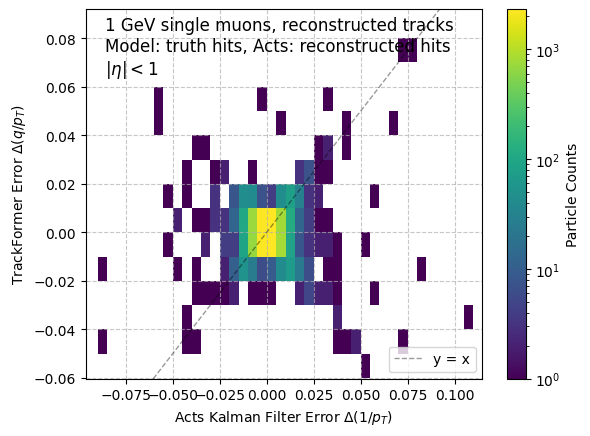

In [27]:
# Scatter plot of q/pT model vs q/pT algorithm
# Select only the tracks with |eta| < max_abs_eta
max_abs_eta = 1
eta_selection = np.abs(all_events_tracks["eta_truth"]) <= max_abs_eta
all_events_tracks_eta = all_events_tracks[eta_selection]
print(f"Number of tracks with |eta| < {max_abs_eta}: {len(all_events_tracks_eta)}")

plt.figure()
q_pT_truth = all_events_tracks_eta["q_truth"] / all_events_tracks_eta["pT_truth"]
# Acts Kalman Filter error
# tracks_error = all_events_tracks_eta["q_truth"] / all_events_tracks_eta["pT"] - q_pT_truth
tracks_error = 1 / all_events_tracks_eta["pT"] - np.abs(q_pT_truth)
# Model error
tracks_error_model = all_events_tracks_eta["q/p_T_pred"] - q_pT_truth

from matplotlib import colors
bins = [np.arange(-1, 1, 0.005), np.arange(-1, 1, 0.01)]
bins = [np.arange(min(tracks_error.min(), -1), max(tracks_error.max(), 1), 0.005),
        np.arange(min(tracks_error_model.min(), -1), max(tracks_error_model.max(), 1), 0.01)]
plt.hist2d(
    tracks_error,
    tracks_error_model,
    # bins=100,
    bins=bins,
    # range=[[-0.1, 0.1], [-0.1, 0.1]],
    # cmap="Blues",
    norm=colors.LogNorm()
)
plt.colorbar(label='Particle Counts')
plt.xlabel(r"Acts Kalman Filter Error $\Delta (1/p_T)$")
plt.ylabel(r"TrackFormer Error $\Delta (q/p_T)$")
# plt.title("Acts Kalman Filter vs TrackFormer Error (q/pT)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
# Add 5% to the limits
tracks_error_range = tracks_error.max() - tracks_error.min()
tracks_error_model_range = tracks_error_model.max() - tracks_error_model.min()
x_increment = 0.05 * tracks_error_range
y_top = 0.15 * tracks_error_model_range
y_bottom = 0.05 * tracks_error_model_range
plt.xlim(tracks_error.min() - x_increment, tracks_error.max() + x_increment)
plt.ylim(tracks_error_model.min() - y_bottom, tracks_error_model.max() + y_top)
# Add a text indicating that the model uses truth hits, acts uses reconstructed hits and both use the same reconstructed tracks
plt.text(0.05, 0.98, f"1 GeV single muons, reconstructed tracks\nModel: truth hits, Acts: reconstructed hits\n$|\eta| < {max_abs_eta}$",
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
        )

# # Make both axes with the same limits
min_x, max_x = plt.xlim()
min_y, max_y = plt.ylim()
print(f"Min x: {min_x}, Max x: {max_x}")
print(f"Min y: {min_y}, Max y: {max_y}")
# min_lim = min(min_x, min_y)
# max_lim = max(max_x, max_y)
# plt.xlim(min_lim, max_x)
# plt.ylim(min_lim, max_lim)
# Min x: -0.5426703107592218, Max x: 0.02584147205581523
# Min y: -0.606517136875149, Max y: 0.8121072088695933
# if max_abs_eta == 1:
#     assert min(tracks_error) > -0.5426703107592218, f"Min x is ouside the range: {min(tracks_error)} > -0.5426703107592218"
#     assert max(tracks_error) < 0.02584147205581523, f"Max x is ouside the range: {max(tracks_error)} < 0.02584147205581523"
#     assert min(tracks_error_model) > -0.606517136875149, f"Min y is ouside the range: {min(tracks_error_model)} < -0.606517136875149"
#     assert max(tracks_error_model) < 0.8121072088695933, f"Max y is ouside the range: {max(tracks_error_model)} < 0.8121072088695933"
#     plt.xlim(-0.5426703107592218, 0.02584147205581523)
#     plt.ylim(-0.606517136875149, 0.8121072088695933)
# plt.savefig(f"acts_vs_trackformer_error_eta_{max_abs_eta}.png")
# Add a diagonal line
plt.plot(
    [min_x, max_x],
    [min_x, max_x],
    color="black",
    linestyle="--",
    linewidth=1,
    label="y = x",
    alpha=0.4,
)
plt.legend()
plt.savefig(output_dir / f"acts_vs_trackformer_error_eta_{max_abs_eta}_pT.png")
plt.show()

Number of tracks with |eta| < 1: 13180
Min x: -0.11426488928507982, Max x: 0.08527271154849507
Min y: -0.060367816126149124, Max y: 0.09200434424649093


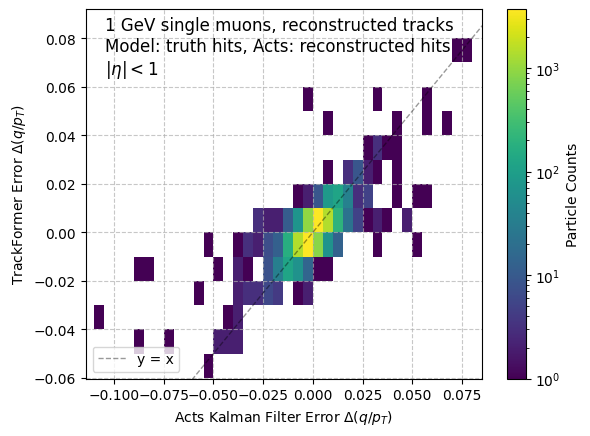

In [28]:
# Scatter plot of q/pT model vs q/pT algorithm
# Select only the tracks with |eta| < max_abs_eta
max_abs_eta = 1
eta_selection = np.abs(all_events_tracks["eta_truth"]) <= max_abs_eta
all_events_tracks_eta = all_events_tracks[eta_selection]
print(f"Number of tracks with |eta| < {max_abs_eta}: {len(all_events_tracks_eta)}")

plt.figure()
q_pT_truth = all_events_tracks_eta["q_truth"] / all_events_tracks_eta["pT_truth"]
# Acts Kalman Filter error
tracks_error = all_events_tracks_eta["q_truth"] / all_events_tracks_eta["pT"] - q_pT_truth
# Model error
tracks_error_model = all_events_tracks_eta["q/p_T_pred"] - q_pT_truth

from matplotlib import colors
bins = [np.arange(-1, 1, 0.005), np.arange(-1, 1, 0.01)]
bins = [np.arange(min(tracks_error.min(), -1), max(tracks_error.max(), 1), 0.005),
        np.arange(min(tracks_error_model.min(), -1), max(tracks_error_model.max(), 1), 0.01)]
plt.hist2d(
    tracks_error,
    tracks_error_model,
    # bins=100,
    bins=bins,
    # range=[[-0.1, 0.1], [-0.1, 0.1]],
    # cmap="Blues",
    norm=colors.LogNorm()
)
plt.colorbar(label='Particle Counts')
plt.xlabel(r"Acts Kalman Filter Error $\Delta (q/p_T)$")
plt.ylabel(r"TrackFormer Error $\Delta (q/p_T)$")
# plt.title("Acts Kalman Filter vs TrackFormer Error (q/pT)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
# Add 5% to the limits
tracks_error_range = tracks_error.max() - tracks_error.min()
tracks_error_model_range = tracks_error_model.max() - tracks_error_model.min()
x_increment = 0.05 * tracks_error_range
y_top = 0.15 * tracks_error_model_range
y_bottom = 0.05 * tracks_error_model_range
plt.xlim(tracks_error.min() - x_increment, tracks_error.max() + x_increment)
plt.ylim(tracks_error_model.min() - y_bottom, tracks_error_model.max() + y_top)
# Add a text indicating that the model uses truth hits, acts uses reconstructed hits and both use the same reconstructed tracks
plt.text(0.05, 0.98, f"1 GeV single muons, reconstructed tracks\nModel: truth hits, Acts: reconstructed hits\n$|\eta| < {max_abs_eta}$",
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
        )

# # Make both axes with the same limits
min_x, max_x = plt.xlim()
min_y, max_y = plt.ylim()
print(f"Min x: {min_x}, Max x: {max_x}")
print(f"Min y: {min_y}, Max y: {max_y}")
# min_lim = min(min_x, min_y)
# max_lim = max(max_x, max_y)
# plt.xlim(min_lim, max_x)
# plt.ylim(min_lim, max_lim)
# Min x: -0.5426703107592218, Max x: 0.02584147205581523
# Min y: -0.606517136875149, Max y: 0.8121072088695933
# if max_abs_eta == 1:
#     assert min(tracks_error) > -0.5426703107592218, f"Min x is ouside the range: {min(tracks_error)} > -0.5426703107592218"
#     assert max(tracks_error) < 0.02584147205581523, f"Max x is ouside the range: {max(tracks_error)} < 0.02584147205581523"
#     assert min(tracks_error_model) > -0.606517136875149, f"Min y is ouside the range: {min(tracks_error_model)} < -0.606517136875149"
#     assert max(tracks_error_model) < 0.8121072088695933, f"Max y is ouside the range: {max(tracks_error_model)} < 0.8121072088695933"
#     plt.xlim(-0.5426703107592218, 0.02584147205581523)
#     plt.ylim(-0.606517136875149, 0.8121072088695933)
# plt.savefig(f"acts_vs_trackformer_error_eta_{max_abs_eta}.png")
# Add a diagonal line
plt.plot(
    [min_x, max_x],
    [min_x, max_x],
    color="black",
    linestyle="--",
    linewidth=1,
    label="y = x",
    alpha=0.4,
)
plt.legend()
plt.savefig(output_dir / f"acts_vs_trackformer_error_eta_{max_abs_eta}_q_pT.png")
plt.show()

In [29]:
# Print the fraction sign(p_pred_model[:, 0]) == sign(tracks["q_truth"])
signs_match = np.sign(all_events_tracks["q/p_T_pred"]) == np.sign(all_events_tracks["q_truth"])
print(f"Fraction of tracks with matching signs: {np.sum(signs_match) / len(signs_match):.2%}")
print(f"Fraction of tracks with mismatching signs: {np.sum(~signs_match) / len(signs_match):.2%}")
print(f"Number of tracks with matching signs: {np.sum(signs_match)}")
print(f"Number of tracks with mismatching signs: {np.sum(~signs_match)}")
print(f"Total number of tracks: {len(signs_match)}")
# Count the number of each unique value in model_data["MSE"]
unique_values, counts = np.unique(np.sign(all_events_tracks["q/p_T_pred"]), return_counts=True)
print(f"Unique values in model_data['MSE']: {len(unique_values)}")
print(f"Counts of unique values in model_data['MSE']: {counts}")

Fraction of tracks with matching signs: 100.00%
Fraction of tracks with mismatching signs: 0.00%
Number of tracks with matching signs: 13180
Number of tracks with mismatching signs: 0
Total number of tracks: 13180
Unique values in model_data['MSE']: 2
Counts of unique values in model_data['MSE']: [6560 6620]


In [30]:
# No particle_type selection:

# Fraction of tracks with matching signs: 100.00%
# Fraction of tracks with mismatching signs: 0.00%
# Number of tracks with matching signs: 151404
# Number of tracks with mismatching signs: 0
# Total number of tracks: 151404
# Unique values in model_data['MSE']: 2
# Counts of unique values in model_data['MSE']: [75816 75588]
# Print the fraction sign(p_pred_model[:, 0]) == sign(tracks["q_truth"])

bin_edges = bin_edges = array([['-1.05', '-0.9500000000000001'],
       ['-0.9500000000000001', '-0.8500000000000001'],
       ['-0.8500000000000001', '-0.7500000000000001'],
       ['-0.7500000000000001', '-0.6500000000000001'],
       ['-0.6500000000000001', '-0.5500000000000002'],
       ['-0.5500000000000002', '-0.4500000000000002'],
       ['-0.4500000000000002', '-0.3500000000000002'],
       ['-0.3500000000000002', '-0.2500000000000002'],
       ['-0.2500000000000002', '-0.15000000000000024'],
       ['-0.15000000000000024', '-0.050000000000000266'],
       ['-0.050000000000000266', '0.0499999999999996'],
       ['0.0499999999999996', '0.1499999999999997'],
       ['0.1499999999999997', '0.24999999999999978'],
       ['0.24999999999999978', '0.34999999999999964'],
       ['0.34999999999999964', '0.4499999999999995'],
       ['0.4499999999999995', '0.5499999999999996'],
       ['0.5499999999999996', '0.6499999999999997'],
       ['0.6499999999999997', '0.7499999999999996'],
     

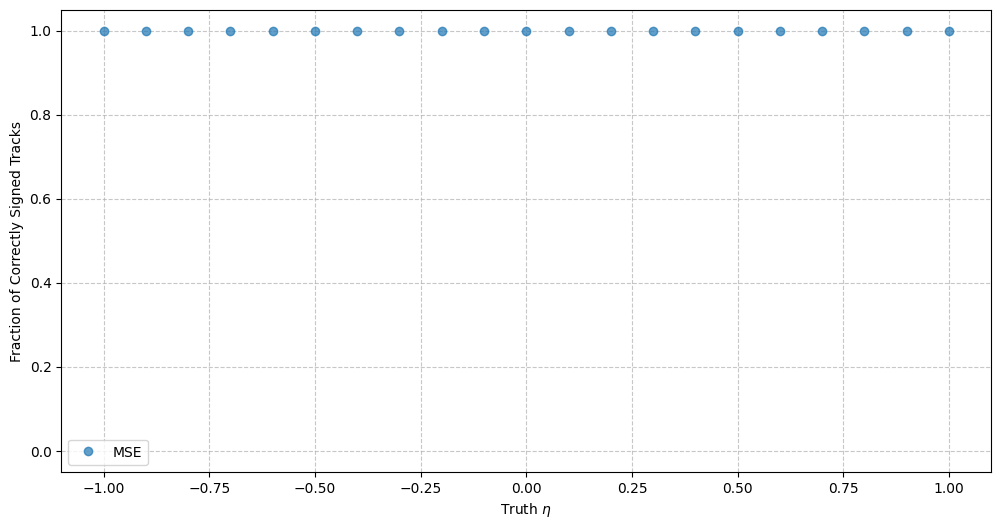

In [31]:
# Plot fraction of correctly signed tracks as a function of eta


# Compute the fraction of correctly signed tracks
def compute_fraction_correctly_signed_tracks(tracks, model_data):
    # Compute the fraction of correctly signed tracks
    p_pred_values = tracks["q/p_T_pred"].values
    # Compute the sign of the true and predicted values
    sign_true = np.sign(tracks["q_truth"])
    sign_pred = np.sign(p_pred_values)
    # Compute the fraction of correctly signed tracks
    fraction_correctly_signed_tracks = np.mean(sign_true == sign_pred)
    return fraction_correctly_signed_tracks


# Make bins in eta
bin_size = 0.1
bins = np.arange(
    -(config["max_abs_eta"] + bin_size / 2),
    config["max_abs_eta"] + bin_size / 2 + bin_size,
    bin_size,
)
# print(f"bins = {bins = }")
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_fractions = []
# Loop over each bin
for i in range(len(bins) - 1):
    # Get the indices of the points in this bin
    bin_indices = np.where(
        (all_events_tracks["eta_truth"] >= bins[i])
        & (all_events_tracks["eta_truth"] < bins[i + 1])
    )[0]
    # print(bin_indices)
    # Get the tracks in this bin
    tracks_bin = all_events_tracks.iloc[bin_indices]
    # Compute the fraction of correctly signed tracks for each model
    for model_name, model_info in models.items():
        # print(model_info["data_list"])
        # model_data = model_info["data_list"].copy()
        # # Select only the tracks in this bin
        # model_data = np.array(model_data)[bin_indices]
        fraction_correctly_signed_tracks = compute_fraction_correctly_signed_tracks(
            tracks_bin, {"MSE": []}
        )
        bin_fractions.append(
            (bins[i], bins[i + 1], fraction_correctly_signed_tracks, model_name)
        )

# Convert to numpy array
bin_fractions = np.array(bin_fractions)
# Make the plot
plt.figure(figsize=(12, 6))
# Plot the data
for model_name in models.keys():
    # Get the data for this model
    model_data = bin_fractions[bin_fractions[:, 3] == model_name]
    # Get the means and stds
    bin_means = model_data[:, 2].astype(float)
    bin_edges = model_data[:, :2]
    print(f"bin_edges = {bin_edges = }")
    print(f"bin_means = {bin_means = }")

    plt.errorbar(
        # (bin_edges[:, 0] + bin_edges[:, 1]) / 2,
        bin_centers,
        bin_means,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )
plt.legend()
# plt.title("Fraction of Correctly Signed Tracks vs peta")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"Fraction of Correctly Signed Tracks")
plt.grid(True, linestyle="--", alpha=0.7)
plt.ylim(-0.05, 1.05)
plt.savefig(
    output_dir / "fraction_correctly_signed_tracks_vs_peta.png",
    format="png",
    bbox_inches="tight",
)
plt.show()

x_bins = x_bins = array([-1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -2.22044605e-16,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01,
        1.00000000e+00])


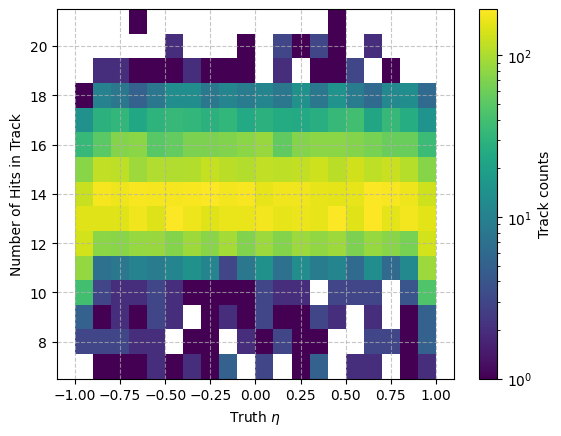

In [32]:
# Plot n_hits_track vs eta_truth
plt.figure()
x_bins = np.arange(-config["max_abs_eta"], config["max_abs_eta"] + 0.1, 0.1)
print(f"x_bins = {x_bins = }")

# Create bin edges centered on integers
n_min = int(all_events_tracks["n_hits_track"].min())
n_max = int(all_events_tracks["n_hits_track"].max())
y_bins = np.arange(n_min - 0.5, n_max + 1.5, 1)

plt.hist2d(
    all_events_tracks["eta_truth"],
    all_events_tracks["n_hits_track"],
    bins=[x_bins, y_bins],
    norm=colors.LogNorm(),
)
plt.colorbar(label='Track counts')
plt.xlim(-config["max_abs_eta"] - 0.1, config["max_abs_eta"] + 0.1)

plt.xlabel(r"Truth $\eta$")
plt.ylabel("Number of Hits in Track")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
plt.savefig(output_dir / "n_hits_track_vs_eta.png")
plt.show()

Number of tracks with |eta| < 1: 13180


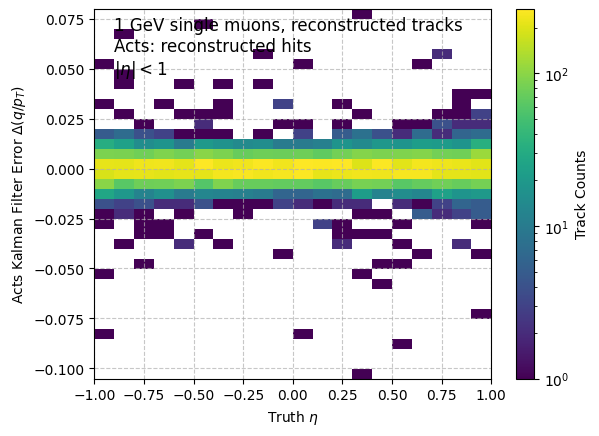

In [33]:
# Scatter plot of q/pT model vs q/pT algorithm
# Select only the tracks with |eta| < max_abs_eta
max_abs_eta = min(config["max_abs_eta"], 3)
eta_selection = np.abs(all_events_tracks["eta_truth"]) <= max_abs_eta
all_events_tracks_eta = all_events_tracks[eta_selection]
print(f"Number of tracks with |eta| < {max_abs_eta}: {len(all_events_tracks_eta)}")

plt.figure()
# Acts Kalman Filter error
# tracks_error = all_events_tracks_eta["pT"] - all_events_tracks_eta["pT_truth"]
tracks_error = all_events_tracks_eta["q_truth"] / all_events_tracks_eta["pT"] - all_events_tracks_eta["q_truth"] / all_events_tracks_eta["pT_truth"]

from matplotlib import colors
bins = [np.arange(-config["max_abs_eta"], config["max_abs_eta"] + 0.1, 0.1),
    # np.arange(min(tracks_error.min(), -1), max(tracks_error.max(), 1), 0.005),
    np.arange(tracks_error.min(), tracks_error.max() + 0.005, 0.005),
        ]
# print(f"{tracks_error.min() = }, {tracks_error.max() = }")
# print(f"{all_events_tracks_eta['pT_truth'].min() = }, {all_events_tracks_eta['pT_truth'].max() = }")
# print(f"{all_events_tracks_eta['pT'].min() = }, {all_events_tracks_eta['pT'].max() = }")
plt.hist2d(
    all_events_tracks_eta["eta_truth"],
    tracks_error,
    # bins=100,
    bins=bins,
    # range=[[-0.1, 0.1], [-0.1, 0.1]],
    # cmap="Blues",
    norm=colors.LogNorm()
)
plt.colorbar(label='Track Counts')
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"Acts Kalman Filter Error $\Delta (q / p_T)$")
# plt.title("Acts Kalman Filter vs TrackFormer Error (q/pT)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
# Add 5% to the limits
tracks_error_range = tracks_error.max() - tracks_error.min()
x_increment = 0.05 * tracks_error_range
y_top = 0.15 * tracks_error_range
y_bottom = 0.05 * tracks_error_range
# plt.xlim(tracks_error.min() - x_increment, tracks_error.max() + x_increment)
# plt.ylim(tracks_error.min() - y_bottom, tracks_error.max() + y_top)
# Add a text indicating that the model uses truth hits, acts uses reconstructed hits and both use the same reconstructed tracks
plt.text(0.05, 0.98, f"1 GeV single muons, reconstructed tracks\nActs: reconstructed hits\n$|\eta| < {max_abs_eta}$",
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
        )

# # # Make both axes with the same limits
# min_x, max_x = plt.xlim()
# min_y, max_y = plt.ylim()
# print(f"Min x: {min_x}, Max x: {max_x}")
# print(f"Min y: {min_y}, Max y: {max_y}")
# # min_lim = min(min_x, min_y)
# # max_lim = max(max_x, max_y)
# # plt.xlim(min_lim, max_x)
# # plt.ylim(min_lim, max_lim)
# # Min x: -0.5426703107592218, Max x: 0.02584147205581523
# # Min y: -0.606517136875149, Max y: 0.8121072088695933
# if max_abs_eta == 1:
#     assert min(tracks_error) > -0.5426703107592218, f"Min x is ouside the range: {min(tracks_error)} > -0.5426703107592218"
#     assert max(tracks_error) < 0.02584147205581523, f"Max x is ouside the range: {max(tracks_error)} < 0.02584147205581523"
#     assert min(tracks_error_model) > -0.606517136875149, f"Min y is ouside the range: {min(tracks_error_model)} < -0.606517136875149"
#     assert max(tracks_error_model) < 0.8121072088695933, f"Max y is ouside the range: {max(tracks_error_model)} < 0.8121072088695933"
#     plt.xlim(-0.5426703107592218, 0.02584147205581523)
#     plt.ylim(-0.606517136875149, 0.8121072088695933)
# # plt.savefig(f"acts_vs_trackformer_error_eta_{max_abs_eta}.png")
plt.savefig(output_dir / f"acts_error_vs_eta_{max_abs_eta}_q_pt.png")
plt.show()

Number of tracks with |eta| < 1: 13180
tracks_error_model.min() = -0.05401897611062245, tracks_error_model.max() = 0.07295782419991093
all_events_tracks_eta['pT_truth'].min() = 1.99999991542492, all_events_tracks_eta['pT_truth'].max() = 2.000000088699981
np.abs(1/all_events_tracks_eta['q/p_T_pred']).min() = 1.7453291953082177, np.abs(1/all_events_tracks_eta['q/p_T_pred']).max() = 2.2546353177349308


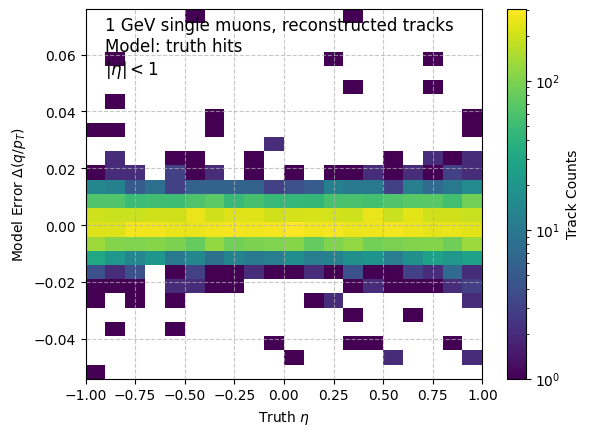

In [34]:
# Scatter plot of q/pT model vs q/pT algorithm
# Select only the tracks with |eta| < max_abs_eta
max_abs_eta = min(config["max_abs_eta"], 3)
eta_selection = np.abs(all_events_tracks["eta_truth"]) <= max_abs_eta
all_events_tracks_eta = all_events_tracks[eta_selection]
print(f"Number of tracks with |eta| < {max_abs_eta}: {len(all_events_tracks_eta)}")

plt.figure()
q_pT_truth = all_events_tracks_eta["q_truth"] / all_events_tracks_eta["pT_truth"]
# Model error
tracks_error_model = all_events_tracks_eta["q/p_T_pred"] - q_pT_truth

from matplotlib import colors
bins = [np.arange(-config["max_abs_eta"], config["max_abs_eta"] + 0.1, 0.1),
    np.arange(tracks_error_model.min(), tracks_error_model.max() + 0.005, 0.005),
        ]
print(f"{tracks_error_model.min() = }, {tracks_error_model.max() = }")
print(f"{all_events_tracks_eta['pT_truth'].min() = }, {all_events_tracks_eta['pT_truth'].max() = }")
print(f"{np.abs(1/all_events_tracks_eta['q/p_T_pred']).min() = }, {np.abs(1/all_events_tracks_eta['q/p_T_pred']).max() = }")
plt.hist2d(
    all_events_tracks_eta["eta_truth"],
    tracks_error_model,
    # bins=100,
    bins=bins,
    # range=[[-0.1, 0.1], [-0.1, 0.1]],
    # cmap="Blues",
    norm=colors.LogNorm()
)
plt.colorbar(label='Track Counts')
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"Model Error $\Delta (q/p_T)$")
# plt.title("Acts Kalman Filter vs TrackFormer Error (q/pT)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
# Add 5% to the limits
tracks_error_range = tracks_error_model.max() - tracks_error_model.min()
x_increment = 0.05 * tracks_error_range
y_top = 0.15 * tracks_error_range
y_bottom = 0.05 * tracks_error_range
# plt.xlim(tracks_error.min() - x_increment, tracks_error.max() + x_increment)
# plt.ylim(tracks_error.min() - y_bottom, tracks_error.max() + y_top)
# Add a text indicating that the model uses truth hits, acts uses reconstructed hits and both use the same reconstructed tracks
plt.text(0.05, 0.98, f"1 GeV single muons, reconstructed tracks\nModel: truth hits\n$|\eta| < {max_abs_eta}$",
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
        )

# # # Make both axes with the same limits
# min_x, max_x = plt.xlim()
# min_y, max_y = plt.ylim()
# print(f"Min x: {min_x}, Max x: {max_x}")
# print(f"Min y: {min_y}, Max y: {max_y}")
# # min_lim = min(min_x, min_y)
# # max_lim = max(max_x, max_y)
# # plt.xlim(min_lim, max_x)
# # plt.ylim(min_lim, max_lim)
# # Min x: -0.5426703107592218, Max x: 0.02584147205581523
# # Min y: -0.606517136875149, Max y: 0.8121072088695933
# if max_abs_eta == 1:
#     assert min(tracks_error) > -0.5426703107592218, f"Min x is ouside the range: {min(tracks_error)} > -0.5426703107592218"
#     assert max(tracks_error) < 0.02584147205581523, f"Max x is ouside the range: {max(tracks_error)} < 0.02584147205581523"
#     assert min(tracks_error_model) > -0.606517136875149, f"Min y is ouside the range: {min(tracks_error_model)} < -0.606517136875149"
#     assert max(tracks_error_model) < 0.8121072088695933, f"Max y is ouside the range: {max(tracks_error_model)} < 0.8121072088695933"
#     plt.xlim(-0.5426703107592218, 0.02584147205581523)
#     plt.ylim(-0.606517136875149, 0.8121072088695933)
# # plt.savefig(f"acts_vs_trackformer_error_eta_{max_abs_eta}.png")
plt.savefig(output_dir / f"trackformer_error_vs_eta_{max_abs_eta}.png")
plt.show()

(13180,)


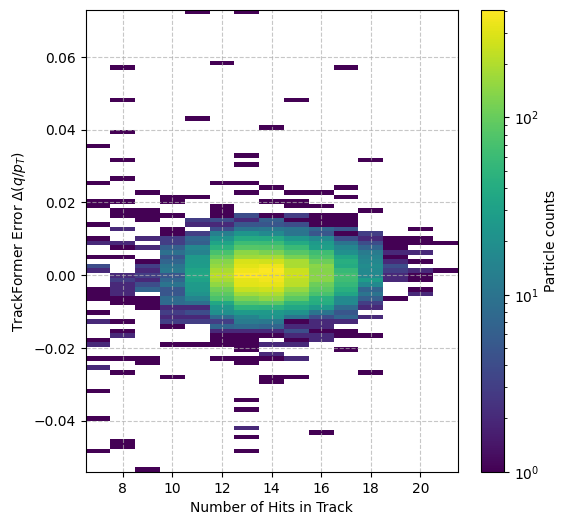

In [35]:
# Plot track error model vs n_hits_track
plt.figure(figsize=(6, 6))
q_pT_truth = all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
# Model error
tracks_error_model = all_events_tracks["q/p_T_pred"] - q_pT_truth
print(tracks_error_model.shape)

# Create bin edges centered on integers
n_min = int(all_events_tracks["n_hits_track"].min())
n_max = int(all_events_tracks["n_hits_track"].max())
x_bins = np.arange(n_min - 0.5, n_max + 1.5, 1)

plt.hist2d(
    all_events_tracks["n_hits_track"],
    tracks_error_model,
    bins=[x_bins, 100],
    norm=colors.LogNorm(),
)
plt.colorbar(label='Particle counts')

plt.xlabel("Number of Hits in Track")
plt.ylabel("TrackFormer Error $\Delta (q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
plt.savefig(output_dir / "trackformer_error_vs_n_hits_track.png")
plt.show()

(13180,)


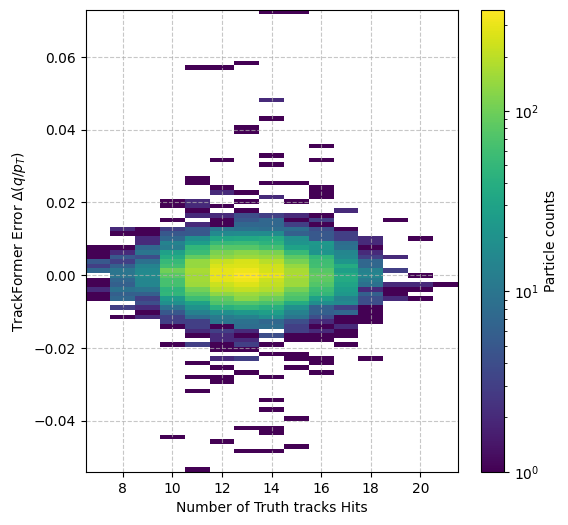

In [36]:
# Plot track error model vs n_hits_truth
plt.figure(figsize=(6, 6))
q_pT_truth = all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
# Model error
tracks_error_model = all_events_tracks["q/p_T_pred"] - q_pT_truth
print(tracks_error_model.shape)

# Create bin edges centered on integers
n_min = int(all_events_tracks["n_hits_truth"].min())
n_max = int(all_events_tracks["n_hits_truth"].max())
x_bins = np.arange(n_min - 0.5, n_max + 1.5, 1)

plt.hist2d(
    all_events_tracks["n_hits_truth"],
    tracks_error_model,
    bins=[x_bins, 100],
    norm=colors.LogNorm(),
)
plt.colorbar(label='Particle counts')

plt.xlabel("Number of Truth tracks Hits")
plt.ylabel("TrackFormer Error $\Delta (q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
plt.savefig(output_dir / "trackformer_error_vs_n_hits_truth.png")
plt.show()

(13180,)


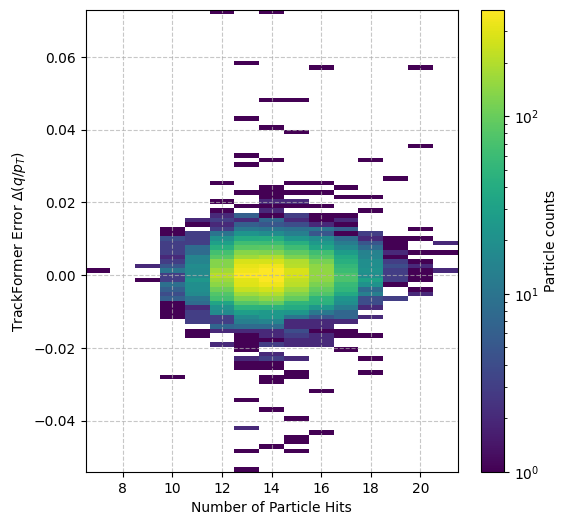

In [37]:
# Plot track error model vs n_particle_hits
plt.figure(figsize=(6, 6))
q_pT_truth = all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
# Model error
tracks_error_model = all_events_tracks["q/p_T_pred"] - q_pT_truth
print(tracks_error_model.shape)

# Create bin edges centered on integers
n_min = int(all_events_tracks["n_particle_hits"].min())
n_max = int(all_events_tracks["n_particle_hits"].max())
x_bins = np.arange(n_min - 0.5, n_max + 1.5, 1)

plt.hist2d(
    all_events_tracks["n_particle_hits"],
    tracks_error_model,
    bins=[x_bins, 100],
    norm=colors.LogNorm(),
)
plt.colorbar(label='Particle counts')

plt.xlabel("Number of Particle Hits")
plt.ylabel("TrackFormer Error $\Delta (q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
plt.savefig(output_dir / "trackformer_error_vs_n_hits_particle.png")
plt.show()

In [38]:
# def polar_hit_plot(particle_id, event_id, radius_sort=True):
def polar_hit_plot(hits, radius_sort=True):
    if hits.empty:
        print("No hits found for the specified particle_id and event.")
        return

    plt.figure(figsize=(10, 10))
    if not "tphi" in hits.columns:
        # Convert to polar coordinates
        hits["tphi"] = np.arctan2(hits["ty"], hits["tx"])
        hits["tr"] = np.sqrt(hits["tx"]**2 + hits["ty"]**2)
    theta = hits["tphi"]
    r = hits["tr"]
    plt.polar(theta, r, alpha=0.5, marker="o", linestyle="None")
    # Get the smallest hit radius
    # plt.polar(theta.iloc[0], r.iloc[0], marker="o", color="red", label="Smallest hit radius")

    angles = np.arange(0, 2 * np.pi - 1e-6, np.pi / 4)
    labels = [
        "$0$",
        "$\\frac{\pi}{4}$",
        "$\\frac{\pi}{2}$",
        "$\\frac{3\pi}{4}$",
        "$\\pm\\pi$",
        "$-\\frac{3\pi}{4}$",
        "$-\\frac{\pi}{2}$",
        "$-\\frac{\pi}{4}$",
    ]
    plt.thetagrids(np.degrees(angles), labels=labels)
    plt.xlabel("$\\varphi$ [rad]")


    # Remove the radial ticks
    # plt.yticks([1], [""])
    # plt.ylim(0, 1)

    # title = f"Particle ID: {particle_id}, Event ID: {event_id}"
    # plt.title(title)
    
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [39]:
# def plot_particle_hits(particle_id, event_id, radius_sort=True):
def plot_particle_hits(hits, title=None, filename=None):
    """ Plot the hits of a particle in polar coordinates and in r-z coordinates."""
    is_track_hits = "particle_id_track" in hits.columns
    fig, axs = plt.subplots(1, 2, figsize=(20, 10))
    
    if title is not None:
        fig.suptitle(title, fontsize=16, y=1.02)
    else:
        # Add number of hits to the title
        fig.suptitle(f"Hits: {len(hits)}", fontsize=16)
    
    if not "tphi" in hits.columns:
        # Convert to polar coordinates
        hits["tphi"] = np.arctan2(hits["ty"], hits["tx"])
        hits["tr"] = np.sqrt(hits["tx"]**2 + hits["ty"]**2)
    
    theta = hits["tphi"]
    r = hits["tr"]
    # Make sure the first axes is a polar plot
    # Delete the first axes if it exists
    if axs[0] is not None:
        axs[0].remove()
    axs[0] = plt.subplot(121, polar=True)

    if is_track_hits:
        track_particle_selection = hits["particle_id"] == hits["particle_id_track"].iloc[0]
        selection_label = "Majority particle"
        unselected_label = "Other particles"
        plt.polar(theta[track_particle_selection], r[track_particle_selection], alpha=0.5, marker="o", linestyle="None", label=selection_label)
        if not track_particle_selection.all():
            plt.polar(theta[~track_particle_selection], r[~track_particle_selection], alpha=0.5, marker="o", linestyle="None", label=unselected_label, color="r")
    else:
        plt.polar(theta, r, alpha=0.5, marker="o", linestyle="None")

    angles = np.arange(0, 2 * np.pi - 1e-6, np.pi / 4)
    labels = [
        "$0$",
        "$\\frac{\pi}{4}$",
        "$\\frac{\pi}{2}$",
        "$\\frac{3\pi}{4}$",
        "$\\pm\\pi$",
        "$-\\frac{3\pi}{4}$",
        "$-\\frac{\pi}{2}$",
        "$-\\frac{\pi}{4}$",
    ]
    plt.thetagrids(np.degrees(angles), labels=labels)
    axs[0].set_xlabel("$\\varphi$ [rad]")
    # Remove the radial ticks
    # axs[0].set_yticks([1], [""])
    # axs[0].set_ylim(0, 1)

    # Set the radius limits
    plt.ylim(0, 1200)
    # title = f"Particle ID: {particle_id}, Event ID: {event_id}"
    # axs[0].set_title(title)
    if is_track_hits:
        axs[0].legend()
    axs[0].grid(True)

    # Scatter plot in r-z
    if is_track_hits:
        axs[1].scatter(hits["tz"][track_particle_selection], hits["tr"][track_particle_selection], alpha=0.5, marker="o", label=selection_label)
        if not track_particle_selection.all():
            axs[1].scatter(hits["tz"][~track_particle_selection], hits["tr"][~track_particle_selection], alpha=0.5, marker="o", label=unselected_label, color="r")
    else:
        axs[1].scatter(hits["tz"], hits["tr"], alpha=0.5, marker="o")
    axs[1].set_xlabel("z [mm]")
    axs[1].set_ylabel("r [mm]")
    # axs[1].set_title("Scatter plot in r-z")
    if is_track_hits:
        axs[1].legend()
    axs[1].set_xlim(-3100, 3100)
    axs[1].set_ylim(-50, 1200)
    axs[1].grid(True)
    
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, format="png", bbox_inches="tight")
        plt.savefig(filename.replace(".png", ".pdf"), format="pdf", bbox_inches="tight")
        plt.savefig(filename.replace(".png", ".svg"), format="svg", bbox_inches="tight")
    plt.show()

In [40]:
print(all_events_hits.columns)
print(all_events_tracks.columns)

Index(['particle_id', 'geometry_id', 'tx', 'ty', 'tz', 'tt', 'tpx', 'tpy',
       'tpz', 'te', 'deltapx', 'deltapy', 'deltapz', 'deltae', 'index',
       'event_id', 'hit_id', 'event', 'particle_id_track', 'track_id'],
      dtype='object')
Index(['track_id', 'seed_id', 'nStates', 'nMajorityHits', 'nMeasurements',
       'nOutliers', 'nHoles', 'nSharedHits', 'chi2', 'ndf', 'chi2/ndf', 'pT',
       'eta', 'phi', 'truthMatchProbability', 'good/duplicate/fake', 'Hits_ID',
       'event_id', 'particle_id', 'particle_type', 'process', 'vx_truth',
       'vy_truth', 'vz_truth', 'vt_truth', 'px_truth', 'py_truth', 'pz_truth',
       'm_truth', 'q_truth', 'event_id_truth', 'pT_truth', 'p_truth',
       'eta_truth', 'n_particle_hits', 'event', 'n_hits_track', 'n_hits_truth',
       'q/p_T_pred', 'pz_pred'],
      dtype='object')


In [41]:
# # Find tracks that are outside [-0.3, 0] for Acts and [-0.4, 0.2] for TrackFormer
# tracks_error = all_events_tracks["q_truth"]/all_events_tracks["pT"] - all_events_tracks["q_truth"]/all_events_tracks["pT_truth"]
# acts_mask = (tracks_error < -0.3) | (tracks_error > 1e-5)
# trackformer_mask = (tracks_error_model < -0.4) | (tracks_error_model > 0.4)
# if config["max_abs_eta"] == 1:
#     acts_mask = (tracks_error < -0.2) | (tracks_error > 1e-5)
#     trackformer_mask = (tracks_error_model < -0.2) | (tracks_error_model > 0.2)
# # Get the indices of the tracks that are outside the range
# acts_indices = np.where(acts_mask)[0]
# trackformer_indices = np.where(trackformer_mask)[0]
# print(f"{len(acts_indices) = }")
# print(f"{len(trackformer_indices) = }")
# # print(f"{acts_indices = }")
# # Get the tracks that are outside the range
# acts_tracks = all_events_tracks.iloc[acts_indices]
# # print(f"{acts_tracks.index = }")
# # print(f"{tracks_error[acts_indices] = }")
# trackformer_tracks = all_events_tracks.iloc[trackformer_indices]
# iteresting_mask = acts_mask | trackformer_mask
# # Get the indices of the tracks that are outside the range
# interesting_indices = np.where(iteresting_mask)[0]
# print(f"{len(interesting_indices) = }")
# # Get the tracks that are outside the range
# interesting_tracks = all_events_tracks.iloc[interesting_indices]

# # # Get corresponding (event, track_id) pairs
# # acts_tracks_pairs = acts_tracks[["event", "track_id"]].drop_duplicates()
# # trackformer_tracks_pairs = trackformer_tracks[["event", "track_id"]].drop_duplicates()
# # interesting_tracks_pairs = interesting_tracks[["event", "track_id"]].drop_duplicates()

# # # For each pair, get the corresponding hits 
# # acts_tracks_hits = all_events_hits[
# #     all_events_hits.set_index(["event", "track_id"]).index.isin(acts_tracks_pairs.set_index(["event", "track_id"]).index)
# # ]
# # trackformer_tracks_hits = all_events_hits[
# #     all_events_hits.set_index(["event", "track_id"]).index.isin(trackformer_tracks_pairs.set_index(["event", "track_id"]).index)
# # ]
# # interesting_tracks_hits = all_events_hits[
# #     all_events_hits.set_index(["event", "track_id"]).index.isin(interesting_tracks_pairs.set_index(["event", "track_id"]).index)
# # ]

# # For each track, plot the corresponding hits in x, y and r, z
# import matplotlib.pyplot as plt
# import numpy as np
# # print(f"{interesting_tracks = }")
# # # print(f"{interesting_tracks['Hits_ID'] = }")
# # for hits_id in interesting_tracks["Hits_ID"]:
# #     print(f"Processing hits with ID {hits_id}")

# for track_id in interesting_tracks["track_id"].unique():
#     track = interesting_tracks[interesting_tracks["track_id"] == track_id]
#     assert len(track) == 1, f"Track {track_id} not found in interesting tracks."
#     track = track.iloc[0]
#     print(f"Processing track {track_id} in event {track['event']}")

#     hits = all_events_hits[(all_events_hits["track_id"] == track_id) & (all_events_hits["event"] == track["event"])]
#     assert len(hits) == track["n_hits_track"], f"Number of hits for track {track_id} in event {track['event']} does not match n_hits_track: {len(hits)} != {track['n_hits_track']}"
    
#     if hits.empty:
#         print(f"No hits found for Acts track {track_id} in event {track['event']}.")
#         continue

#     title = f"Acts Track {track_id} in Event {track['event']}, Hits: {len(hits)}, $\eta_{{truth}}$={track['eta_truth']:.4f}, Acts |q/pT|: {1/track['pT']:.4f}, Truth q/pT: {track['q_truth']/track['pT_truth']:.4f}, Model q/pT: {track['q/p_T_pred']:.4f}"
#     # Plot the hits in polar coordinates
#     plot_particle_hits(hits, title=title, filename=str(output_dir / f"acts_track_{track_id}_event_{track['event']}.png"))

In [42]:
# Find tracks that are outside [-0.3, 0] for Acts and [-0.4, 0.2] for TrackFormer
tracks_error = all_events_tracks["q_truth"]/all_events_tracks["pT"] - all_events_tracks["q_truth"]/all_events_tracks["pT_truth"]
acts_mask = (tracks_error < -0.3) | (tracks_error > 0.3)
trackformer_mask = (tracks_error_model < -0.4) | (tracks_error_model > 0.4)
if config["max_abs_eta"] == 1:
    acts_mask = (tracks_error < -0.2) | (tracks_error > 0.2)
    trackformer_mask = (tracks_error_model < -0.2) | (tracks_error_model > 0.2)
# Get the indices of the tracks that are outside the range
acts_indices = np.where(acts_mask)[0]
trackformer_indices = np.where(trackformer_mask)[0]
print(f"{len(acts_indices) = }")
print(f"{len(trackformer_indices) = }")
# print(f"{acts_indices = }")
# Get the tracks that are outside the range
acts_tracks = all_events_tracks.iloc[acts_indices]
# print(f"{acts_tracks.index = }")
# print(f"{tracks_error[acts_indices] = }")
trackformer_tracks = all_events_tracks.iloc[trackformer_indices]
iteresting_mask = acts_mask | trackformer_mask
# Get the indices of the tracks that are outside the range
interesting_indices = np.where(iteresting_mask)[0]
print(f"{len(interesting_indices) = }")
# Get the tracks that are outside the range
interesting_tracks = all_events_tracks.iloc[interesting_indices]

# # Get corresponding (event, track_id) pairs
# acts_tracks_pairs = acts_tracks[["event", "track_id"]].drop_duplicates()
# trackformer_tracks_pairs = trackformer_tracks[["event", "track_id"]].drop_duplicates()
# interesting_tracks_pairs = interesting_tracks[["event", "track_id"]].drop_duplicates()

# # For each pair, get the corresponding hits 
# acts_tracks_hits = all_events_hits[
#     all_events_hits.set_index(["event", "track_id"]).index.isin(acts_tracks_pairs.set_index(["event", "track_id"]).index)
# ]
# trackformer_tracks_hits = all_events_hits[
#     all_events_hits.set_index(["event", "track_id"]).index.isin(trackformer_tracks_pairs.set_index(["event", "track_id"]).index)
# ]
# interesting_tracks_hits = all_events_hits[
#     all_events_hits.set_index(["event", "track_id"]).index.isin(interesting_tracks_pairs.set_index(["event", "track_id"]).index)
# ]

# For each track, plot the corresponding hits in x, y and r, z
import matplotlib.pyplot as plt
import numpy as np
# print(f"{interesting_tracks = }")
# # print(f"{interesting_tracks['Hits_ID'] = }")
# for hits_id in interesting_tracks["Hits_ID"]:
#     print(f"Processing hits with ID {hits_id}")

for track_id in interesting_tracks["track_id"].unique():
    track = interesting_tracks[interesting_tracks["track_id"] == track_id]
    assert len(track) == 1, f"Track {track_id} not found in interesting tracks."
    track = track.iloc[0]
    print(f"Processing track {track_id} in event {track['event']}")

    hits = all_events_hits[(all_events_hits["track_id"] == track_id) & (all_events_hits["event"] == track["event"])]
    assert len(hits) == track["n_hits_track"], f"Number of hits for track {track_id} in event {track['event']} does not match n_hits_track: {len(hits)} != {track['n_hits_track']}"
    
    if hits.empty:
        print(f"No hits found for Acts track {track_id} in event {track['event']}.")
        continue

    title = f"Acts Track {track_id} in Event {track['event']}, Hits: {len(hits)}, $\eta_{{truth}}$={track['eta_truth']:.4f}, Acts |q/pT|: {1/track['pT']:.4f}, Truth q/pT: {track['q_truth']/track['pT_truth']:.4f}, Model q/pT: {track['q/p_T_pred']:.4f}"
    # Plot the hits in polar coordinates
    plot_particle_hits(hits, title=title, filename=str(output_dir / f"acts_track_{track_id}_event_{track['event']}.png"))

len(acts_indices) = 0
len(trackformer_indices) = 0
len(interesting_indices) = 0


In [43]:
# Precompute tr, tphi
all_events_hits["tr"] = np.sqrt(all_events_hits["tx"] ** 2 + all_events_hits["ty"] ** 2)
all_events_hits["tphi"] = np.arctan2(all_events_hits["ty"], all_events_hits["tx"])

# Sort for grouping
all_events_hits = all_events_hits.sort_values(["event", "track_id", "tr"])

import numpy as np
import torch


def evaluate_track(
    all_events_hits, target_event_id, target_track_id, particle_only=False, remove_duplicates=False
):
    ml_model = models["MSE"]["model"]
    ml_model.eval()

    hits_groups = all_events_hits.groupby(["event", "track_id"])

    with torch.no_grad():
        # Find rows with (event, track_id) pairs
        target_all_events_tracks = all_events_tracks[
            (all_events_tracks["event"] == target_event_id)
            & (all_events_tracks["track_id"] == target_track_id)
        ]
        if target_all_events_tracks.empty:
            raise ValueError(
                f"No tracks found for event {target_event_id} and track {target_track_id}."
            )
        
        # Make sure there is only one matching row
        assert (
            len(target_all_events_tracks) == 1
        ), f"Expected one track for event {target_event_id} and track {target_track_id}, found {len(target_all_events_tracks)}."

        for idx, row in target_all_events_tracks.iterrows():
            event = row["event"]
            track_id = row["track_id"]
            n_hits_track = int(row["n_hits_track"])

            # Fetch the hits group
            hits_sel = hits_groups.get_group((event, track_id))

            assert (
                len(hits_sel) == n_hits_track
            ), f"Track {track_id} in event {event} hit count mismatch ({len(hits_sel)} vs {n_hits_track})"

            if particle_only:
                # Keep only the hits that belong to the particle
                hits_sel = hits_sel[hits_sel["particle_id"] == row["particle_id"]]
                print(f"Selected {len(hits_sel)} hits among {n_hits_track}.")

            if remove_duplicates:
                current_n_hits = len(hits_sel)
                # Remove hits for which tx diff is less than 10
                hits_sel = hits_sel.sort_values("tx")
                hits_sel_diff = np.abs(hits_sel["tx"].shift(-1) - hits_sel["tx"]) 
                hits_sel_diff_mask = (hits_sel_diff > 10) | (hits_sel_diff.isna()) 
                # Same for ty
                # hits_sel = hits_sel.sort_values("ty")
                hits_sel_diff_ty = np.abs(hits_sel["ty"].shift(-1) - hits_sel["ty"])
                hits_sel_diff_mask = hits_sel_diff_mask | ((hits_sel_diff_ty > 10) | (hits_sel_diff_ty.isna()))
                
                # # Same for tr
                # hits_sel = hits_sel.sort_values("tr")
                # hits_sel_diff_tr = np.abs(hits_sel["tr"].shift(-1) - hits_sel["tr"])
                # hits_sel_diff_mask = hits_sel_diff_mask | ((hits_sel_diff_tr > 10) | (hits_sel_diff_tr.isna()))

                # print(hits_sel_diff)
                # print(np.abs(hits_sel["tx"].shift(-1) - hits_sel["tx"]))
                hits_sel = hits_sel[hits_sel_diff_mask]
                hits_sel = hits_sel.reset_index(drop=True)
                hits_sel = hits_sel.sort_values("tr")
                print(f"Selected {len(hits_sel)} hits among {current_n_hits} (after removing duplicates).")

            # print(hits_sel)
            
            # Compute dphi
            tphi = hits_sel["tphi"].values
            dphi = tphi - tphi[0]
            dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
            hits_sel = hits_sel.copy()
            hits_sel["dphi"] = dphi
            # print(f"{hits_sel}")

            # Prepare input for model
            input_array = hits_sel[
                dataset_wrapper.test_dataset.input_variables
            ].values
            hits_tensor = torch.tensor(input_array, dtype=torch.float32).unsqueeze(
                0
            )
            mask_tensor = torch.ones(1, hits_sel.shape[0], dtype=torch.bool)

            # Model prediction
            pred = ml_model(hits_tensor, mask=mask_tensor)

            # # Write predictions
            # all_events_tracks.at[idx, "q/p_T_pred"] = pred[0, 0].item()
            # all_events_tracks.at[idx, "pz_pred"] = pred[0, 1].item()
            # print(
            #     f"Processed track {track_id} in event {event}: q/p_T_pred = {pred[0, 0].item()}, pz_pred = {pred[0, 1].item()}"
            # )

            return pred[0, 0].item(), pred[0, 1].item()


# target_event_id = "event000000004"
# target_track_id = 187
# pred = evaluate_track(
#     all_events_hits,
#     target_event_id=target_event_id,
#     target_track_id=target_track_id,
#     particle_only=True,
# )
# print(f"Predicted q/p_T: {pred[0]}, pz: {pred[1]} for track {target_track_id} in event {target_event_id}")

In [44]:
for track_id in interesting_tracks["track_id"].unique():
    track = interesting_tracks[interesting_tracks["track_id"] == track_id]
    assert len(track) == 1, f"Track {track_id} not found in interesting tracks."
    track = track.iloc[0]
    print(f"Processing track {track_id} in event {track['event']}")
    print(f"q/p_T_truth: {track['q_truth']/track['pT_truth']}, pz_truth: {track['pz_truth']}")

    pred = evaluate_track(
        all_events_hits,
        target_event_id=track["event"],
        target_track_id=track_id,
        particle_only=True,
    )
    print(f"Predicted q/p_T: {pred[0]}, pz: {pred[1]} for track {track_id} in event {track['event']} (Particle only)")
    pred = evaluate_track(
        all_events_hits,
        target_event_id=track["event"],
        target_track_id=track_id,
        remove_duplicates=True,
    )
    print(f"Predicted q/p_T: {pred[0]}, pz: {pred[1]} for track {track_id} in event {track['event']} (Remove duplicates)")
    pred = evaluate_track(
        all_events_hits,
        target_event_id=track["event"],
        target_track_id=track_id,
        particle_only=True,
        remove_duplicates=True,
    )
    print(f"Predicted q/p_T: {pred[0]}, pz: {pred[1]} for track {track_id} in event {track['event']} (Remove duplicates, Particle only)")
    pred = evaluate_track(
        all_events_hits,
        target_event_id=track["event"],
        target_track_id=track_id,
        particle_only=False,
    )
    print(f"Predicted q/p_T: {pred[0]}, pz: {pred[1]} for track {track_id} in event {track['event']} (Track hits)")
    print()

In [45]:
print(all_events_hits.columns)

Index(['particle_id', 'geometry_id', 'tx', 'ty', 'tz', 'tt', 'tpx', 'tpy',
       'tpz', 'te', 'deltapx', 'deltapy', 'deltapz', 'deltae', 'index',
       'event_id', 'hit_id', 'event', 'particle_id_track', 'track_id', 'tr',
       'tphi'],
      dtype='object')


In [46]:
# # Precompute tr, tphi
# all_events_hits["tr"] = np.sqrt(all_events_hits["tx"] ** 2 + all_events_hits["ty"] ** 2)
# all_events_hits["tphi"] = np.arctan2(all_events_hits["ty"], all_events_hits["tx"])

# # Sort for grouping
# all_events_hits = all_events_hits.sort_values(["event", "particle_id", "tr"])

# import numpy as np
# import torch
# from time import time

# if not "q/p_T_pred" in all_events_tracks.columns or not "pz_pred" in all_events_tracks.columns:
#     print("No model predictions found, running the model on the test dataset.")
#     ml_model = models["MSE"]["model"]
#     ml_model.eval()
#     start_time = time()

#     # Add empty columns up front
#     all_events_tracks["q/p_T_pred"] = np.nan
#     all_events_tracks["pz_pred"] = np.nan

#     last_log = 0

#     # Precompute tr and tphi ONCE for all hits
#     for event_hits in all_hits_list:
#         event_hits["tr"] = np.sqrt(event_hits["tx"] ** 2 + event_hits["ty"] ** 2)
#         event_hits["tphi"] = np.arctan2(event_hits["ty"], event_hits["tx"])

#     print(f"Preprocessing time: {time() - start_time} seconds")

#     # # Precompute dphi for all hits (based on first hit of each particle)
#     # for event_hits in all_hits_list:
#     #     if "dphi" in event_hits.columns:
#     #         # If dphi already exists, skip this step
#     #         continue
#     #     loop_time = time()
#     #     hits_by_particle = event_hits.sort_values("tr").groupby("particle_id")
#     #     for particle_id, hits_sel in hits_by_particle:
#     #         tphi = hits_sel["tphi"].values
#     #         dphi = tphi - tphi[0]
#     #         dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
#     #         event_hits.loc[hits_sel.index, "dphi"] = dphi
#     #     print(f"Preprocessing time 2_1: {time() - loop_time} seconds")
#     # print(f"Preprocessing time 2: {time() - start_time} seconds")

#     hits_groups = all_events_hits.groupby(["event", "track_id"])

#     processed_particles = 0
#     progress_interval = 1000

#     with torch.no_grad():
#         for idx, row in all_events_tracks.iterrows():
#             # print(f"Processing row {row} at index {idx}")
#             event = row["event"]
#             track_id = row["track_id"]
#             n_hits_track = int(row["n_hits_track"])

#             # Fetch the hits group
#             hits_sel = hits_groups.get_group((event, track_id))

#             assert len(hits_sel) == n_hits_track, f"Track {track_id} in event {event} hit count mismatch ({len(hits_sel)} vs {n_hits_track})"

#             # Compute dphi
#             tphi = hits_sel["tphi"].values
#             dphi = tphi - tphi[0]
#             dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
#             hits_sel = hits_sel.copy()
#             hits_sel["dphi"] = dphi
#             # print(f"{hits_sel}")

#             # Prepare input for model
#             input_array = hits_sel[dataset_wrapper.test_dataset.input_variables].values
#             hits_tensor = torch.tensor(input_array, dtype=torch.float32).unsqueeze(0)
#             mask_tensor = torch.ones(1, n_hits_track, dtype=torch.bool)

#             # Model prediction
#             pred = ml_model(hits_tensor, mask=mask_tensor)

#             # # Consistency check (optional)
#             # if "q/p_T_pred" in all_events_particles.columns:
#             #     prev_pred = all_events_particles.at[idx, "q/p_T_pred"]
#             #     same = np.allclose(pred[0, 0].item(), prev_pred, equal_nan=True, rtol=1e-5)
#             #     if not same:
#             #         print(f"Prediction mismatch for event {event}, particle {particle_id}: {pred[0, 0].item()} vs {prev_pred}")
#             #     assert same, \
#             #         f"Prediction mismatch for particle {particle_id} at index {idx}: {pred[0, 0].item()} != {all_events_particles.at[idx, 'q/p_T_pred']}"
#             #     same = np.allclose(pred[0, 1].item(), all_events_particles.at[idx, "pz_pred"], equal_nan=True, rtol=1e-5)
#             #     if not same:
#             #         print(f"pz prediction mismatch for event {event}, particle {particle_id}: {pred[0, 1].item()} vs {all_events_particles.at[idx, 'pz_pred']}")
#             #     assert same, \
#             #         f"pz prediction mismatch for particle {particle_id} at index {idx}: {pred[0, 1].item()} != {all_events_particles.at[idx, 'pz_pred']}"

#             # Write predictions
#             all_events_tracks.at[idx, "q/p_T_pred"] = pred[0, 0].item()
#             all_events_tracks.at[idx, "pz_pred"] = pred[0, 1].item()

#             processed_particles += 1
#             if processed_particles - last_log >= progress_interval:
#                 last_log = processed_particles
#                 elapsed = time() - start_time
#                 print(f"Progress: {processed_particles} / {len(all_events_tracks)}")
#                 print(f"Time elapsed: {elapsed / processed_particles:.6f} seconds per track")


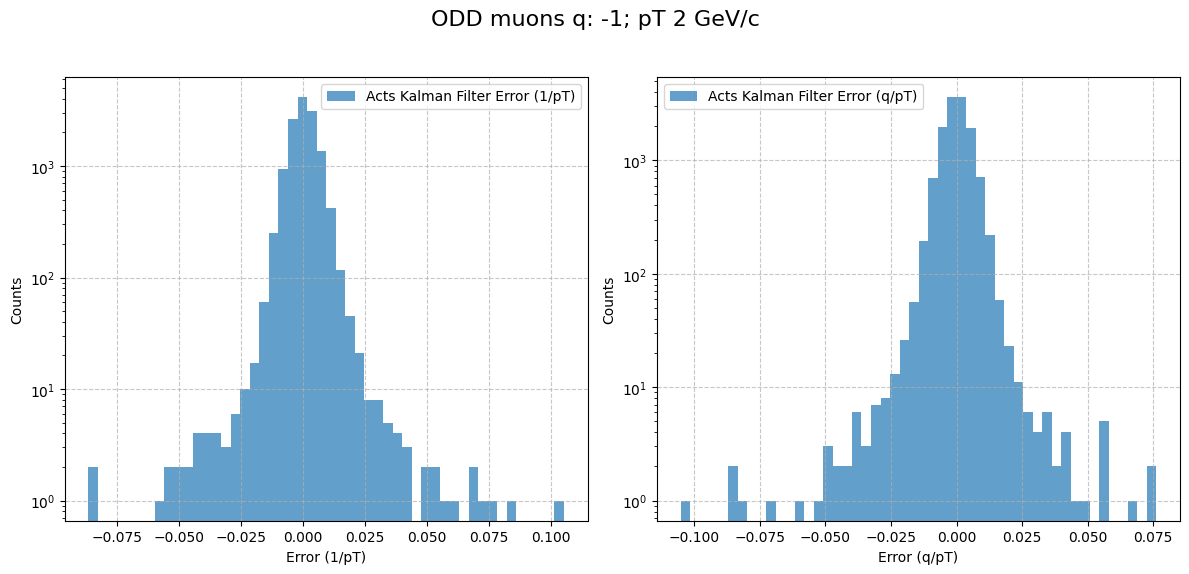

In [47]:
# Plot distribution of the errors
plt.figure(figsize=(12, 6))
# plt.suptitle("ODD muons q +- 1 pT 1 GeV/c", fontsize=16)
# plt.suptitle("ODD muons q: -1; pT 1 GeV/c", fontsize=16)
plt.suptitle("ODD muons q: -1; pT 2 GeV/c", fontsize=16)
tracks_error = 1 / all_events_tracks["pT"] - 1 / all_events_tracks["pT_truth"]
# Plot the errors
plt.subplot(1, 2, 1)
plt.hist(tracks_error, bins=50, alpha=0.7, label="Acts Kalman Filter Error (1/pT)")
plt.xlabel("Error (1/pT)")
plt.ylabel("Counts")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
# Plot the model errors
plt.subplot(1, 2, 2)
tracks_error_model = all_events_tracks["q_truth"] / all_events_tracks["pT"] - all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
plt.hist(tracks_error_model, bins=50, alpha=0.7, label="Acts Kalman Filter Error (q/pT)")
plt.xlabel("Error (q/pT)")
plt.ylabel("Counts")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig(output_dir / "error_distributions_ACTS_1_pT_fatras.png", format="png")
plt.savefig(output_dir / f"error_distributions_ACTS_1_pT_{test_dir.split('_')[0]}.png", format="png")
plt.show()

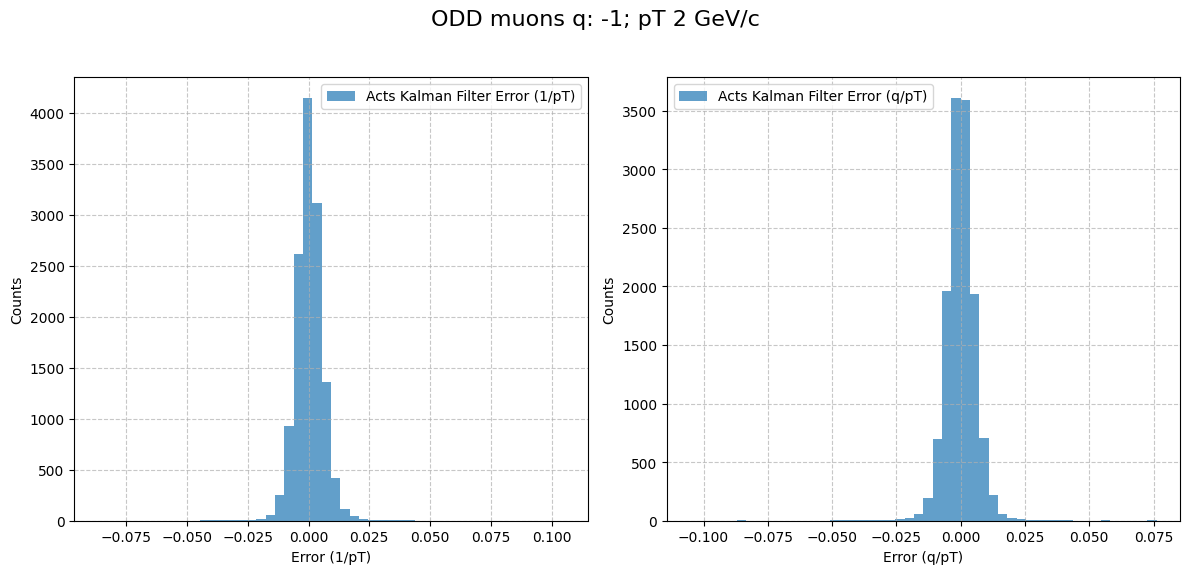

In [48]:
# Plot distribution of the errors
plt.figure(figsize=(12, 6))
# plt.suptitle("ODD muons q +- 1 pT 1 GeV/c", fontsize=16)
# plt.suptitle("ODD muons q: -1; pT 1 GeV/c", fontsize=16)
plt.suptitle("ODD muons q: -1; pT 2 GeV/c", fontsize=16)
tracks_error = 1 / all_events_tracks["pT"] - 1 / all_events_tracks["pT_truth"]
# Plot the errors
plt.subplot(1, 2, 1)
plt.hist(tracks_error, bins=50, alpha=0.7, label="Acts Kalman Filter Error (1/pT)")
plt.xlabel("Error (1/pT)")
plt.ylabel("Counts")
# plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
# Plot the model errors
plt.subplot(1, 2, 2)
tracks_error_model = all_events_tracks["q_truth"] / all_events_tracks["pT"] - all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
plt.hist(tracks_error_model, bins=50, alpha=0.7, label="Acts Kalman Filter Error (q/pT)")
plt.xlabel("Error (q/pT)")
plt.ylabel("Counts")
# plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / f"error_distributions_ACTS_1_pT_no_log_{test_dir.split('_')[0]}.png", format="png")
plt.show()

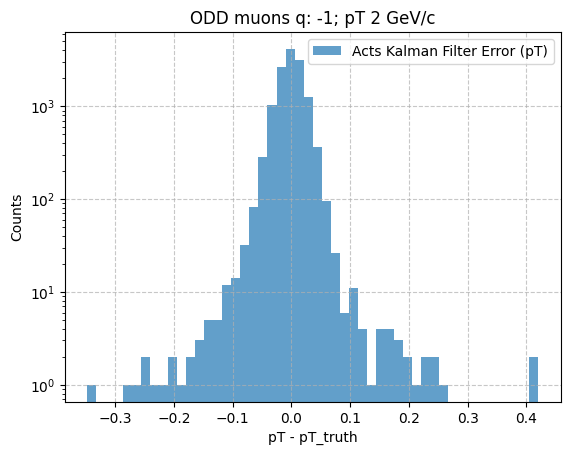

In [49]:
# Plot distribution of the errors
plt.figure()
# plt.suptitle("Error Distributions", fontsize=16)
# plt.title("ODD muons single charge pT 1 GeV/c")
# plt.title("ODD muons q +- 1 pT 1 GeV/c")
# plt.title("ODD muons q: -1; pT 1 GeV/c")
plt.title("ODD muons q: -1; pT 2 GeV/c")
tracks_error = all_events_tracks["pT"] - all_events_tracks["pT_truth"]
# Plot the errors
# plt.subplot(1, 2, 1)
plt.hist(tracks_error, bins=50, alpha=0.7, label="Acts Kalman Filter Error (pT)")
plt.xlabel("pT - pT_truth")
plt.ylabel("Counts")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
# # Plot the model errors
# plt.subplot(1, 2, 2)
# tracks_error_model = all_events_tracks["q_truth"] / all_events_tracks["pT"] - all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
# plt.hist(tracks_error_model, bins=50, alpha=0.7, label="Acts Kalman Filter Error (q/pT)")
# plt.xlabel("Error (q/pT)")
# plt.ylabel("Counts")
# plt.yscale("log")
# plt.grid(True, linestyle="--", alpha=0.7)
# plt.legend()
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / f"error_distributions_ACTS_pT_{test_dir.split('_')[0]}.png", format="png")
plt.show()

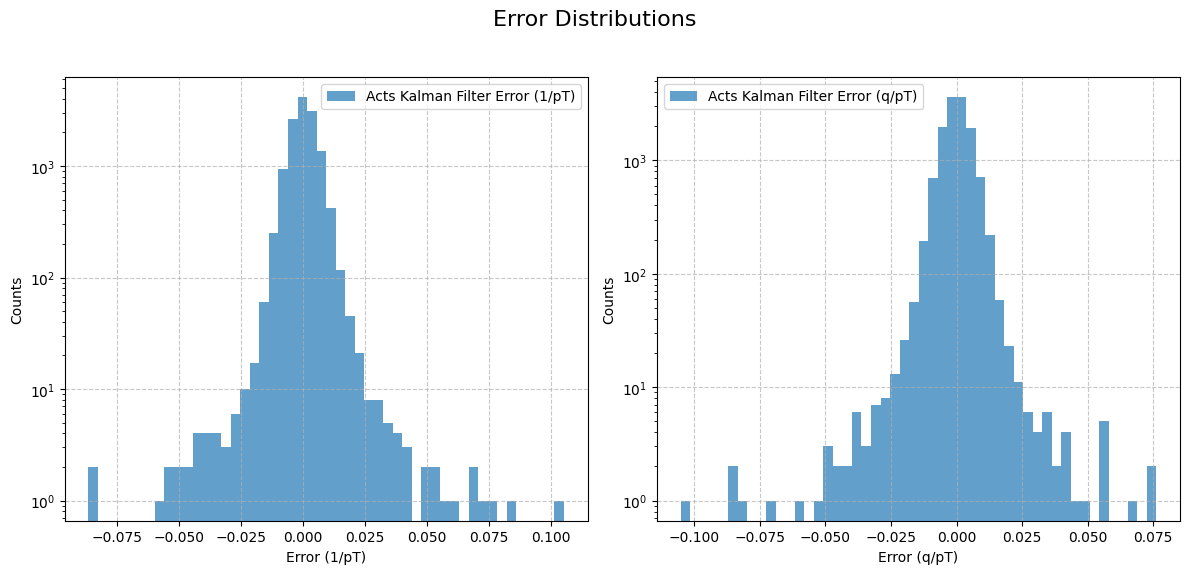

In [50]:
# Plot distribution of the errors
plt.figure(figsize=(12, 6))
plt.suptitle("Error Distributions", fontsize=16)
tracks_error = 1 / all_events_tracks["pT"] - 1 / all_events_tracks["pT_truth"]
# Plot the errors
plt.subplot(1, 2, 1)
plt.hist(tracks_error, bins=50, alpha=0.7, label="Acts Kalman Filter Error (1/pT)")
plt.xlabel("Error (1/pT)")
plt.ylabel("Counts")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
# Plot the model errors
plt.subplot(1, 2, 2)
tracks_error_model = all_events_tracks["q_truth"] / all_events_tracks["pT"] - all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
plt.hist(tracks_error_model, bins=50, alpha=0.7, label="Acts Kalman Filter Error (q/pT)")
plt.xlabel("Error (q/pT)")
plt.ylabel("Counts")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig(output_dir / "error_distributions.png", format="png")
plt.show()

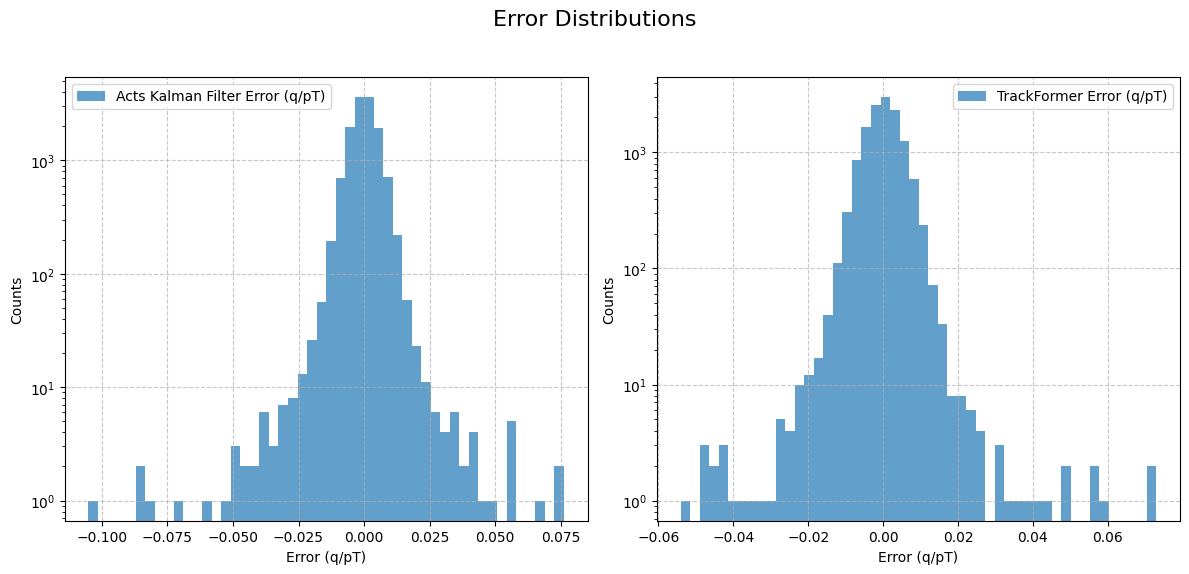

In [51]:
# Plot distribution of the errors
plt.figure(figsize=(12, 6))
plt.suptitle("Error Distributions", fontsize=16)
tracks_error = all_events_tracks["q_truth"] / all_events_tracks["pT"] - all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
# Plot the errors
plt.subplot(1, 2, 1)
plt.hist(tracks_error, bins=50, alpha=0.7, label="Acts Kalman Filter Error (q/pT)")
plt.xlabel("Error (q/pT)")
plt.ylabel("Counts")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
# Plot the model errors
plt.subplot(1, 2, 2)
tracks_error_model = all_events_tracks["q/p_T_pred"] - all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
plt.hist(tracks_error_model, bins=50, alpha=0.7, label="TrackFormer Error (q/pT)")
plt.xlabel("Error (q/pT)")
plt.ylabel("Counts")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig(output_dir / "error_distributions.png", format="png")
plt.show()

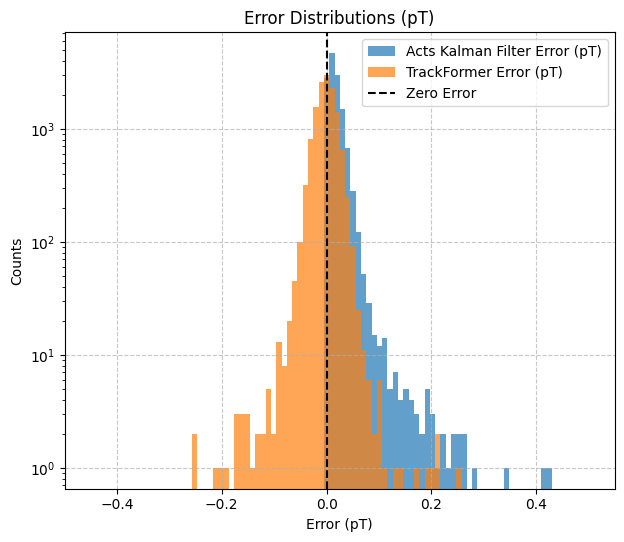

In [52]:
# Plot distribution of the errors of pT
plt.figure(figsize=(12, 6))
# bins = np.linspace(-0.5, 2.5, 100)
bins = np.linspace(-0.5, 0.5, 100)
# plt.suptitle("Error Distributions", fontsize=16)
tracks_error = np.abs(all_events_tracks["pT"] - all_events_tracks["pT_truth"])
# Plot the errors
plt.subplot(1, 2, 1)
plt.hist(tracks_error, bins=bins, alpha=0.7, label="Acts Kalman Filter Error (pT)")
tracks_error_model = np.abs(1/all_events_tracks["q/p_T_pred"]) - all_events_tracks["pT_truth"]
plt.xlabel("Error (pT)")
plt.ylabel("Counts")
plt.hist(tracks_error_model, bins=bins, alpha=0.7, label="TrackFormer Error (pT)")
plt.axvline(0, color="black", linestyle="--", label="Zero Error")
plt.title("Error Distributions (pT)")
current_xlim = plt.xlim()
new_xlim = (max(current_xlim[0], -0.5), min(current_xlim[1], 2.5))
plt.xlim(new_xlim)
# plt.ylim(1, 1e5)
# plt.xticks(np.arange(-0.5, 2.6, 0.5))
plt.yticks(np.logspace(0, 5, 6))
plt.xscale("linear")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

# plt.xlabel("Error (pT)")
# plt.ylabel("Counts")
# plt.yscale("log")
# plt.grid(True, linestyle="--", alpha=0.7)
# plt.legend()
# # Plot the model errors
# plt.subplot(1, 2, 2)
# plt.hist(tracks_error_model, bins=bins, alpha=0.7, label="TrackFormer Error (pT)")
# plt.xlabel("Error (pT)")
# plt.ylabel("Counts")
# plt.yscale("log")
# plt.grid(True, linestyle="--", alpha=0.7)
# plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig(output_dir / "error_distributions.png", format="png")
plt.show()

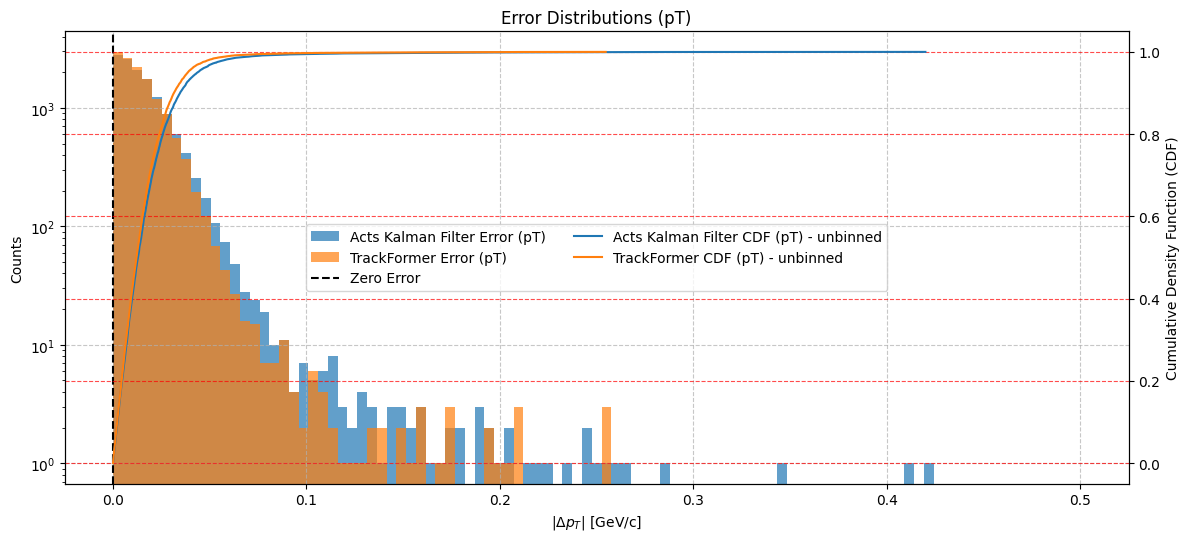

In [53]:
fig, ax1 = plt.subplots(figsize=(12, 6))
# bins = np.linspace(0, 2.5, 100)
bins = np.linspace(0, 0.5, 100)

# Calculate errors
tracks_error = np.abs(all_events_tracks["pT"] - all_events_tracks["pT_truth"])
tracks_error_model = np.abs(np.abs(1 / all_events_tracks["q/p_T_pred"]) - all_events_tracks["pT_truth"])

# Plot histograms
hist1 = ax1.hist(tracks_error, bins=bins, alpha=0.7, label="Acts Kalman Filter Error (pT)")
hist2 = ax1.hist(tracks_error_model, bins=bins, alpha=0.7, label="TrackFormer Error (pT)")
ax1.axvline(0, color="black", linestyle="--", label="Zero Error")
ax1.set_title("Error Distributions (pT)")
# ax1.set_xticks(np.arange(0, 2.6, 0.5))
ax1.set_yticks(np.logspace(0, 5, 6))
ax1.set_xscale("linear")
ax1.set_yscale("log")
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.set_xlabel(r"$|\Delta p_T|$ [GeV/c]")
ax1.set_ylabel("Counts")

# Twin the axis for CDF
ax2 = ax1.twinx()
tracks_error_sorted = np.sort(tracks_error)
tracks_error_model_sorted = np.sort(tracks_error_model)
# Calculate CDFs
cdf_tracks_error = np.arange(1, len(tracks_error_sorted) + 1) / len(tracks_error_sorted)
cdf_tracks_error_model = np.arange(1, len(tracks_error_model_sorted) + 1) / len(tracks_error_model_sorted)

line1, = ax2.plot(tracks_error_sorted, cdf_tracks_error, label="Acts Kalman Filter CDF (pT) - unbinned")
line2, = ax2.plot(tracks_error_model_sorted, cdf_tracks_error_model, label="TrackFormer CDF (pT) - unbinned")

# ax2.axhline(0.5, color="red", linestyle="--", label="50% CDF")
# ax2.axhline(0.9, color="red", linestyle="--", label="90% CDF")
ax2.set_ylabel("Cumulative Density Function (CDF)")
ax2.grid(True, linestyle="--", alpha=0.7, color='red')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + [line1, line2], labels1 + labels2, loc="upper center")
ax1.legend(lines1 + [line1, line2], labels1 + labels2, ncol=2, loc="center")

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "error_distributions_with_cdf.png", format="png", bbox_inches="tight")
plt.show()


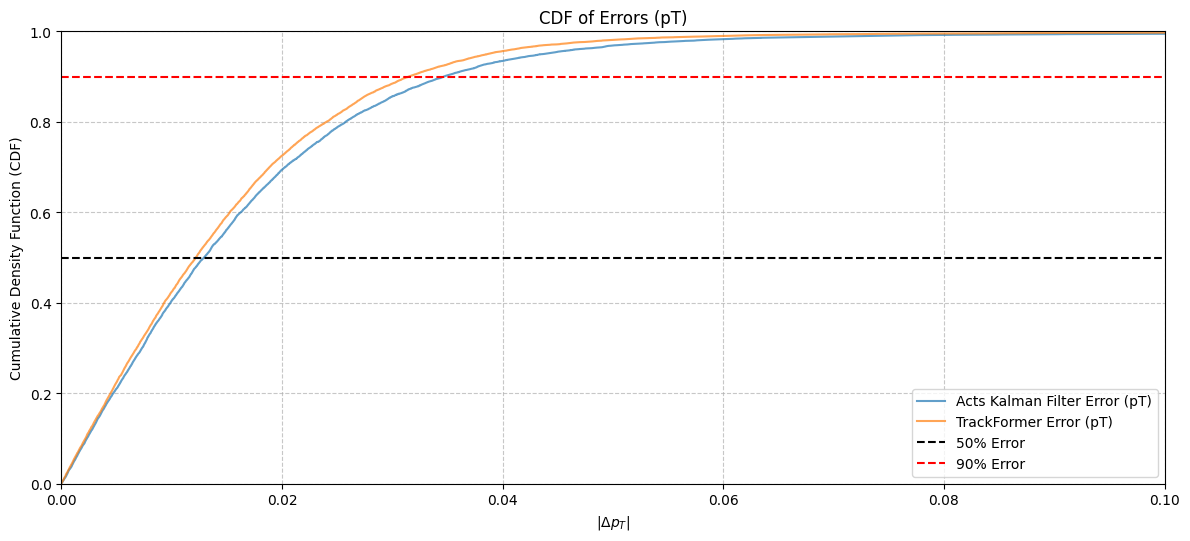

In [54]:
# Plot the CDF of the errors (both Acts Kalman Filter and TrackFormer in one plot) - unbinned
plt.figure(figsize=(12, 6))

tracks_error = np.abs(all_events_tracks["pT"] - all_events_tracks["pT_truth"])
tracks_error_model = np.abs(np.abs(1 / all_events_tracks["q/p_T_pred"]) - all_events_tracks["pT_truth"])

# Sort errors
tracks_error_sorted = np.sort(tracks_error)
tracks_error_model_sorted = np.sort(tracks_error_model)

# Compute CDF values
cdf_tracks_error = np.arange(1, len(tracks_error_sorted) + 1) / len(tracks_error_sorted)
cdf_tracks_error_model = np.arange(1, len(tracks_error_model_sorted) + 1) / len(tracks_error_model_sorted)

plt.plot(tracks_error_sorted, cdf_tracks_error, label="Acts Kalman Filter Error (pT)", alpha=0.7)
plt.plot(tracks_error_model_sorted, cdf_tracks_error_model, label="TrackFormer Error (pT)", alpha=0.7)
plt.axhline(0.5, color="black", linestyle="--", label="50% Error")
plt.axhline(0.9, color="red", linestyle="--", label="90% Error")
plt.title("CDF of Errors (pT)")
plt.xlabel("$|\Delta p_T|$")
plt.ylabel("Cumulative Density Function (CDF)")
plt.xlim(0, 0.1)
# plt.xlim(0, 0.01)
plt.ylim(0, 1)
plt.xscale("linear")
plt.yscale("linear")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "cdf_error_distributions.png", format="png")
plt.show()


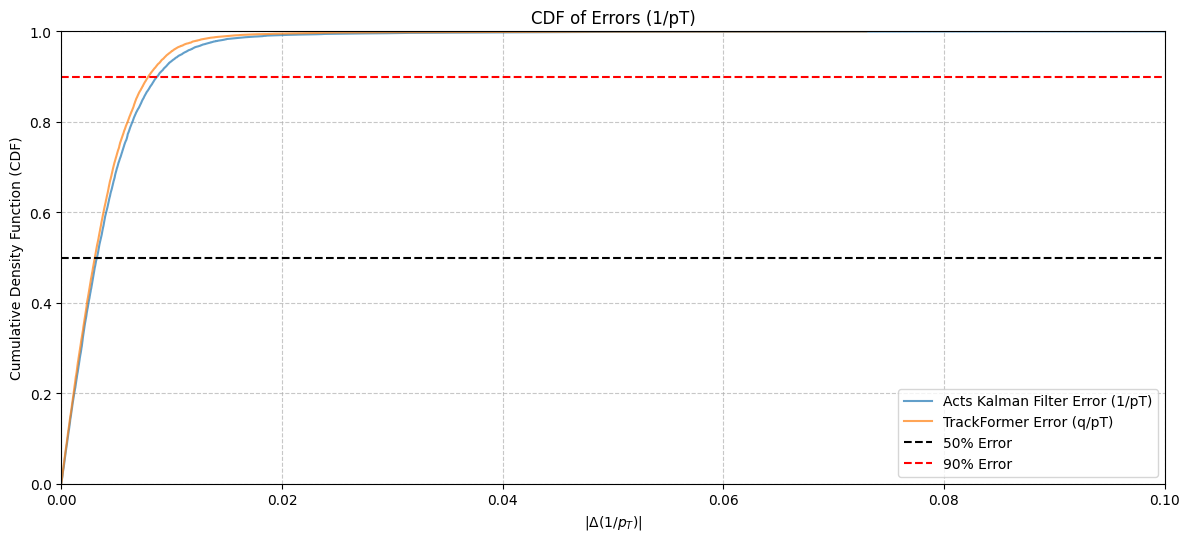

In [55]:
# Plot the CDF of the errors (both Acts Kalman Filter and TrackFormer in one plot) - unbinned
plt.figure(figsize=(12, 6))

tracks_error = np.abs(all_events_tracks["q_truth"]/all_events_tracks["pT"] - all_events_tracks["q_truth"]/all_events_tracks["pT_truth"])
tracks_error_model = np.abs(all_events_tracks["q/p_T_pred"] - all_events_tracks["q_truth"] / all_events_tracks["pT_truth"])

# Sort errors
tracks_error_sorted = np.sort(tracks_error)
tracks_error_model_sorted = np.sort(tracks_error_model)

# Compute CDF values
cdf_tracks_error = np.arange(1, len(tracks_error_sorted) + 1) / len(tracks_error_sorted)
cdf_tracks_error_model = np.arange(1, len(tracks_error_model_sorted) + 1) / len(tracks_error_model_sorted)

plt.plot(tracks_error_sorted, cdf_tracks_error, label="Acts Kalman Filter Error (1/pT)", alpha=0.7)
plt.plot(tracks_error_model_sorted, cdf_tracks_error_model, label="TrackFormer Error (q/pT)", alpha=0.7)
plt.axhline(0.5, color="black", linestyle="--", label="50% Error")
plt.axhline(0.9, color="red", linestyle="--", label="90% Error")
plt.title("CDF of Errors (1/pT)")
plt.xlabel("$|\Delta (1/p_T)|$")
plt.ylabel("Cumulative Density Function (CDF)")
plt.xlim(0, 0.1)
plt.ylim(0, 1)
plt.xscale("linear")
plt.yscale("linear")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "cdf_error_distributions_q_pT.png", format="png")
plt.show()

In [56]:
print(all_events_tracks.columns)

Index(['track_id', 'seed_id', 'nStates', 'nMajorityHits', 'nMeasurements',
       'nOutliers', 'nHoles', 'nSharedHits', 'chi2', 'ndf', 'chi2/ndf', 'pT',
       'eta', 'phi', 'truthMatchProbability', 'good/duplicate/fake', 'Hits_ID',
       'event_id', 'particle_id', 'particle_type', 'process', 'vx_truth',
       'vy_truth', 'vz_truth', 'vt_truth', 'px_truth', 'py_truth', 'pz_truth',
       'm_truth', 'q_truth', 'event_id_truth', 'pT_truth', 'p_truth',
       'eta_truth', 'n_particle_hits', 'event', 'n_hits_track', 'n_hits_truth',
       'q/p_T_pred', 'pz_pred'],
      dtype='object')


(13180,)
(13180,)


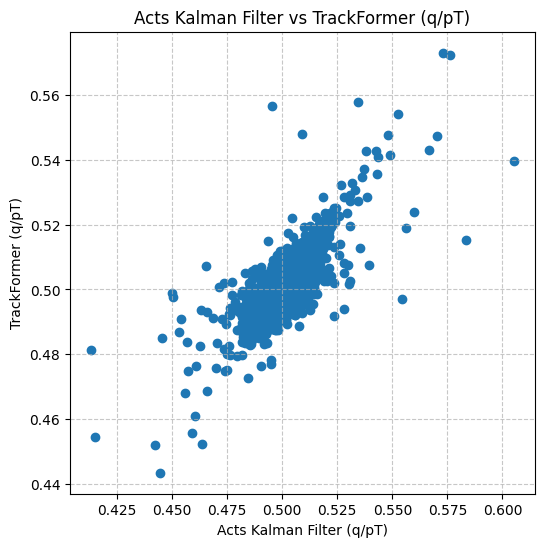

In [57]:
# Scatter plot of q/pT model vs q/pT algorithm
plt.figure(figsize=(6, 6))
# Acts Kalman Filter error
tracks_error = np.abs(all_events_tracks["q_truth"]/all_events_tracks["pT"])# - 1/all_events_tracks["pT_truth"]
# Model error
tracks_error_model = np.abs(all_events_tracks["q/p_T_pred"])# - np.abs(all_events_tracks["q_truth"] / all_events_tracks["pT_truth"])
print(tracks_error.shape)
print(tracks_error_model.shape)
plt.scatter(
    tracks_error,
    tracks_error_model,
    # alpha=0.5,
)
plt.xlabel("Acts Kalman Filter (q/pT)")
plt.ylabel("TrackFormer (q/pT)")
plt.title("Acts Kalman Filter vs TrackFormer (q/pT)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
# plt.xlim(-0.1, 0.1)
# plt.ylim(-0.1, 0.1)
# plt.savefig("acts_vs_trackformer_error.png")
plt.show()

Number of tracks with |eta| < 1: 13180
                event  track_id           tr
0      event000000000         0   498.911364
1      event000000000         1   623.775266
2      event000000000         2  1020.533532
3      event000000000         3  1028.431324
4      event000000000         4   464.556044
...               ...       ...          ...
39393  event000000199       193  1026.488513
39394  event000000199       194   947.228225
39395  event000000199       195   975.250258
39396  event000000199       196   362.426557
39397  event000000199       197   464.441609

[39398 rows x 3 columns]


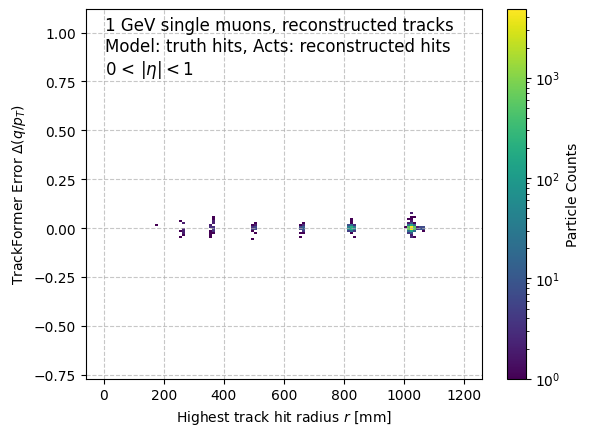

In [58]:
# Scatter plot of q/pT model vs the r value of the last hit

plt.figure()
# Select only the tracks with |eta| < max_abs_eta
min_abs_eta = 0
# min_abs_eta = 1
# max_abs_eta = 3
max_abs_eta = 1
# max_abs_eta = 2
eta_selection = np.abs(all_events_tracks["eta_truth"]) <= max_abs_eta
eta_selection &= np.abs(all_events_tracks["eta_truth"]) >= min_abs_eta
all_events_tracks_eta = all_events_tracks[eta_selection]
print(f"Number of tracks with |eta| < {max_abs_eta}: {len(all_events_tracks_eta)}")

q_pT_truth = all_events_tracks_eta["q_truth"] / all_events_tracks_eta["pT_truth"]
# Acts Kalman Filter error
tracks_error = all_events_tracks_eta["q_truth"] / all_events_tracks_eta["pT"] - q_pT_truth
# Model error
tracks_error_model = all_events_tracks_eta["q/p_T_pred"] - q_pT_truth

# Get the last hit radius for each track
all_events_hits["tr"] = np.sqrt(all_events_hits["tx"]**2 + all_events_hits["ty"]**2)
# all_events_hits_sorted = all_events_hits.sort_values("tr")
# Get the max hit radius for each track
last_hits = all_events_hits.groupby(["event", "track_id"]).aggregate({"tr": "max"}).reset_index()
print(f"{last_hits}")
# Merge the last hits with the tracks
all_events_tracks_tr = all_events_tracks_eta.merge(last_hits[["event", "track_id", "tr"]], on=["event", "track_id"], how="left", suffixes=("", "_last"))

x_min = 0
x_max = 1200
y_min = min(tracks_error_model.min(), -0.7)
y_max = max(tracks_error_model.max(), 0.7)

from matplotlib import colors
bins = [
        np.arange(x_min, x_max, 10),
        np.arange(y_min, y_max, 0.01)
    ]
plt.hist2d(
    all_events_tracks_tr["tr"],
    tracks_error_model,
    # bins=100,
    bins=bins,
    # range=[[-0.1, 0.1], [-0.1, 0.1]],
    # cmap="Blues",
    norm=colors.LogNorm()
)
plt.colorbar(label='Particle Counts')
plt.xlabel(r"Highest track hit radius $r$ [mm]")
plt.ylabel(r"TrackFormer Error $\Delta (q/p_T)$")
# plt.title("Acts Kalman Filter vs TrackFormer Error (q/pT)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
# Add 5% to the limits
tr_range = 1200 - 0
# tracks_error_model_range = tracks_error_model.max() - tracks_error_model.min()
# tracks_error_model_range = y_max - y_min
tracks_error_model_range = y_max - y_min
x_increment = 0.05 * tr_range
y_top = 0.30 * tracks_error_model_range
y_bottom = 0.05 * tracks_error_model_range
plt.xlim(0 - x_increment, tr_range + x_increment)
plt.ylim(y_min - y_bottom, y_max + y_top)
# Add a text indicating that the model uses truth hits, acts uses reconstructed hits and both use the same reconstructed tracks
plt.text(0.05, 0.98, f"1 GeV single muons, reconstructed tracks\nModel: truth hits, Acts: reconstructed hits\n{min_abs_eta} < $|\eta| < {max_abs_eta}$",
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
        )

plt.savefig(output_dir / f"acts_vs_trackformer_error_vs_last_hit_radius_eta_{min_abs_eta}_{max_abs_eta}.png")
plt.show()

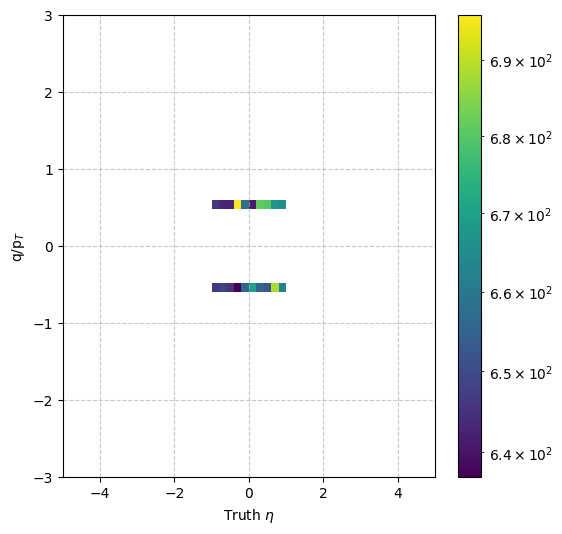

In [59]:
from matplotlib import colors

peta = all_events_tracks["eta_truth"]
plt.figure(figsize=(6, 6))
plt.hist2d(
    peta,
    all_events_tracks["q_truth"] / all_events_tracks["pT_truth"],
    bins=50,
    range=[[-5, 5], [-3, 3]],
    # cmap="Blues",
    # cmin=0,
    # cmax=100,
    # alpha=0.7,
    norm=colors.LogNorm(),
    label=f"Input {i}",
    density=False,
)
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"q/p$_T$")
# plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.title("Input Distributions")
plt.colorbar()
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(
    output_dir / "input_distributions_peta_qopT.png", format="png", bbox_inches="tight"
)
plt.show()

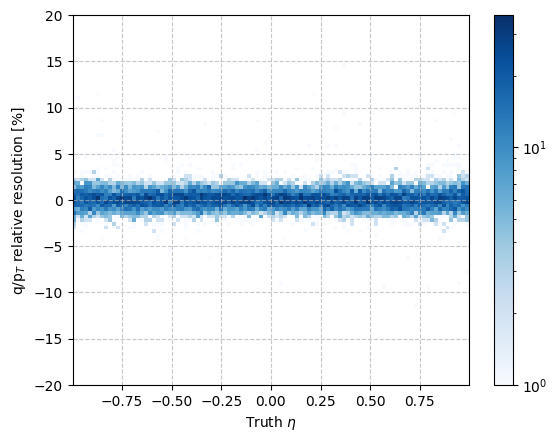

Results/ActsODD/rdphiz_n_hits_7_qopT_pz_POC_Acts_muons_eta_1_trained_ODD_full_odd_output_muons_2


In [60]:
from matplotlib import colors

plt.figure()
q_pT_truth = all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
plt.hist2d(
    peta,
    ((all_events_tracks["q/p_T_pred"] - q_pT_truth) / q_pT_truth) * 100,
    bins=100,
    # range=[[-5, 5], [-3, 3]],
    range=[None, [-20, 20]],
    # range=[None, [-50, 80]],
    cmap="Blues",
    # cmin=0,
    # cmax=100,
    norm=colors.LogNorm(),
    # alpha=0.7,
    label=f"Input {i}",
    density=False,
)
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"q/p$_T$ relative resolution [%]")
# plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.title("Input Distributions")
plt.colorbar()
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(
    output_dir / "input_distributions_2d_relative_error.png", format="png", bbox_inches="tight",
)
plt.show()
print(output_dir)

In [61]:
# Make bins in peta
model_data_bins = {}
model_name = "MSE"
model_data_bins[model_name] = []
peta = all_events_tracks["eta_truth"]
bin_size = 0.1
eta_bins = np.arange(
    -(config["max_abs_eta"] + bin_size / 2),
    config["max_abs_eta"] + bin_size / 2 + bin_size,
    bin_size,
)
bin_centers = 0.5 * (eta_bins[:-1] + eta_bins[1:])

pi_true_values = all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
pi_pred_values = all_events_tracks["q/p_T_pred"]

# # Convert as float32
# pi_true_values = pi_true_values.astype(np.float32)
# pi_pred_values = pi_pred_values.astype(np.float32)
# peta = np.arctanh(all_events_tracks["pz_truth"].astype(np.float32) / all_events_tracks["p_truth"].astype(np.float32))

model_data_bins = compute_resolution_bins(peta, eta_bins, pi_true_values, pi_pred_values, model_data_bins, model_name="MSE")

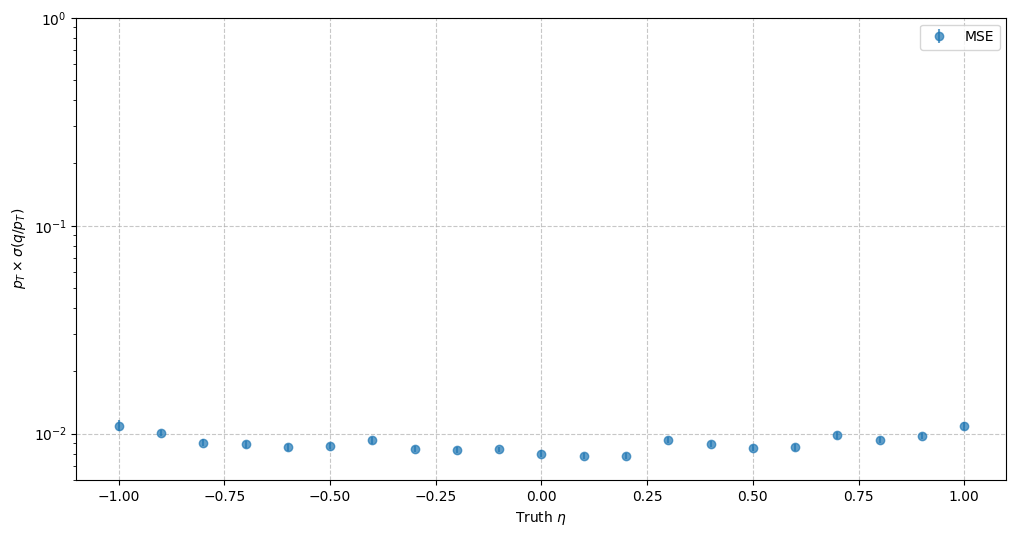

In [62]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name in model_data_bins:
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.ylim(6e-3, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta_tracks.png", format="png", bbox_inches="tight"
)
plt.show()

In [63]:
pi_true_values = all_events_tracks["q_truth"] / all_events_tracks["pT_truth"]
pi_pred_values = all_events_tracks["q_truth"] / all_events_tracks["pT"]

model_data_bins = compute_resolution_bins(peta, eta_bins, pi_true_values, pi_pred_values, model_data_bins, model_name="ACTS_Tracks")

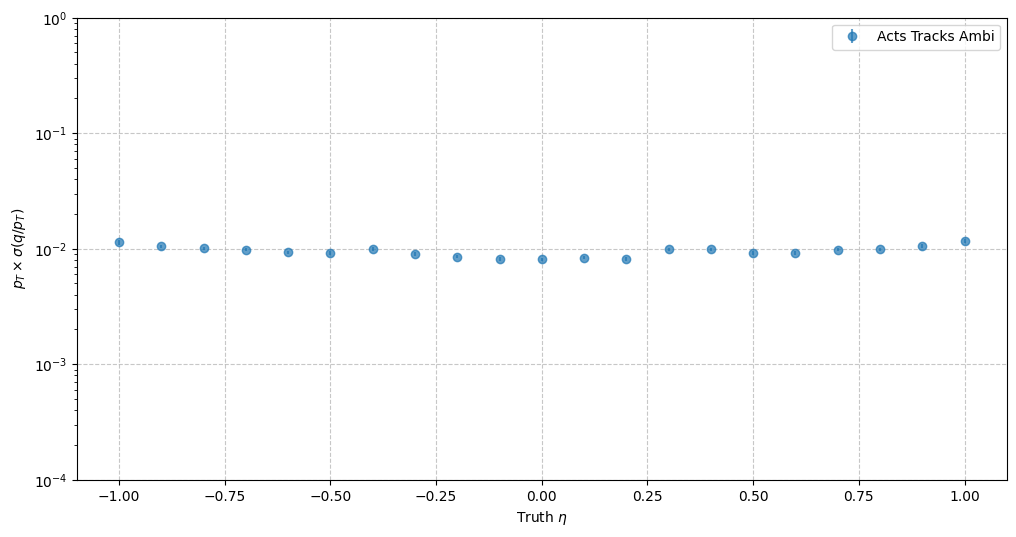

In [64]:
# Make the plot
plt.figure(figsize=(12, 6))
model_name = "ACTS_Tracks"
model_data = model_data_bins[model_name]
# Convert to numpy arrays
model_data = np.array(model_data)
# Get the means and stds
bin_stds = model_data[:, 1]
bin_pi_true_values = model_data[:, 3]
bin_stds_err = model_data[:, 5]
plt.errorbar(
    bin_centers,
    bin_stds*bin_pi_true_values,
    yerr=bin_stds_err*bin_pi_true_values,
    label="Acts Tracks Ambi",
    alpha=0.7,
    fmt="o",
)

plt.legend()
plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.ylim(1e-4, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta_tracks_ambi.png", format="png", bbox_inches="tight"
)
plt.show()

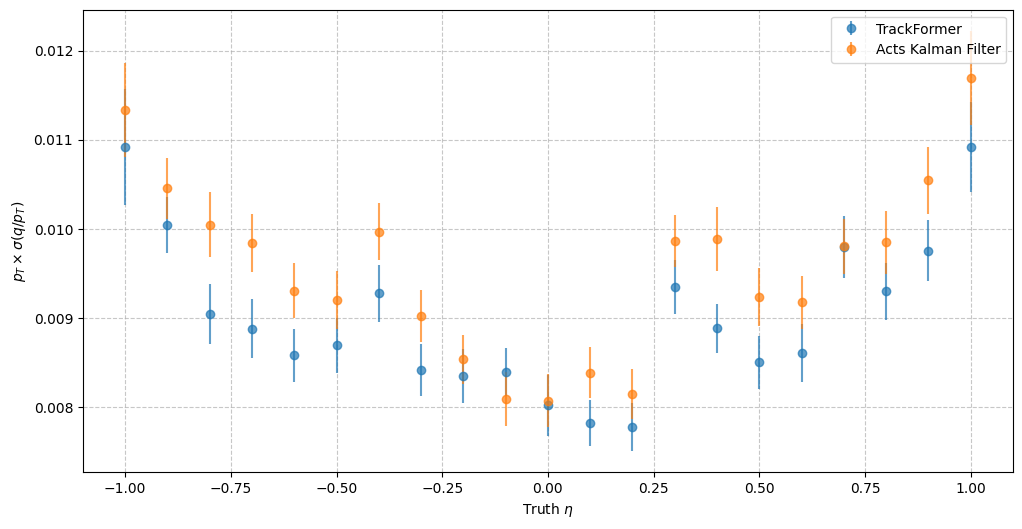

In [65]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name, model_data in model_data_bins.items():
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]

    if model_name == "MSE":
        model_name = "TrackFormer"
    if model_name == "ACTS_Tracks":
        model_name = "Acts Kalman Filter"
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(1e-4, 1)
# plt.ylim(1e-4, 5e-2)
plt.savefig(
    output_dir / "relative_error_vs_peta_comparison_no_log.png", format="png", bbox_inches="tight"
)
plt.show()

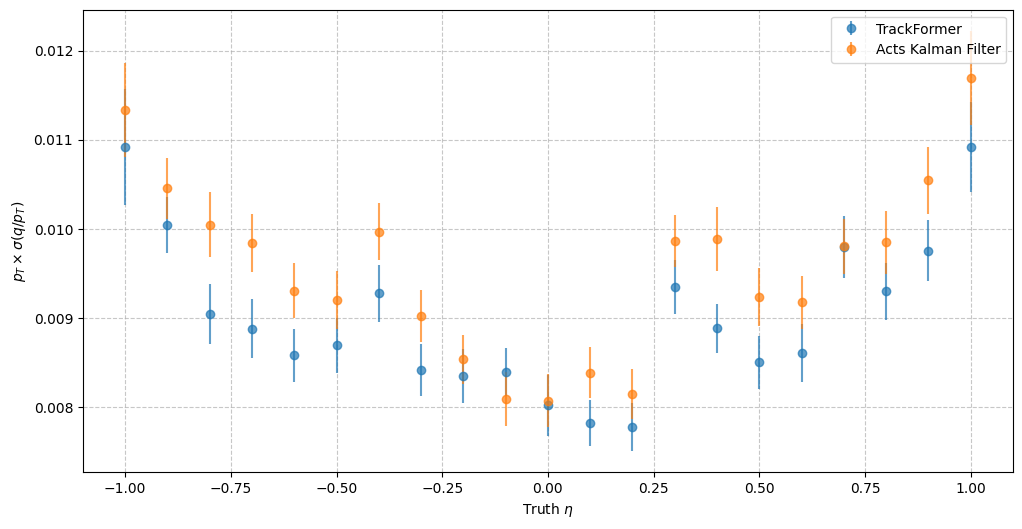

In [66]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name, model_data in model_data_bins.items():
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]

    if model_name == "MSE":
        model_name = "TrackFormer"
    if model_name == "ACTS_Tracks":
        model_name = "Acts Kalman Filter"
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(1e-4, 1)
# plt.ylim(1e-4, 5e-2)
plt.savefig(
    output_dir / "relative_error_vs_peta_comparison_no_log.png", format="png", bbox_inches="tight"
)
plt.show()

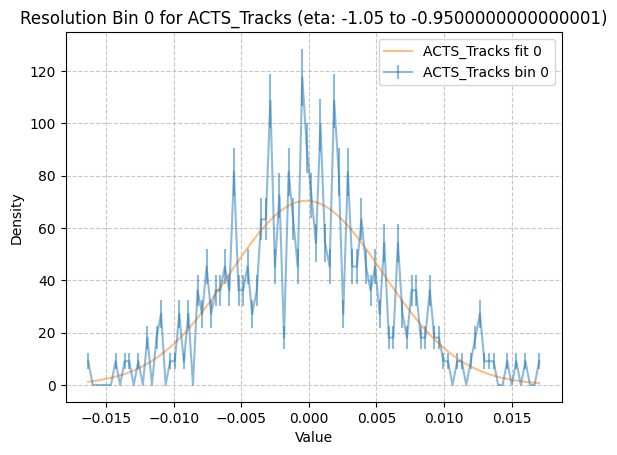

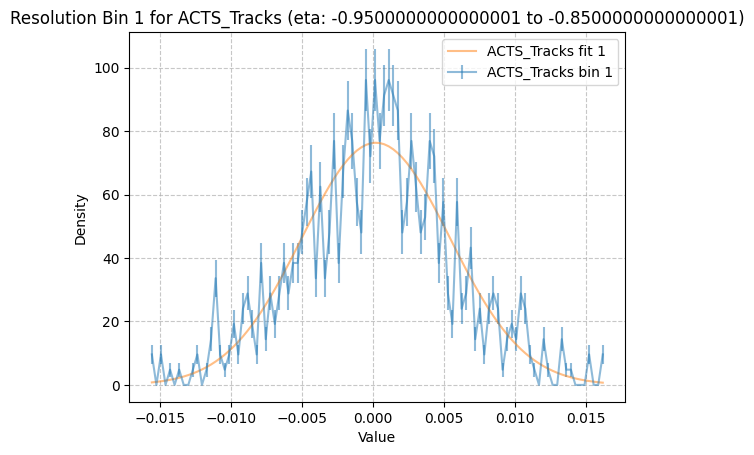

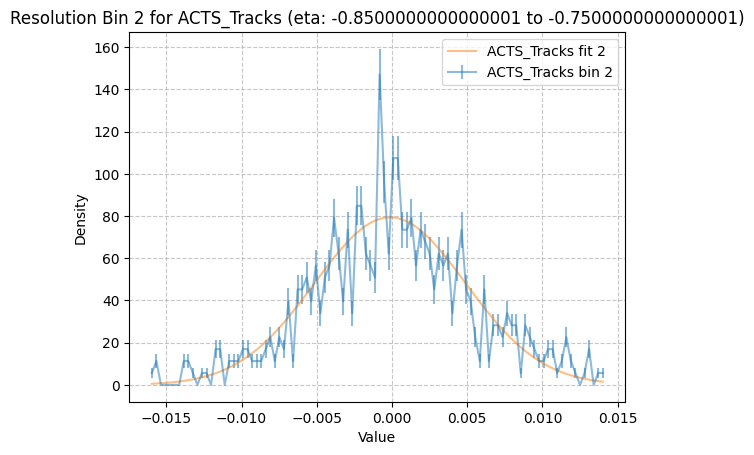

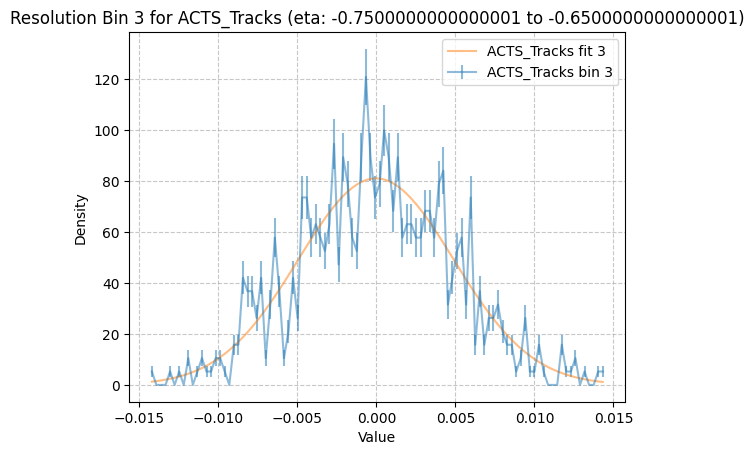

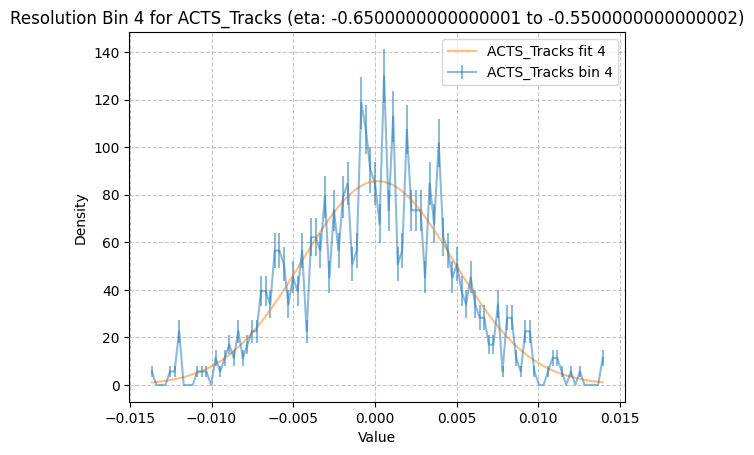

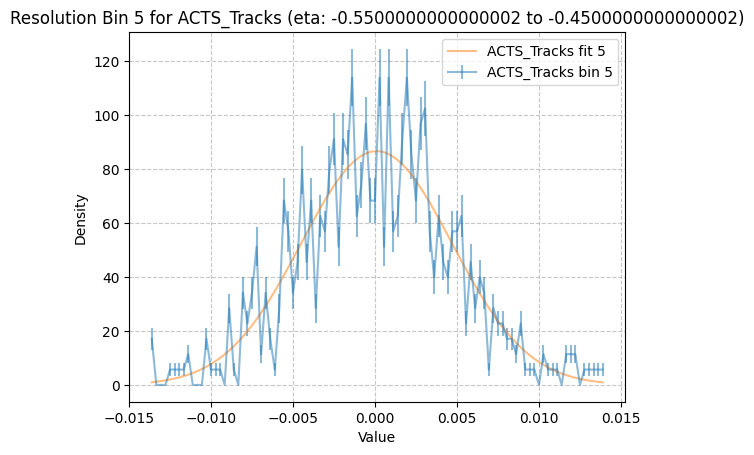

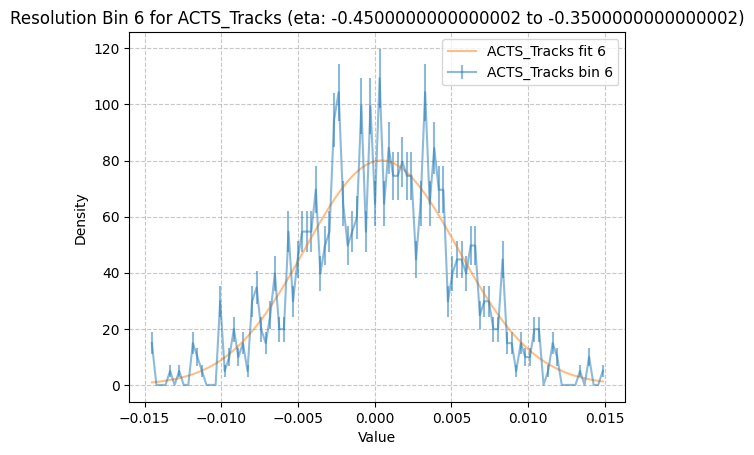

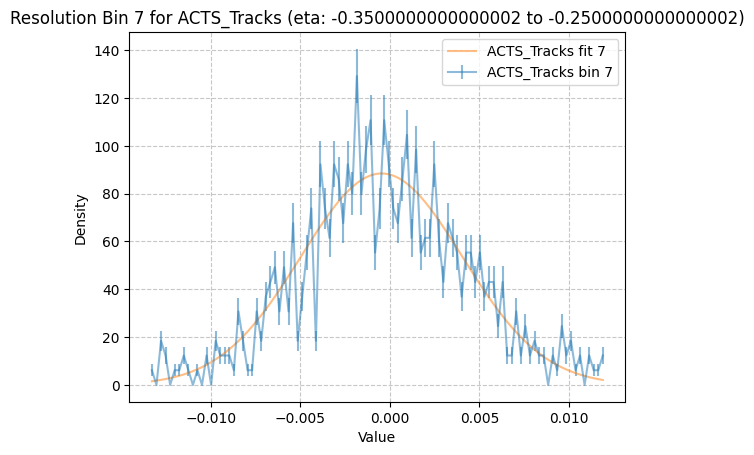

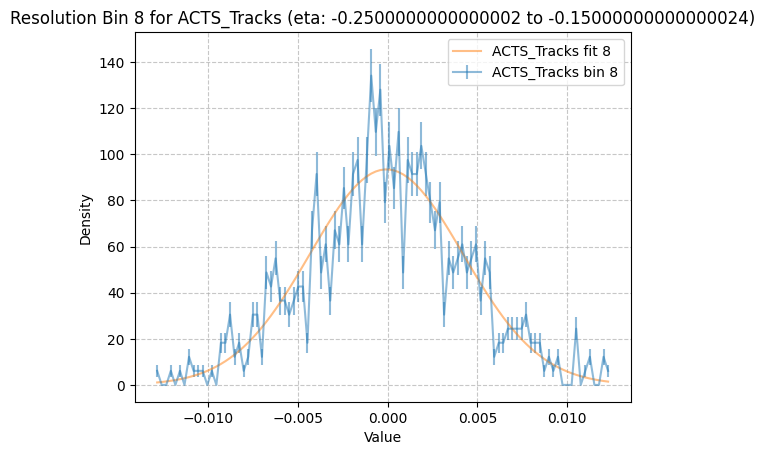

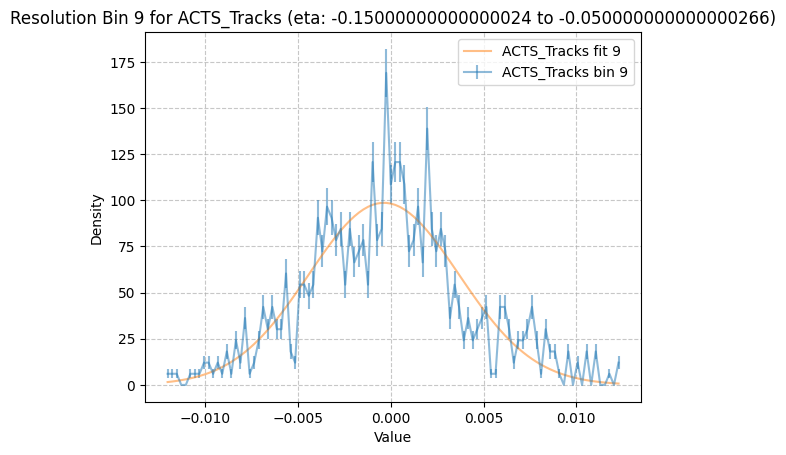

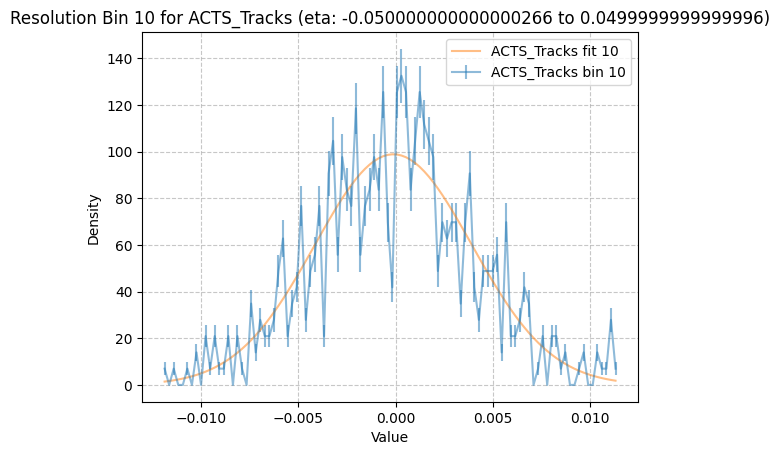

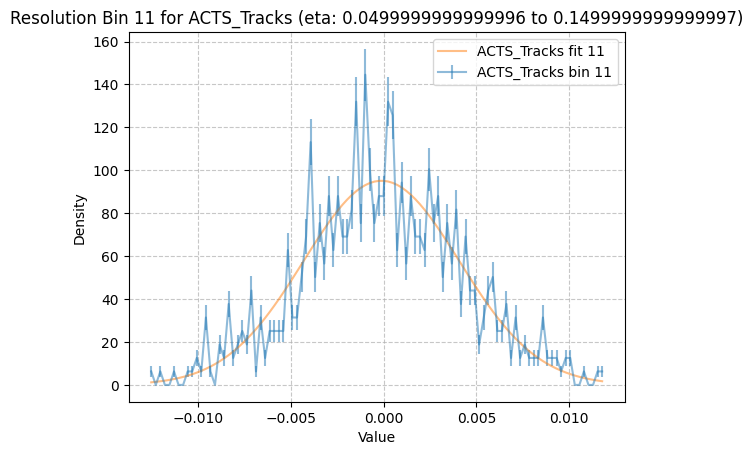

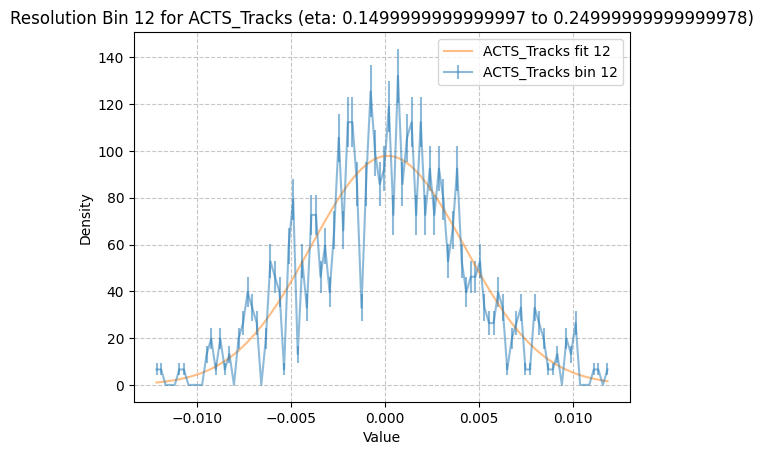

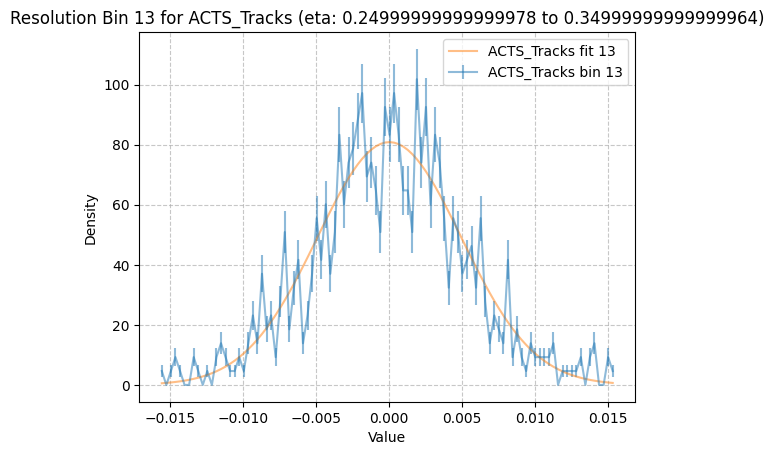

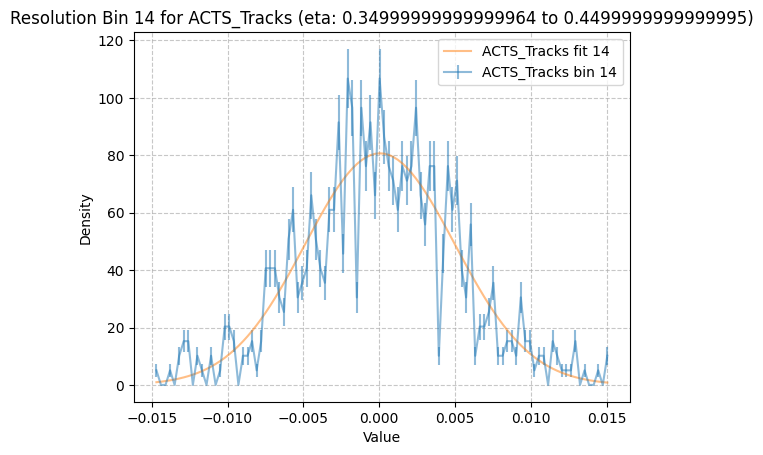

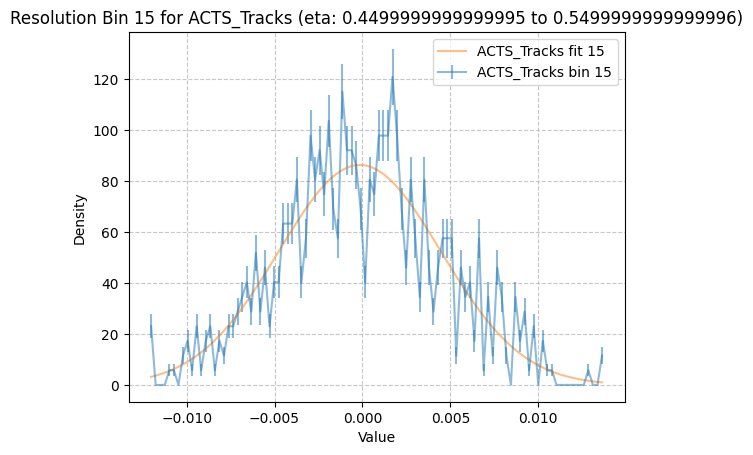

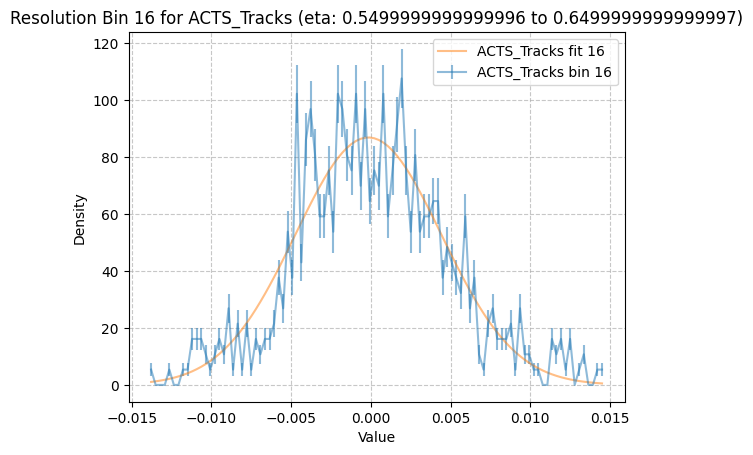

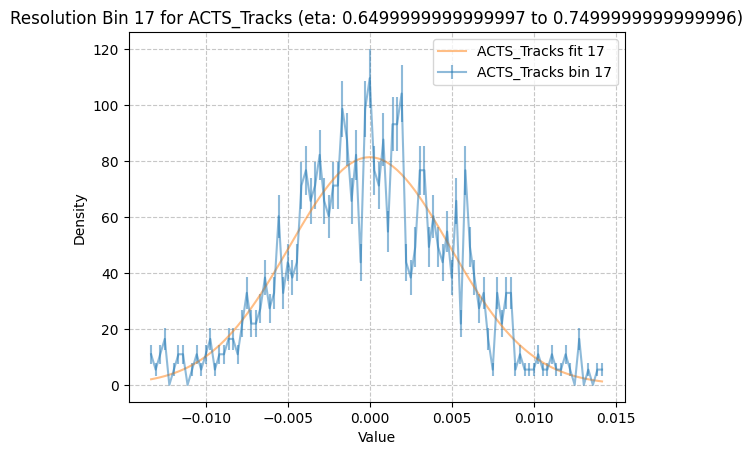

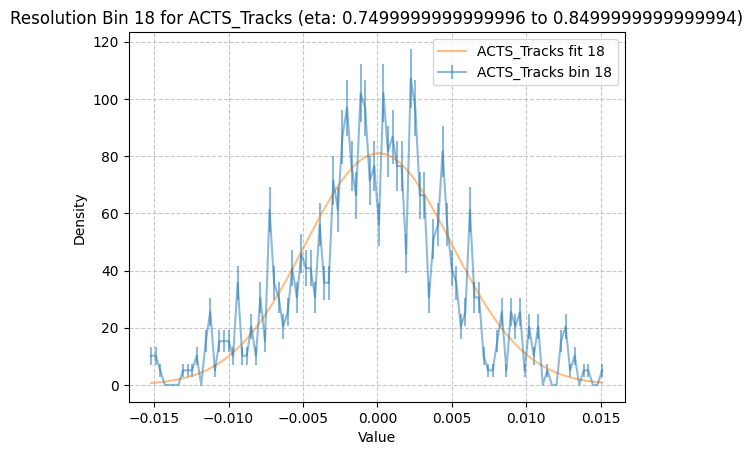

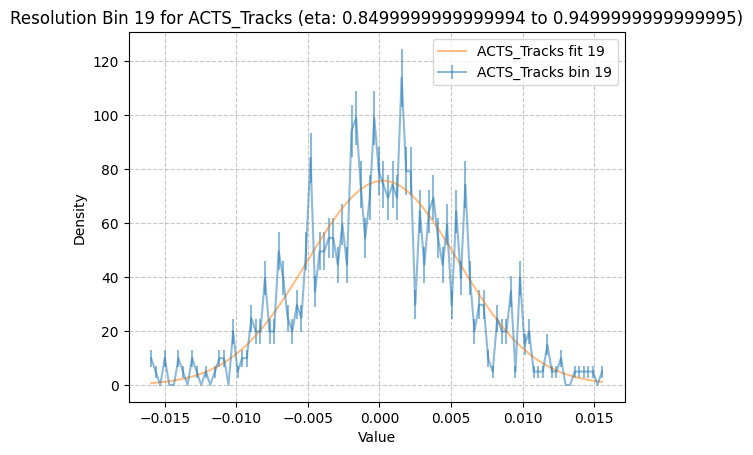

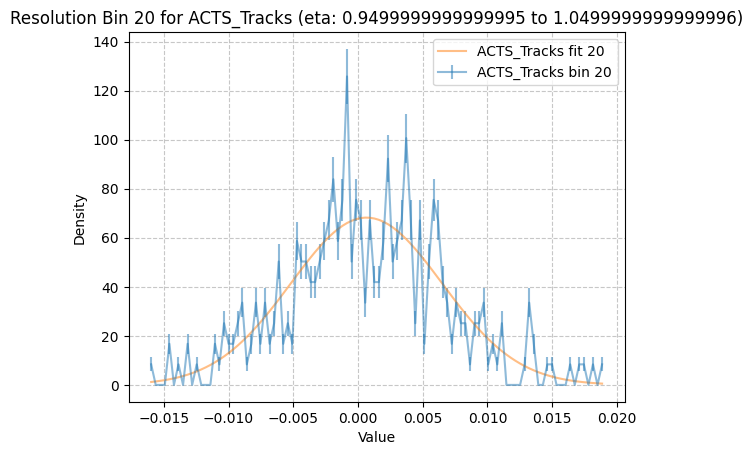

In [67]:
def plot_resolution_bins(peta, bins, pi_true_values, pi_pred_values, model_data_bins, model_name="MSE"):
    # Loop over each bin
    for i in range(len(bins) - 1):
        plt.figure()
        plt.title(f"Resolution Bin {i} for {model_name} (eta: {bins[i]} to {bins[i + 1]})")

        # Get the indices of the points in this bin
        bin_indices = np.where((peta >= bins[i]) & (peta < bins[i + 1]))[0]
        # Get the values in this bin
        pi_pred_values_bin = pi_pred_values[bin_indices]
        pi_true_values_bin = pi_true_values[bin_indices]
        # If there are no values in this bin, skip it
        if len(pi_pred_values_bin) == 0 or len(pi_true_values_bin) == 0:
            # Append the bin data to the model data
            continue
        bin_values, removed_outliers_bin = (
                        compute_track_resolution(
                            pi_true_values_bin,
                            pi_pred_values_bin,
                        )
                    )

        # Compute the mean and std of the values in this bin
        n_bins = 100
        # n_bins = 20
        n, model_bins = np.histogram(
            bin_values, bins=n_bins, density=True#, range=fit_range
        )
        # Fit a Gaussian to the histogram.
        from scipy.stats import norm
        from scipy.optimize import curve_fit
        if not all(np.isnan(val) for val in n):
            param_model, cov_model = curve_fit(
            norm.pdf,
            model_bins[:-1],
            n,
            p0=[np.mean(bin_values), np.std(bin_values)],
            bounds=([-np.inf, 0], [np.inf, np.inf]),
        )
            perr_model = np.sqrt(np.diag(cov_model))
            model_mean, model_std = param_model
            model_mean_err, model_std_err = perr_model
        else:
            model_mean = np.nan
            model_std = np.nan
            model_mean_err = np.nan
            model_std_err = np.nan
    
        # bin_mean = model_mean
        # bin_std = model_std
        # bin_mean_err = model_mean_err
        # bin_std_err = model_std_err
        # bin_count = len(bin_indices)
        # bin_pi_true_value = np.mean(np.abs(1/pi_true_values_bin))
        # # Append the bin data to the model data
        # model_data_bins[model_name].append((bin_mean, bin_std, bin_count, bin_pi_true_value, bin_mean_err, bin_std_err))
        plt.errorbar(
            model_bins[:-1] + (model_bins[1] - model_bins[0]) / 2,
            n,
            yerr=np.sqrt(n),
            label=f"{model_name} bin {i}",
            alpha=0.5,
        )
        plt.plot(
            model_bins[:-1] + (model_bins[1] - model_bins[0]) / 2,
            norm.pdf(model_bins[:-1], model_mean, model_std),
            label=f"{model_name} fit {i}",
            alpha=0.5,
        )
        plt.xlabel("Value")
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.xscale("linear")
        plt.yscale("linear")
        plt.show()
    # return model_data_bins

pi_true_values = all_events_tracks["q_truth"]/all_events_tracks["pT_truth"]
pi_pred_values = all_events_tracks["q_truth"]/all_events_tracks["pT"]


# pi_true_values = 1/all_events_tracks["pT_truth"]
# pi_pred_values = 1/all_events_tracks["pT"]

# model_data_bins = compute_resolution_bins(peta, eta_bins, pi_true_values, pi_pred_values, model_data_bins, model_name="ACTS_Tracks")

# Plot resolution bins for MSE model
plot_resolution_bins(
    peta,
    eta_bins,
    pi_true_values,
    pi_pred_values,
    model_data_bins,
    model_name="ACTS_Tracks"
)

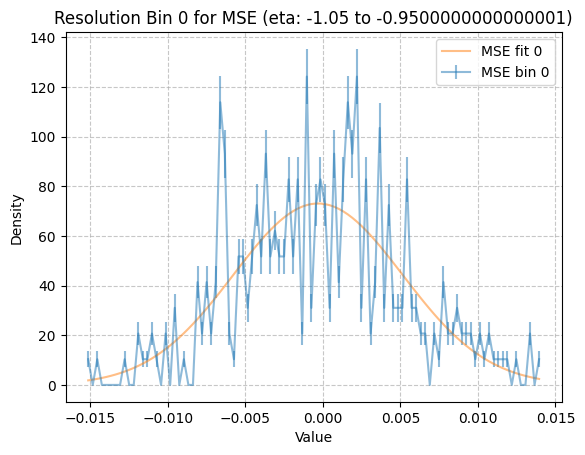

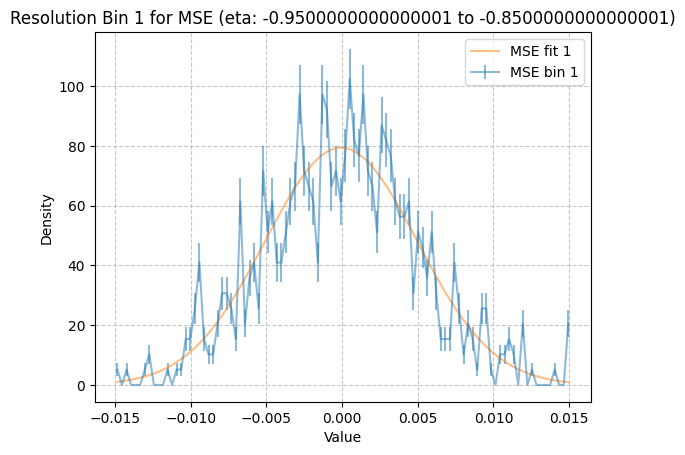

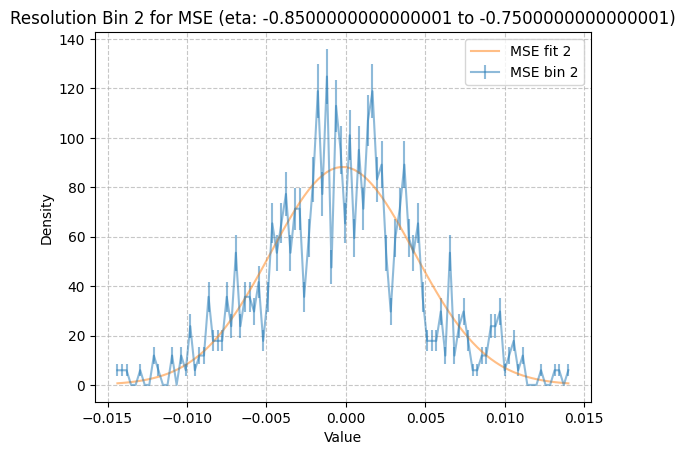

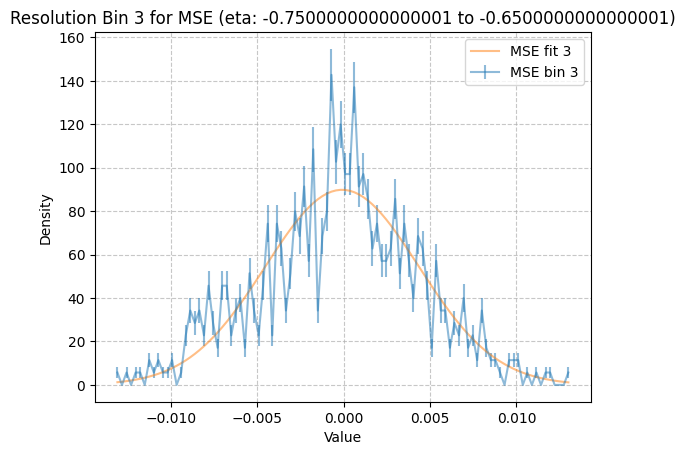

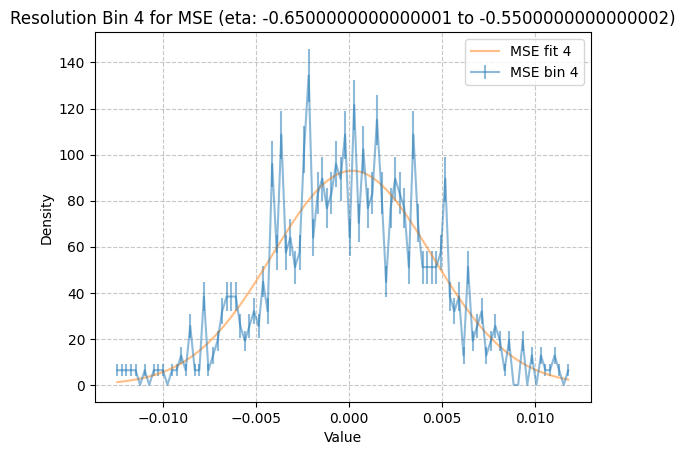

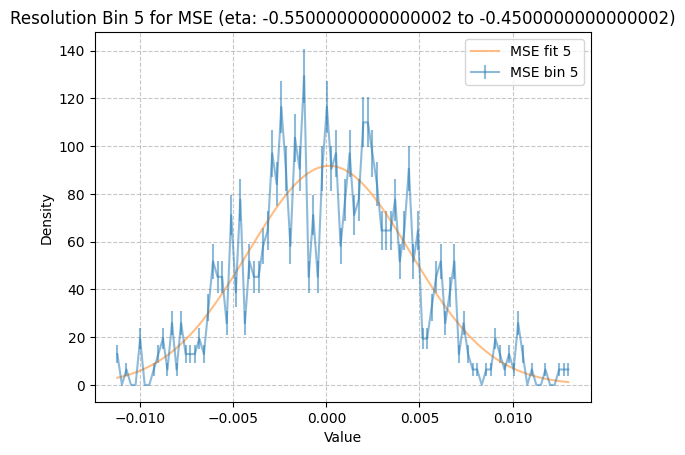

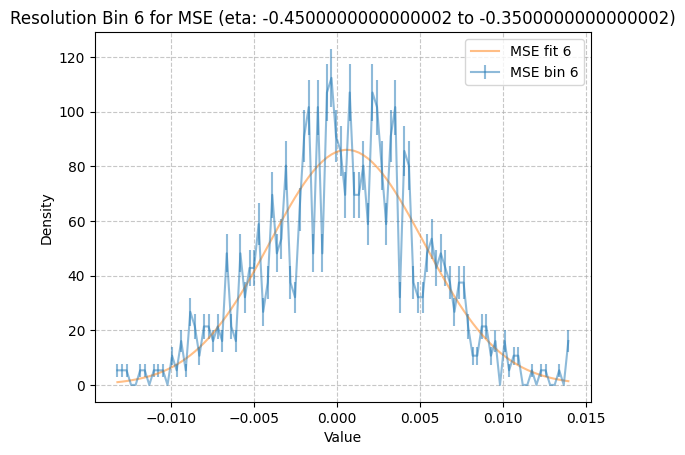

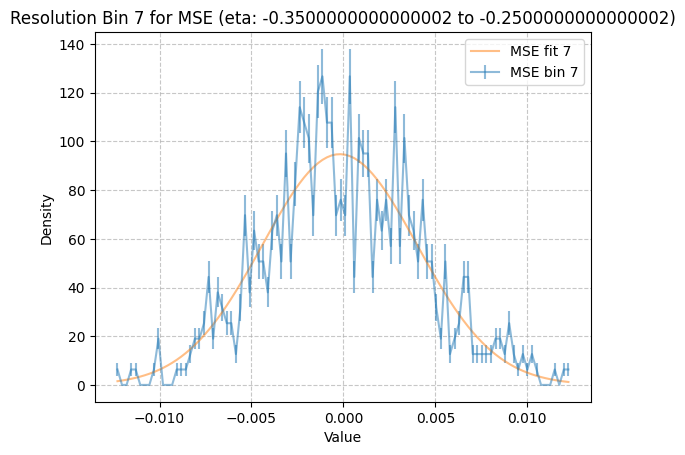

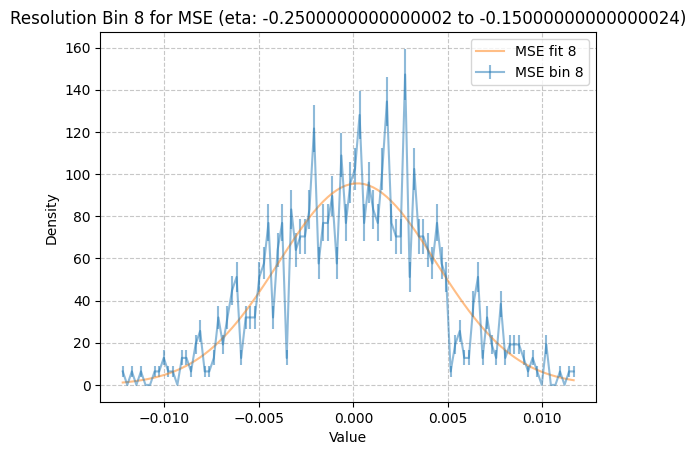

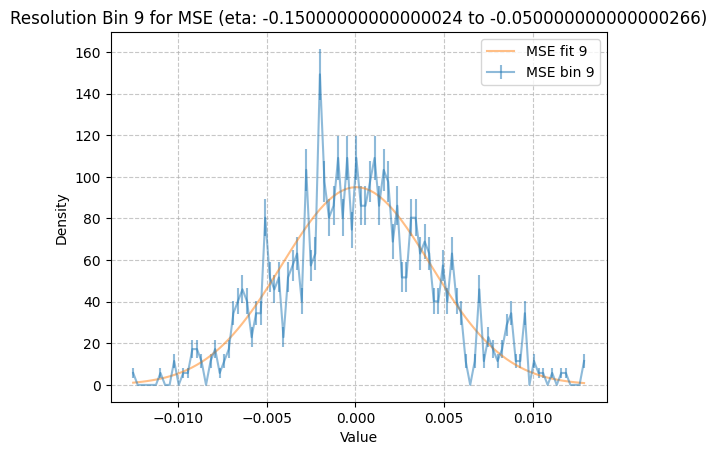

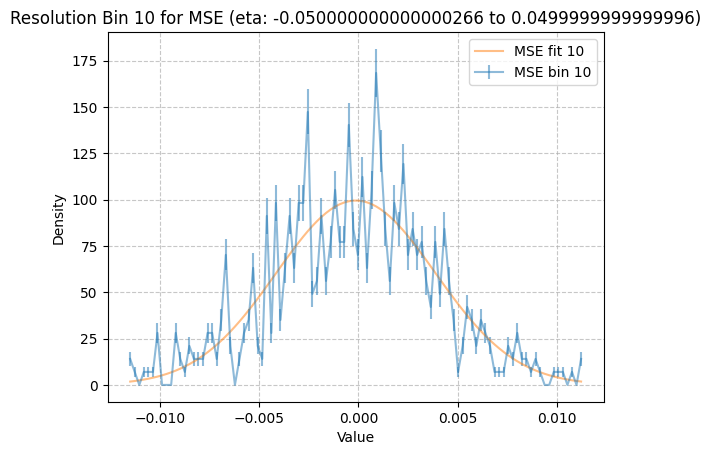

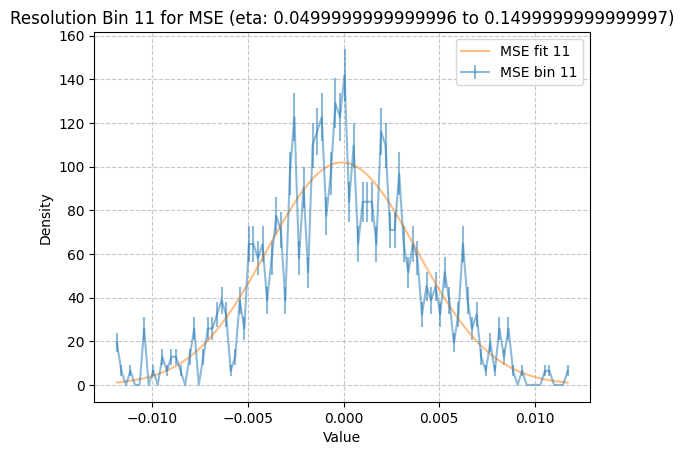

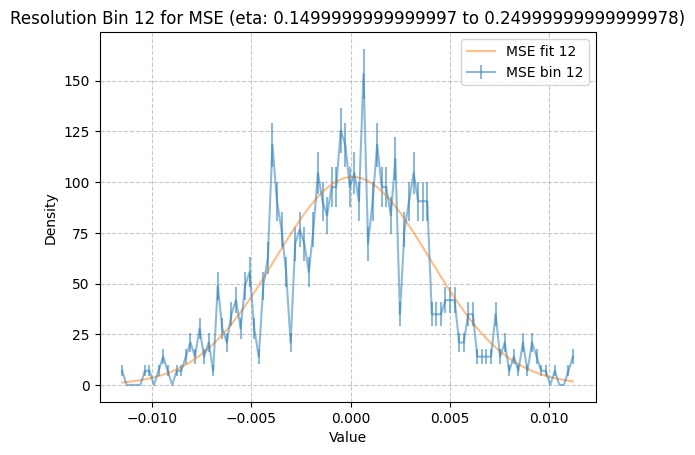

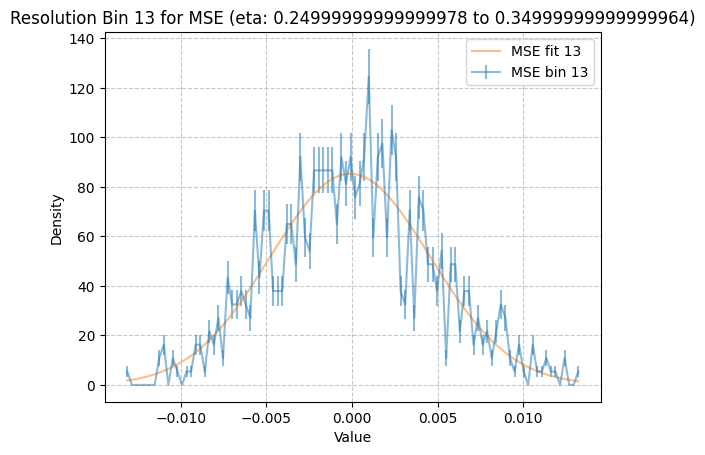

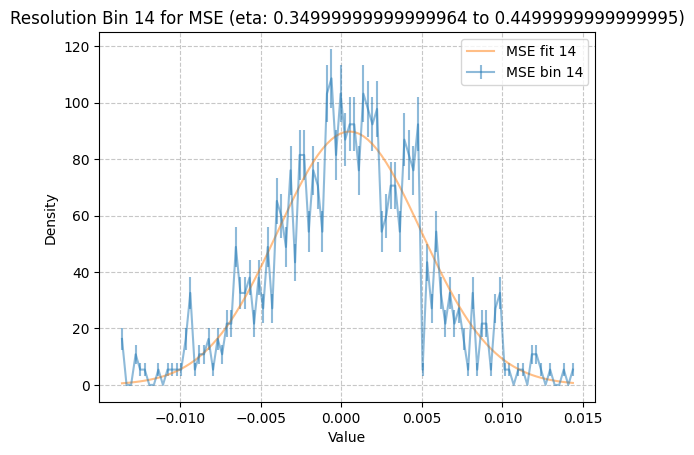

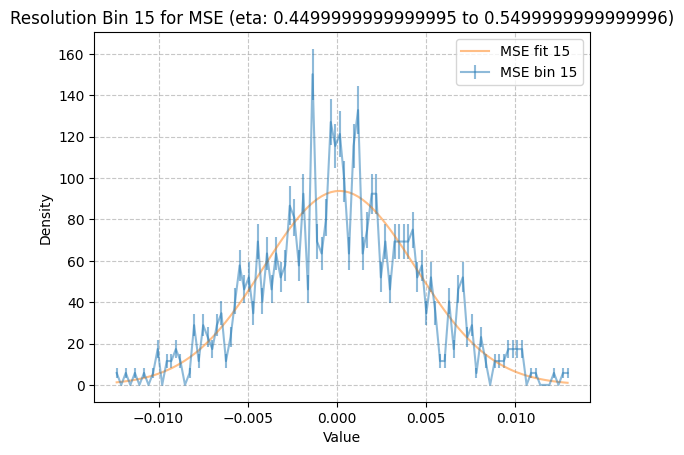

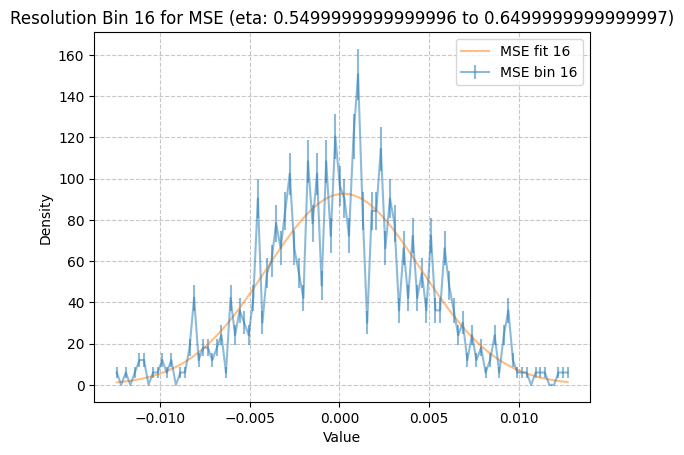

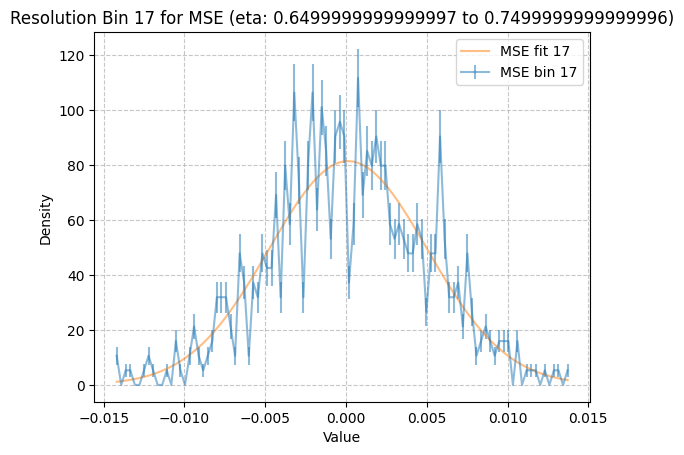

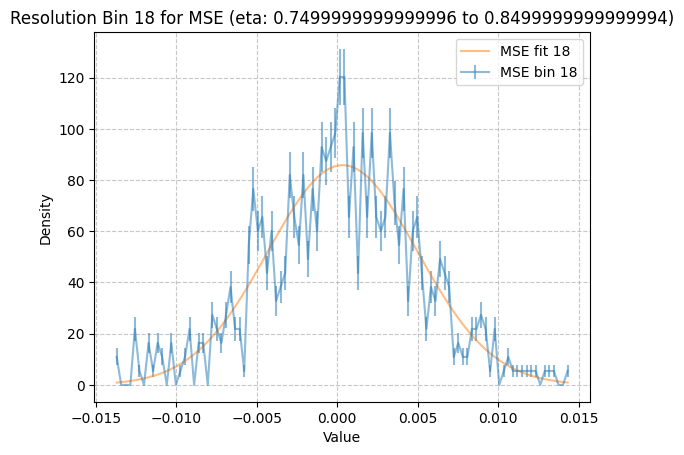

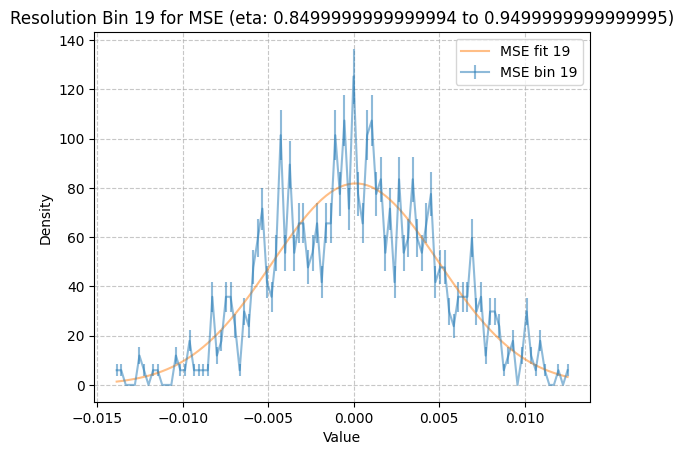

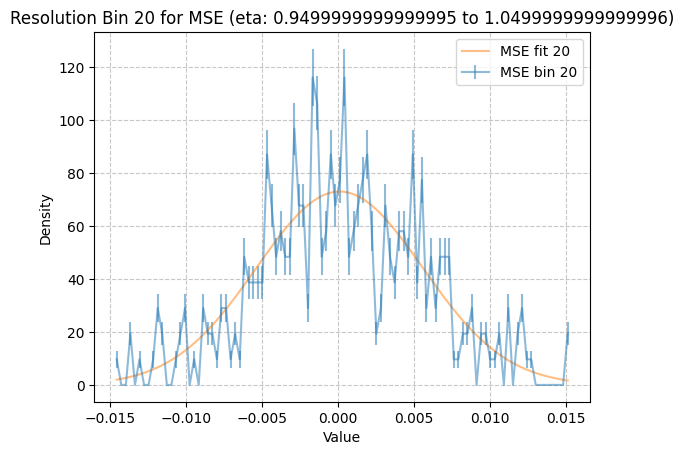

In [68]:
def plot_resolution_bins(peta, bins, pi_true_values, pi_pred_values, model_data_bins, model_name="MSE"):
    # Loop over each bin
    for i in range(len(bins) - 1):
        plt.figure()
        plt.title(f"Resolution Bin {i} for {model_name} (eta: {bins[i]} to {bins[i + 1]})")

        # Get the indices of the points in this bin
        bin_indices = np.where((peta >= bins[i]) & (peta < bins[i + 1]))[0]
        # Get the values in this bin
        pi_pred_values_bin = pi_pred_values[bin_indices]
        pi_true_values_bin = pi_true_values[bin_indices]
        # If there are no values in this bin, skip it
        if len(pi_pred_values_bin) == 0 or len(pi_true_values_bin) == 0:
            # Append the bin data to the model data
            continue
        bin_values, removed_outliers_bin = (
                        compute_track_resolution(
                            pi_true_values_bin,
                            pi_pred_values_bin,
                        )
                    )

        # Compute the mean and std of the values in this bin
        n_bins = 100
        # n_bins = 20
        n, model_bins = np.histogram(
            bin_values, bins=n_bins, density=True#, range=fit_range
        )
        # Fit a Gaussian to the histogram.
        from scipy.stats import norm
        from scipy.optimize import curve_fit
        if not all(np.isnan(val) for val in n):
            param_model, cov_model = curve_fit(
            norm.pdf,
            model_bins[:-1],
            n,
            p0=[np.mean(bin_values), np.std(bin_values)],
            bounds=([-np.inf, 0], [np.inf, np.inf]),
        )
            perr_model = np.sqrt(np.diag(cov_model))
            model_mean, model_std = param_model
            model_mean_err, model_std_err = perr_model
        else:
            model_mean = np.nan
            model_std = np.nan
            model_mean_err = np.nan
            model_std_err = np.nan
    
        # bin_mean = model_mean
        # bin_std = model_std
        # bin_mean_err = model_mean_err
        # bin_std_err = model_std_err
        # bin_count = len(bin_indices)
        # bin_pi_true_value = np.mean(np.abs(1/pi_true_values_bin))
        # # Append the bin data to the model data
        # model_data_bins[model_name].append((bin_mean, bin_std, bin_count, bin_pi_true_value, bin_mean_err, bin_std_err))
        plt.errorbar(
            model_bins[:-1] + (model_bins[1] - model_bins[0]) / 2,
            n,
            yerr=np.sqrt(n),
            label=f"{model_name} bin {i}",
            alpha=0.5,
        )
        plt.plot(
            model_bins[:-1] + (model_bins[1] - model_bins[0]) / 2,
            norm.pdf(model_bins[:-1], model_mean, model_std),
            label=f"{model_name} fit {i}",
            alpha=0.5,
        )
        plt.xlabel("Value")
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.xscale("linear")
        plt.yscale("linear")
        plt.show()
    # return model_data_bins

pi_true_values = all_events_tracks["q_truth"]/all_events_tracks["pT_truth"]
pi_pred_values = all_events_tracks["q/p_T_pred"]


# pi_true_values = 1/all_events_tracks["pT_truth"]
# pi_pred_values = 1/all_events_tracks["pT"]

# model_data_bins = compute_resolution_bins(peta, eta_bins, pi_true_values, pi_pred_values, model_data_bins, model_name="ACTS_Tracks")

# Plot resolution bins for MSE model
plot_resolution_bins(
    peta,
    eta_bins,
    pi_true_values,
    pi_pred_values,
    model_data_bins,
    model_name="MSE"
)

# Truth Particle Hits

In [69]:
from copy import deepcopy
all_events_particles_list = []
all_events_processed = []
all_hits_list = []
dataset_wrapper.test_dataset.truth_tracks = True
for i in range(len(dataset_wrapper.test_dataset.available_events)):
    event = dataset_wrapper.test_dataset.available_events[i]
    # print(f"Loading event {event}")
    event_files = dataset_wrapper.test_dataset._load_event(event)
    processed_event = dataset_wrapper.test_dataset._preprocess_groups(event_files=deepcopy(event_files))
    # print(f"{list(processed_event) = }")
    hits, _, particles = event_files
    # Add Hit_ID to the hits dataframe (index)
    hits["hit_id"] = hits.index
    # Save number of hits
    number_of_hits = len(hits)

    # Add pT and p columns to the particles dataframe
    particles["pT"] = np.sqrt(particles["px"]**2 + particles["py"]**2)
    particles["p"] = np.sqrt(particles["px"]**2 + particles["py"]**2 + particles["pz"]**2)
    # Add eta column to the particles dataframe
    # Use np.arctanh to compute eta from pz and p
    # eta = 0.5 * np.log((1 + pz / p) / (1 - pz / p))
    # or equivalently
    # eta = np.arctanh(pz / p)
    particles["eta"] = np.arctanh(particles["pz"] / particles["p"])
    
    # Add "_truth" suffix to the columns of the particles dataframe
    particles = particles.rename(columns=lambda x: f"{x}_truth" if x not in ["particle_id", "particle_type", "process"] else x)
    # Count the number of hits per particle
    hit_particle_counts = hits.groupby("particle_id").size().to_frame(name="n_particle_hits")
    # This must be an integer
    assert hit_particle_counts["n_particle_hits"].dtype == "int64", f"n_particle_hits is not an integer, it is {hit_particle_counts['n_particle_hits'].dtype}"
    # Add index as a column
    hit_particle_counts = hit_particle_counts.reset_index()
    # Merge the hit counts with the particles dataframe
    particles = particles.merge(hit_particle_counts, on="particle_id", how="left")
    # print(f"{particles.columns = }")
    

    # processed_event = list(processed_event)

    # Add the event number to the tracks and hits dataframes
    particles["event"] = event
    hits["event"] = event

    # Remove the tracks with less than config["min_hits"] hits
    particles = particles[particles["n_particle_hits"] >= config["min_hits"]]
    particles = particles[np.abs(particles["eta_truth"]) <= config["max_abs_eta"]]

    # Keep only the particles that are in the specified particle types
    particle_types = config["particle_types"]
    particles = particles[particles["particle_type"].isin(particle_types)]

    # Merge with hits dataframe
    hits = pd.merge(
        hits,
        particles,
        on=["event", "particle_id"],
        how="inner",
        validate="many_to_one",
    )
    # print(f"{hits.columns = }")
    # print(f"{len(hits) = }")
    # Make sure there is no NaN in the tx, ty, tz columns of the hits dataframe
    assert hits["tx"].notna().all(), "There are NaN values in the tx column of the hits dataframe"
    assert hits["ty"].notna().all(), "There are NaN values in the ty column of the hits dataframe"
    assert hits["tz"].notna().all(), "There are NaN values in the tz column of the hits dataframe"
    # Count the number of duplicates in the hits dataframe
    duplicates = hits.duplicated(subset=["hit_id"], keep='first')
    n_duplicates = duplicates.sum()
    if n_duplicates > 0:
        print(f"Warning: There are {n_duplicates} duplicates in the hits dataframe for event {event}")
        # Print the duplicates
        all_duplicates = hits.duplicated(subset=["hit_id"], keep=False)
        duplicates_hits = hits[all_duplicates]
        # Print the duplicates grouped by hit_id
        duplicates_grouped = duplicates_hits.groupby("hit_id")
        # Show ["hit_id", "particle_id", "particle_id_track", "track_id"] for each group
        # Set the index to hit_id
        duplicates_summary = duplicates_grouped[["particle_id", "particle_id_track", "track_id"]].apply(lambda x: x)
        # Print the summary
        print(duplicates_summary)
        
        print(f"Number of duplicates: {n_duplicates}")



    # Compare the number of tracks with the size of the processed event
    # assert len(tracks) == len(processed_event), f"Number of tracks ({len(tracks)}) does not match the size of the processed event ({len(processed_event)}) for event {event}"
    
    # Reset particles index
    particles = particles.reset_index(drop=True)
    
    # Add the event to the list
    all_events_particles_list.append(particles)
    all_events_processed.append(processed_event)
    all_hits_list.append(hits)
    print(f"{particles.shape[0] = }") 
    print(f"{len(hits['particle_id'].unique()) = }") 
    print(f"{hits.shape = }") 
    assert particles.shape[0] == len(hits["particle_id"].unique())
    # break
    # if i > 10:
    #     break

# Concatenate all the events
all_events_particles = pd.concat(all_events_particles_list, ignore_index=True)
all_events_hits = pd.concat(all_hits_list, ignore_index=True)

particles.shape[0] = 78
len(hits['particle_id'].unique()) = 78
hits.shape = (1077, 34)
particles.shape[0] = 50
len(hits['particle_id'].unique()) = 50
hits.shape = (711, 34)
particles.shape[0] = 62
len(hits['particle_id'].unique()) = 62
hits.shape = (857, 34)
particles.shape[0] = 65
len(hits['particle_id'].unique()) = 65
hits.shape = (907, 34)
particles.shape[0] = 63
len(hits['particle_id'].unique()) = 63
hits.shape = (882, 34)
particles.shape[0] = 68
len(hits['particle_id'].unique()) = 68
hits.shape = (963, 34)
particles.shape[0] = 65
len(hits['particle_id'].unique()) = 65
hits.shape = (906, 34)
particles.shape[0] = 67
len(hits['particle_id'].unique()) = 67
hits.shape = (932, 34)
particles.shape[0] = 79
len(hits['particle_id'].unique()) = 79
hits.shape = (1095, 34)
particles.shape[0] = 63
len(hits['particle_id'].unique()) = 63
hits.shape = (885, 34)
particles.shape[0] = 63
len(hits['particle_id'].unique()) = 63
hits.shape = (886, 34)
particles.shape[0] = 65
len(hits['particle_id'].uniq

In [70]:
# Load the model predictions from the file (if it exists)
# only [event, particle_id, q/p_T_pred, pz_pred] are saved
if output_dir.exists():
    model_predictions_file = output_dir / "model_predictions.csv"
    if model_predictions_file.exists():
        print(f"Loading model predictions from {model_predictions_file}")
        model_predictions = pd.read_csv(model_predictions_file)
        print(f"{model_predictions.columns = }")
        # Merge the model predictions with the all_events_particles dataframe
        all_events_particles = all_events_particles.merge(
            model_predictions,
            on=["event", "particle_id"],
            how="left", # Preserve original shape of dataframe
            # suffixes=("", "_pred_save"),
            validate="one_to_one",
        )
        # There should be no missing values in the predictions
        assert all_events_particles["q/p_T_pred"].notna().all(), "There are missing values in the q/p_T_pred predictions."
        assert all_events_particles["pz_pred"].notna().all(), "There are missing values in the pz_pred predictions."
        # Fill the missing values with the predictions
        all_events_particles["q/p_T_pred"].fillna(all_events_particles["q/p_T_pred"], inplace=True)
        all_events_particles["pz_pred"].fillna(all_events_particles["pz_pred"], inplace=True)
        print(f"Model predictions loaded and merged with all_events_particles.")
        # print(all_events_particles.head())
        # print(all_events_particles[["q/p_T_pred", "q/p_T_pred_pred_save", "pz_pred", "pz_pred_pred_save"]].head())
    else:
        print(f"Saving model predictions to {model_predictions_file}")
        all_events_particles[["event", "particle_id", "q/p_T_pred", "pz_pred"]].to_csv(
            model_predictions_file, index=False
        )

Loading model predictions from Results/ActsODD/rdphiz_n_hits_7_qopT_pz_POC_Acts_muons_eta_1_trained_ODD_full_odd_output_muons_2/model_predictions.csv
model_predictions.columns = Index(['event', 'particle_id', 'q/p_T_pred', 'pz_pred'], dtype='object')
Model predictions loaded and merged with all_events_particles.


In [71]:
# Precompute tr, tphi
all_events_hits["tr"] = np.sqrt(all_events_hits["tx"] ** 2 + all_events_hits["ty"] ** 2)
all_events_hits["tphi"] = np.arctan2(all_events_hits["ty"], all_events_hits["tx"])

# Sort for grouping
all_events_hits = all_events_hits.sort_values(["event", "particle_id", "tr"])

import numpy as np
import torch
from time import time

if not "q/p_T_pred" in all_events_particles.columns or not "pz_pred" in all_events_particles.columns:
    print("No model predictions found, running the model on the test dataset.")
    ml_model = models["MSE"]["model"]
    ml_model.eval()
    start_time = time()

    # Add empty columns up front
    all_events_particles["q/p_T_pred"] = np.nan
    all_events_particles["pz_pred"] = np.nan

    last_log = 0

    # Precompute tr and tphi ONCE for all hits
    for event_hits in all_hits_list:
        event_hits["tr"] = np.sqrt(event_hits["tx"] ** 2 + event_hits["ty"] ** 2)
        event_hits["tphi"] = np.arctan2(event_hits["ty"], event_hits["tx"])

    print(f"Preprocessing time: {time() - start_time} seconds")

    # # Precompute dphi for all hits (based on first hit of each particle)
    # for event_hits in all_hits_list:
    #     if "dphi" in event_hits.columns:
    #         # If dphi already exists, skip this step
    #         continue
    #     loop_time = time()
    #     hits_by_particle = event_hits.sort_values("tr").groupby("particle_id")
    #     for particle_id, hits_sel in hits_by_particle:
    #         tphi = hits_sel["tphi"].values
    #         dphi = tphi - tphi[0]
    #         dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    #         event_hits.loc[hits_sel.index, "dphi"] = dphi
    #     print(f"Preprocessing time 2_1: {time() - loop_time} seconds")
    # print(f"Preprocessing time 2: {time() - start_time} seconds")

    hits_groups = all_events_hits.groupby(["event", "particle_id"])

    processed_particles = 0
    progress_interval = 1000

    with torch.no_grad():
        for idx, row in all_events_particles.iterrows():
            # print(f"Processing row {row} at index {idx}")
            event = row["event"]
            particle_id = row["particle_id"]
            n_particle_hits = int(row["n_particle_hits"])

            # Fetch the hits group
            hits_sel = hits_groups.get_group((event, particle_id))

            assert len(hits_sel) == n_particle_hits, f"Particle {particle_id} in event {event} hit count mismatch ({len(hits_sel)} vs {n_particle_hits})"

            # Compute dphi
            tphi = hits_sel["tphi"].values
            dphi = tphi - tphi[0]
            dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
            hits_sel = hits_sel.copy()
            hits_sel["dphi"] = dphi
            # print(f"{hits_sel}")

            # Prepare input for model
            input_array = hits_sel[dataset_wrapper.test_dataset.input_variables].values
            hits_tensor = torch.tensor(input_array, dtype=torch.float32).unsqueeze(0)
            mask_tensor = torch.ones(1, n_particle_hits, dtype=torch.bool)

            # Model prediction
            pred = ml_model(hits_tensor, mask=mask_tensor)

            # # Consistency check (optional)
            # if "q/p_T_pred" in all_events_particles.columns:
            #     prev_pred = all_events_particles.at[idx, "q/p_T_pred"]
            #     same = np.allclose(pred[0, 0].item(), prev_pred, equal_nan=True, rtol=1e-5)
            #     if not same:
            #         print(f"Prediction mismatch for event {event}, particle {particle_id}: {pred[0, 0].item()} vs {prev_pred}")
            #     assert same, \
            #         f"Prediction mismatch for particle {particle_id} at index {idx}: {pred[0, 0].item()} != {all_events_particles.at[idx, 'q/p_T_pred']}"
            #     same = np.allclose(pred[0, 1].item(), all_events_particles.at[idx, "pz_pred"], equal_nan=True, rtol=1e-5)
            #     if not same:
            #         print(f"pz prediction mismatch for event {event}, particle {particle_id}: {pred[0, 1].item()} vs {all_events_particles.at[idx, 'pz_pred']}")
            #     assert same, \
            #         f"pz prediction mismatch for particle {particle_id} at index {idx}: {pred[0, 1].item()} != {all_events_particles.at[idx, 'pz_pred']}"

            # Write predictions
            all_events_particles.at[idx, "q/p_T_pred"] = pred[0, 0].item()
            all_events_particles.at[idx, "pz_pred"] = pred[0, 1].item()

            processed_particles += 1
            if processed_particles - last_log >= progress_interval:
                last_log = processed_particles
                elapsed = time() - start_time
                print(f"Progress: {processed_particles} / {len(all_events_particles)}")
                print(f"Time elapsed: {elapsed / processed_particles:.6f} seconds per track")


In [72]:
# import numpy as np
# import torch
# from time import time

# if not "q/p_T_pred_2" in all_events_particles.columns or not "pz_pred_2" in all_events_particles.columns:
#     print("No model predictions found, running the model on the test dataset.")
#     ml_model = models["MSE"]["model"]
#     start_time = time()
#     ml_model.eval()

#     # Add columns up front
#     all_events_particles["q/p_T_pred_2"] = np.nan
#     all_events_particles["pz_pred_2"] = np.nan

#     last_log = 0

#     with torch.no_grad():
#         total_particles = 0
#         for event_hits, event_particles in zip(all_hits_list, all_events_particles_list):
#             event_id = event_particles["event"].iloc[0]  # assuming one event per df

#             # Precompute new columns once per event
#             event_hits = event_hits.copy()
#             event_hits["tr"] = np.sqrt(event_hits["tx"] ** 2 + event_hits["ty"] ** 2)
#             event_hits["tphi"] = np.arctan2(event_hits["ty"], event_hits["tx"])

#             # Group hits by particle, sort by radius
#             hits_grouped = event_hits.sort_values("tr").groupby("particle_id")

#             particle_ids = event_particles["particle_id"].values
#             input_list = []
#             mask_list = []
#             particle_idx_map = {}

#             for i, particle_id in enumerate(particle_ids):
#                 particle_sel = event_particles.loc[event_particles["particle_id"] == particle_id]
#                 hits_sel = hits_grouped.get_group(particle_id)
#                 n_hits = len(hits_sel)
#                 expected_hits = particle_sel["n_particle_hits"].iloc[0]
#                 assert n_hits == expected_hits, f"Number of hits for particle {particle_id} does not match expected."

#                 # Compute dphi (vectorized within each group)
#                 dphi = hits_sel["tphi"].values - hits_sel["tphi"].values[0]
#                 dphi[dphi > np.pi] -= 2 * np.pi
#                 dphi[dphi < -np.pi] += 2 * np.pi

#                 # Add dphi column to hits_sel (copy to avoid warning)
#                 hits_sel = hits_sel.copy()
#                 hits_sel["dphi"] = dphi

#                 # Prepare input tensor
#                 input_array = hits_sel[dataset_wrapper.test_dataset.input_variables].values
#                 input_list.append(input_array)
#                 mask_list.append(np.ones(n_hits, dtype=bool))
#                 particle_idx_map[i] = particle_id

#             # Pad to max number of hits in this event for batch inference
#             max_hits = max(len(arr) for arr in input_list)
#             batch_inputs = np.zeros((len(input_list), max_hits, input_list[0].shape[1]), dtype=np.float32)
#             batch_masks = np.zeros((len(mask_list), max_hits), dtype=bool)
#             for i, (arr, mask) in enumerate(zip(input_list, mask_list)):
#                 batch_inputs[i, :arr.shape[0], :] = arr
#                 batch_masks[i, :mask.shape[0]] = mask

#             # Convert to torch tensors
#             hits_tensor = torch.from_numpy(batch_inputs)
#             mask_tensor = torch.from_numpy(batch_masks)

#             # Model prediction: batch
#             p_pred_model = ml_model(hits_tensor, mask=mask_tensor).cpu().numpy()

#             # Write predictions back in batch
#             for i, particle_id in particle_idx_map.items():
#                 idx = (all_events_particles["particle_id"] == particle_id) & (all_events_particles["event"] == event_id)
#                 all_events_particles.loc[idx, "q/p_T_pred_2"] = p_pred_model[i, 0]
#                 all_events_particles.loc[idx, "pz_pred_2"] = p_pred_model[i, 1]

#             # Progress logging
#             total_particles += len(particle_ids)

#             if total_particles - last_log >= 1000:
#                 last_log = total_particles
#                 print(f"Processed particles: {total_particles} / {len(all_events_particles)}")
#                 elapsed = time() - start_time
#                 print(f"Time elapsed: {elapsed / total_particles} seconds per track")


In [73]:
# Set n_particle_hits type to int
all_events_particles["n_particle_hits"] = all_events_particles["n_particle_hits"].astype(int)

In [74]:
# Make bins in peta
# model_data_bins = {}
model_name = "MSE_particles_truth"
# peta = all_events_tracks["eta_truth"]
bin_size = 0.1
eta_bins = np.arange(
    -(config["max_abs_eta"] + bin_size / 2),
    config["max_abs_eta"] + bin_size / 2 + bin_size,
    bin_size,
)
bin_centers = 0.5 * (eta_bins[:-1] + eta_bins[1:])

pi_true_values = all_events_particles["q_truth"] / all_events_particles["pT_truth"]
pi_pred_values = all_events_particles["q/p_T_pred"]
peta = all_events_particles["eta_truth"]

model_data_bins = compute_resolution_bins(peta, eta_bins, pi_true_values, pi_pred_values, model_data_bins, model_name="MSE_particles_truth")

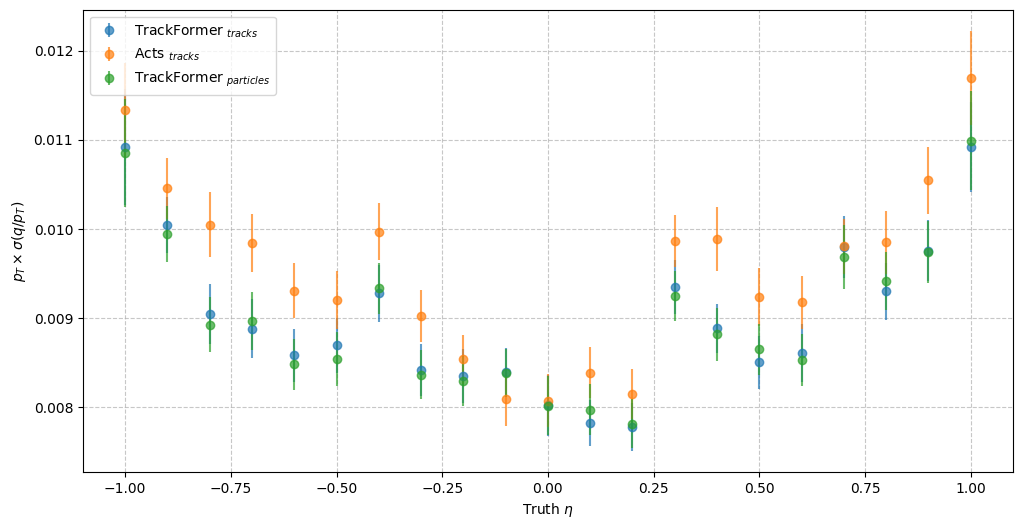

In [75]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name in model_data_bins:
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_stds = model_data[:, 1]
    bin_pi_true_values = model_data[:, 3]
    bin_stds_err = model_data[:, 5]
    
    if model_name == "MSE":
        model_name = "TrackFormer"
        model_name = model_name + " $_{{tracks}}$"
    if model_name == "ACTS_Tracks":
        model_name = "Acts"
        model_name = model_name + " $_{{tracks}}$"
    if model_name == "MSE_particles_truth":
        model_name = "TrackFormer"
        model_name = model_name + " $_{{particles}}$"

    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(6e-3, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta_particles.png", format="png", bbox_inches="tight"
)
plt.show()

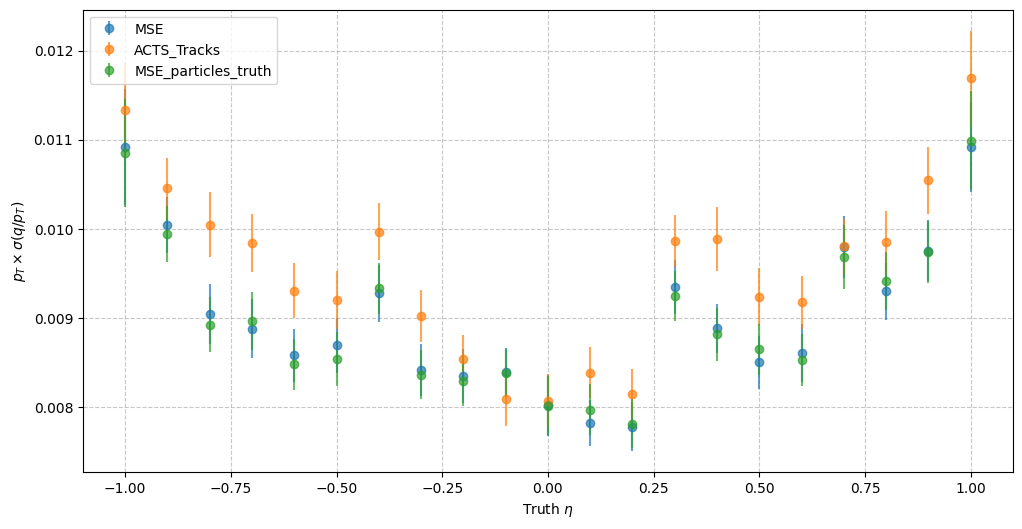

In [ ]:
# # Make the plot
# plt.figure(figsize=(12, 6))
# # plt.suptitle("Relative Error vs peta", fontsize=16)
# # Plot the data
# for model_name in model_data_bins:
#     # Get the data for this model
#     model_data = model_data_bins[model_name]
#     # Convert to numpy arrays
#     model_data = np.array(model_data)
#     # Get the means and stds
#     bin_stds = model_data[:, 1]
#     bin_pi_true_values = model_data[:, 3]
#     bin_stds_err = model_data[:, 5]
    
#     plt.errorbar(
#         bin_centers,
#         bin_stds*bin_pi_true_values,
#         yerr=bin_stds_err*bin_pi_true_values,
#         label=model_name,
#         alpha=0.7,
#         fmt="o",
#     )

# plt.legend()
# # plt.title("Relative Error vs peta")
# # plt.yscale("log")
# plt.xscale("linear")
# plt.xlabel(r"Truth $\eta$")
# plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
# plt.grid(True, linestyle="--", alpha=0.7)
# # plt.ylim(6e-3, 1)
# plt.savefig(
#     output_dir / "relative_error_vs_peta_particles.png", format="png", bbox_inches="tight"
# )
# plt.show()

In [ ]:
print(all_events_particles.shape)
print(all_events_particles_list[0].shape)

(244733, 19)
(3059, 17)


# Previous approach:

In [77]:
from copy import deepcopy
dataset_wrapper.test_dataset.truth_tracks = True
for i in range(len(dataset_wrapper.test_dataset.available_events)):
    event = dataset_wrapper.test_dataset.available_events[i]
    print(f"{event = }")
    # print(f"Loading event {event}")
    event_files = dataset_wrapper.test_dataset._load_event(event)
    processed_event = dataset_wrapper.test_dataset._preprocess_groups(event_files=deepcopy(event_files))
    # processed_event = dataset_wrapper.test_dataset._preprocess_groups(event_files=deepcopy(event_files))
    # print(f"{list(processed_event) = }")
    hits, _, particles = event_files
    # Add Hit_ID to the hits dataframe (index)
    hits["hit_id"] = hits.index
    # Save number of hits
    number_of_hits = len(hits)

    # Add pT and p columns to the particles dataframe
    particles["pT"] = np.sqrt(particles["px"]**2 + particles["py"]**2)
    particles["p"] = np.sqrt(particles["px"]**2 + particles["py"]**2 + particles["pz"]**2)
    # Add eta column to the particles dataframe
    # Use np.arctanh to compute eta from pz and p
    # eta = 0.5 * np.log((1 + pz / p) / (1 - pz / p))
    # or equivalently
    # eta = np.arctanh(pz / p)
    particles["eta"] = np.arctanh(particles["pz"] / particles["p"])
    
    # Add "_truth" suffix to the columns of the particles dataframe
    particles = particles.rename(columns=lambda x: f"{x}_truth" if x not in ["particle_id", "particle_type", "process"] else x)
    # Count the number of hits per particle
    hit_particle_counts = hits.groupby("particle_id").size().to_frame(name="n_particle_hits")
    # This must be an integer
    assert hit_particle_counts["n_particle_hits"].dtype == "int64", f"n_particle_hits is not an integer, it is {hit_particle_counts['n_particle_hits'].dtype}"
    # Add index as a column
    hit_particle_counts = hit_particle_counts.reset_index()
    # Merge the hit counts with the particles dataframe
    particles = particles.merge(hit_particle_counts, on="particle_id", how="left")
    # print(f"{particles.columns = }")
    

    # processed_event = list(processed_event)

    # Add the event number to the tracks and hits dataframes
    particles["event"] = event
    hits["event"] = event

    # Remove the tracks with less than config["min_hits"] hits
    particles = particles[particles["n_particle_hits"] >= config["min_hits"]]

    # Keep only the particles that are in the specified particle types
    particle_types = config["particle_types"]
    particles = particles[particles["particle_type"].isin(particle_types)]

    # Merge with hits dataframe
    hits = pd.merge(
        hits,
        particles,
        on=["event", "particle_id"],
        # how="left",
        how="inner",  # Use inner join to keep only hits with particles
        validate="many_to_one",
    )
    # print(f"{hits.columns = }")
    # print(f"{len(hits) = }")
    # Make sure there is no NaN in the tx, ty, tz columns of the hits dataframe
    assert hits["tx"].notna().all(), "There are NaN values in the tx column of the hits dataframe"
    assert hits["ty"].notna().all(), "There are NaN values in the ty column of the hits dataframe"
    assert hits["tz"].notna().all(), "There are NaN values in the tz column of the hits dataframe"
    # Count the number of duplicates in the hits dataframe
    duplicates = hits.duplicated(subset=["hit_id"], keep='first')
    n_duplicates = duplicates.sum()
    if n_duplicates > 0:
        print(f"Warning: There are {n_duplicates} duplicates in the hits dataframe for event {event}")
        # Print the duplicates
        all_duplicates = hits.duplicated(subset=["hit_id"], keep=False)
        duplicates_hits = hits[all_duplicates]
        # Print the duplicates grouped by hit_id
        duplicates_grouped = duplicates_hits.groupby("hit_id")
        # Show ["hit_id", "particle_id", "particle_id_track", "track_id"] for each group
        # Set the index to hit_id
        duplicates_summary = duplicates_grouped[["particle_id", "particle_id_track", "track_id"]].apply(lambda x: x)
        # Print the summary
        # print(duplicates_summary)
        
        print(f"Number of duplicates: {n_duplicates}")

    # Compare the number of tracks with the size of the processed event
    # assert len(tracks) == len(processed_event), f"Number of tracks ({len(tracks)}) does not match the size of the processed event ({len(processed_event)}) for event {event}"
    
    # Reset particles index
    particles = particles.reset_index(drop=True)
    
    processed_event = list(processed_event)

    # # Convert the processed event to arrays (torch tensors to array)
    # print(processed_event)
    # print(len(processed_event))
    # Sum the shapes of the processed event
    processed_event_shapes = [x.shape for x in processed_event]
    # print(f"Processed event shapes: {processed_event_shapes}")
    # Sum the number of hits
    total_hits = sum(x.shape[0] for x in processed_event)
    # print(f"Total number of hits in processed event: {total_hits}")
    # print(hits)
    # print(len(hits["particle_id"].unique()))
    # print(hits.shape)
    hits["tr"] = np.sqrt(hits["tx"] ** 2 + hits["ty"] ** 2)
    hits["tphi"] = np.arctan2(hits["ty"], hits["tx"])
    assert len(processed_event) == len(hits["particle_id"].unique()), f"Processed event length {len(processed_event)} does not match hits unique particle_id length {len(hits['particle_id'].unique())}"
    assert len(processed_event) == particles.shape[0]
    assert total_hits == hits.shape[0]
    for particle_id, processed_event_particle in zip(particles["particle_id"].unique(), processed_event):
        particle_hits = hits[hits["particle_id"] == particle_id]
        common_columns = set(particle_hits.columns) & set(processed_event_particle.columns)
        common_columns = list(common_columns)
        # print(f"{particle_hits.columns = }")
        particle_hits = particle_hits.sort_values("tr", ascending=True)
        particle_hits = particle_hits.reset_index(drop=True)
        # processed_event_particle = processed_event_particle.sort_values("tr", ascending=True)
        processed_event_particle = processed_event_particle.reset_index(drop=True)
        same = particle_hits[common_columns].equals(processed_event_particle[common_columns])
        if not same:
            print(f"{particle_id = }")
            print(f"{particle_hits}")
            print(f"{processed_event_particle}")
            for columnn in common_columns:
                assert particle_hits[columnn].equals(processed_event_particle[columnn]), f"{columnn = }"
        assert same
    # processed_event = [x.detach().cpu().numpy() for x in processed_event]
    # break


event = 'event000000000'


/home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py:1106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  particles["pT"] = np.sqrt(particles["px"] ** 2 + particles["py"] ** 2)


KeyError: 'event_id'

In [21]:
# Instantiate the DataModule num_workers=16)
# dataset_wrapper = DataModule(dataset_type="tml", dataset_dir="Data/Tml/trackml_100_events_splits") # 20 000 particles
dataset_wrapper = DataModule(
    dataset_type=dataset_type,
    dataset_dir=dataset_dir,
    use_wrapper=False,
    kwargs=config,
    num_workers=0,
)  # 1 404 273 particles

dataset_wrapper.setup(stage="test")
tl = dataset_wrapper.test_dataloader()
# 1 min 41.4 s

────────────────────────────────────────────────── Acts Dataset ───────────────────────────────────────────────────

In [ ]:
from copy import deepcopy
from torch.nn.utils.rnn import pad_sequence

batchs = []
batch = []

p_true_list = []
n_hits_list = []
input_list = []

for model in models:
    models[model]["data_list"] = []

batch_size = 32
batch_limit = 7000
break_loop = False

tl_copy = iter(deepcopy(tl))
dataset_wrapper.test_dataset.truth_tracks = True
for i in range(len(dataset_wrapper.test_dataset.available_events)):
    event = dataset_wrapper.test_dataset.available_events[i]
    print(f"{event = }")
    # print(f"Loading event {event}")
    event_files = dataset_wrapper.test_dataset._load_event(event)
    processed_event = dataset_wrapper.test_dataset._preprocess_groups(event_files=deepcopy(event_files))
    # processed_event = dataset_wrapper.test_dataset._preprocess_groups(event_files=deepcopy(event_files))
    # print(f"{list(processed_event) = }")
    hits, _, particles = event_files
    # Add Hit_ID to the hits dataframe (index)
    hits["hit_id"] = hits.index
    # Save number of hits
    number_of_hits = len(hits)

    # Add pT and p columns to the particles dataframe
    particles["pT"] = np.sqrt(particles["px"]**2 + particles["py"]**2)
    particles["p"] = np.sqrt(particles["px"]**2 + particles["py"]**2 + particles["pz"]**2)
    # Add eta column to the particles dataframe
    # Use np.arctanh to compute eta from pz and p
    # eta = 0.5 * np.log((1 + pz / p) / (1 - pz / p))
    # or equivalently
    # eta = np.arctanh(pz / p)
    particles["eta"] = np.arctanh(particles["pz"] / particles["p"])
    particles["qopT"] = particles["q"] / particles["pT"]

    # Add "_truth" suffix to the columns of the particles dataframe
    particles = particles.rename(columns=lambda x: f"{x}_truth" if x not in ["particle_id", "particle_type", "process"] else x)
    particles["pT"] = particles["pT_truth"]
    particles["p"] = particles["p_truth"]
    particles["eta"] = particles["eta_truth"]
    particles["q"] = particles["q_truth"]
    particles["qopT"] = particles["qopT_truth"]
    particles["pz"] = particles["pz_truth"]
    # Count the number of hits per particle
    hit_particle_counts = hits.groupby("particle_id").size().to_frame(name="n_particle_hits")
    # This must be an integer
    assert hit_particle_counts["n_particle_hits"].dtype == "int64", f"n_particle_hits is not an integer, it is {hit_particle_counts['n_particle_hits'].dtype}"
    # Add index as a column
    hit_particle_counts = hit_particle_counts.reset_index()
    # Merge the hit counts with the particles dataframe
    particles = particles.merge(hit_particle_counts, on="particle_id", how="left")
    # print(f"{particles.columns = }")
    

    # processed_event = list(processed_event)

    # Add the event number to the tracks and hits dataframes
    particles["event"] = event
    hits["event"] = event

    # Remove the tracks with less than config["min_hits"] hits
    particles = particles[particles["n_particle_hits"] >= config["min_hits"]]

    # Keep only the particles that are in the specified particle types
    particle_types = config["particle_types"]
    particles = particles[particles["particle_type"].isin(particle_types)]

    # Merge with hits dataframe
    hits = pd.merge(
        hits,
        particles,
        on=["event", "particle_id"],
        # how="left",
        how="inner",  # Use inner join to keep only hits with particles
        validate="many_to_one",
    )
    # print(f"{hits.columns = }")
    # print(f"{len(hits) = }")
    # Make sure there is no NaN in the tx, ty, tz columns of the hits dataframe
    assert hits["tx"].notna().all(), "There are NaN values in the tx column of the hits dataframe"
    assert hits["ty"].notna().all(), "There are NaN values in the ty column of the hits dataframe"
    assert hits["tz"].notna().all(), "There are NaN values in the tz column of the hits dataframe"
    # Count the number of duplicates in the hits dataframe
    duplicates = hits.duplicated(subset=["hit_id"], keep='first')
    n_duplicates = duplicates.sum()
    if n_duplicates > 0:
        print(f"Warning: There are {n_duplicates} duplicates in the hits dataframe for event {event}")
        # Print the duplicates
        all_duplicates = hits.duplicated(subset=["hit_id"], keep=False)
        duplicates_hits = hits[all_duplicates]
        # Print the duplicates grouped by hit_id
        duplicates_grouped = duplicates_hits.groupby("hit_id")
        # Show ["hit_id", "particle_id", "particle_id_track", "track_id"] for each group
        # Set the index to hit_id
        duplicates_summary = duplicates_grouped[["particle_id", "particle_id_track", "track_id"]].apply(lambda x: x)
        # Print the summary
        # print(duplicates_summary)
        
        print(f"Number of duplicates: {n_duplicates}")

    # Compare the number of tracks with the size of the processed event
    # assert len(tracks) == len(processed_event), f"Number of tracks ({len(tracks)}) does not match the size of the processed event ({len(processed_event)}) for event {event}"
    
    # Reset particles index
    particles = particles.reset_index(drop=True)
    
    processed_event = list(processed_event)

    # # Convert the processed event to arrays (torch tensors to array)
    # print(processed_event)
    # print(len(processed_event))
    # Sum the shapes of the processed event
    processed_event_shapes = [x.shape for x in processed_event]
    # print(f"Processed event shapes: {processed_event_shapes}")
    # Sum the number of hits
    total_hits = sum(x.shape[0] for x in processed_event)
    # print(f"Total number of hits in processed event: {total_hits}")
    # print(hits)
    # print(len(hits["particle_id"].unique()))
    # print(hits.shape)
    hits["tr"] = np.sqrt(hits["tx"] ** 2 + hits["ty"] ** 2)
    hits["tphi"] = np.arctan2(hits["ty"], hits["tx"])
    assert len(processed_event) == len(hits["particle_id"].unique()), f"Processed event length {len(processed_event)} does not match hits unique particle_id length {len(hits['particle_id'].unique())}"
    assert len(processed_event) == particles.shape[0]
    assert total_hits == hits.shape[0]
    for particle_id, processed_event_particle in zip(particles["particle_id"], processed_event):
        particle_hits = hits[hits["particle_id"] == particle_id]
        particle_hits = particle_hits.sort_values("tr", ascending=True)
        particle_hits = particle_hits.reset_index(drop=True)
        # processed_event_particle = processed_event_particle.sort_values("tr", ascending=True)
        processed_event_particle = processed_event_particle.reset_index(drop=True)
        particle_hits["dphi"] = particle_hits["tphi"] - particle_hits["tphi"].iloc[0]
        # Correct for periodicity
        particle_hits["dphi"] = np.where(
            particle_hits["dphi"] > np.pi, particle_hits["dphi"] - 2 * np.pi, particle_hits["dphi"]
        )
        particle_hits["dphi"] = np.where(
            particle_hits["dphi"] < -np.pi, particle_hits["dphi"] + 2 * np.pi, particle_hits["dphi"]
        )
        common_columns = set(particle_hits.columns) & set(processed_event_particle.columns)
        common_columns = list(common_columns)
        # print(f"{particle_hits.columns = }")
        same = particle_hits[common_columns].equals(processed_event_particle[common_columns])
        if not same:
            print(f"{particle_id = }")
            print(f"{particle_hits}")
            print(f"{processed_event_particle}")
            for columnn in common_columns:
                assert particle_hits[columnn].equals(processed_event_particle[columnn]), f"{columnn = }"
        assert same

        inputs = particle_hits[dataset_wrapper.test_dataset.input_variables].values
        target = particle_hits[dataset_wrapper.test_dataset.output_variables].values[0]

        input = torch.tensor(inputs, dtype=torch.float32)
        target = torch.tensor(target, dtype=torch.float32)

        mask = torch.ones(input.shape[0], dtype=torch.bool)
        batch.append((input, mask, target))
        if len(batch) % batch_size == 0:
            # Pad the batch
            input_tensor = pad_sequence([x[0] for x in batch], batch_first=True)
            mask_tensor = pad_sequence([x[1] for x in batch], batch_first=True, padding_value=0)
            target_tensor = torch.stack([x[2] for x in batch], dim=0)
            # Add to the list
            batchs.append((input_tensor, mask_tensor, target_tensor))
            # Clear the batch
            batch = []
            # Compare with the one from the test dataset
            dataset_input, dataset_mask, dataset_target = next(tl_copy)
            same_input = torch.all(input_tensor == dataset_input)
            same_mask = torch.all(mask_tensor == dataset_mask)
            same_target = torch.all(target_tensor == dataset_target)
            if not same_input or not same_mask or not same_target:
                print(f"Mismatch in event {event} at index {i}")
                print(f"Batch size: {len(batch)}")
                print(f"{dataset_input.shape = }")
                print(f"{input_tensor.shape = }")
                print(f"{dataset_mask.shape = }")
                print(f"{mask_tensor.shape = }")
                print(f"{dataset_target.shape = }")
                print(f"{target_tensor = }")
                print(f"{dataset_target = }")
            assert torch.all(input_tensor == dataset_input), f"Input tensors do not match for event {event} at index {i}"
            assert torch.all(mask_tensor == dataset_mask), f"Mask tensors do not match for event {event} at index {i}"
            assert torch.all(target_tensor == dataset_target), f"Target tensors do not match for event {event} at index {i}"
            if len(batchs) % 50 == 0:
                print(f"Batchs: {len(batchs)}")
            if len(batchs) >= batch_limit:
                print(f"Batch limit reached: {len(batchs)}")
                break_loop = True
                break
        if break_loop:
            break
    if break_loop:
        break
# with torch.no_grad():
#     for i, (input, mask, target) in enumerate(tqdm(tl)):
#         if dataset_name == "Acts_muons" and i >= 7000:
#         # if dataset_name == "Acts_muons" and i > 5000:
#             break

#         # Transformers
#         p_true = target
#         p_true_list.extend(p_true.tolist())
#         n_hits_list.extend(mask.sum(dim=1).tolist())
#         input_list.extend(input.tolist())

#         for model in models:
#             ml_model = models[model]["model"]
#             p_pred_model = ml_model(input, mask=mask)
#             models[model]["data_list"].extend(p_pred_model.tolist())
#         yield zxy, mask, target_tensor
#     # processed_event = [x.detach().cpu().numpy() for x in processed_event]
#     # break


event = 'event000000000'


[11:37:24] Warning: 1 particles do not have corresponding hits.                                  ]8;id=40994;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=781924;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#748\748]8;;\

           Particle ids: [3526318508298207232]                                                   ]8;id=934457;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=662041;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#752\752]8;;\

[11:37:29] Warning: 1 particles do not have corresponding hits.                                  ]8;id=852447;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=972060;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#748\748]8;;\

           Particle ids: [3526318508298207232]                                                   ]8;id=431697;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=122347;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#752\752]8;;\

Batchs: 50
Batchs: 100
event = 'event000000001'
Batchs: 150
Batchs: 200
event = 'event000000002'
Batchs: 250
Batchs: 300
Batchs: 350
event = 'event000000003'
Batchs: 400
Batchs: 450
event = 'event000000004'
Batchs: 500
Batchs: 550
Batchs: 600
event = 'event000000005'
Batchs: 650
Batchs: 700
event = 'event000000006'
Batchs: 750
Batchs: 800
Batchs: 850
event = 'event000000007'
Batchs: 900
Batchs: 950
event = 'event000000008'
Batchs: 1000
Batchs: 1050
Batchs: 1100
event = 'event000000009'
Batchs: 1150


KeyboardInterrupt: 

In [45]:
from copy import deepcopy
from torch.nn.utils.rnn import pad_sequence

batchs = []
batch = []

p_true_list = []
n_hits_list = []
input_list = []

for model in models:
    models[model]["data_list"] = []

all_inputs = []
all_targets = []
all_input_masks = []

batch_size = 32
batch_limit = 7000
break_loop = False

tl_copy = iter(deepcopy(tl))
dataset_wrapper.test_dataset.truth_tracks = True
for i in range(len(dataset_wrapper.test_dataset.available_events)):
    event = dataset_wrapper.test_dataset.available_events[i]
    print(f"{event = }")
    # print(f"Loading event {event}")
    event_files = dataset_wrapper.test_dataset._load_event(event)
    processed_event = dataset_wrapper.test_dataset._preprocess_groups(event_files=deepcopy(event_files))
    # processed_event = dataset_wrapper.test_dataset._preprocess_groups(event_files=deepcopy(event_files))
    # print(f"{list(processed_event) = }")
    hits, _, particles = event_files
    # Add Hit_ID to the hits dataframe (index)
    hits["hit_id"] = hits.index
    # Save number of hits
    number_of_hits = len(hits)

    # Add pT and p columns to the particles dataframe
    particles["pT"] = np.sqrt(particles["px"]**2 + particles["py"]**2)
    particles["p"] = np.sqrt(particles["px"]**2 + particles["py"]**2 + particles["pz"]**2)
    # Add eta column to the particles dataframe
    # Use np.arctanh to compute eta from pz and p
    # eta = 0.5 * np.log((1 + pz / p) / (1 - pz / p))
    # or equivalently
    # eta = np.arctanh(pz / p)
    particles["eta"] = np.arctanh(particles["pz"] / particles["p"])
    particles["qopT"] = particles["q"] / particles["pT"]

    # Add "_truth" suffix to the columns of the particles dataframe
    particles = particles.rename(columns=lambda x: f"{x}_truth" if x not in ["particle_id", "particle_type", "process"] else x)
    particles["pT"] = particles["pT_truth"]
    particles["p"] = particles["p_truth"]
    particles["eta"] = particles["eta_truth"]
    particles["q"] = particles["q_truth"]
    particles["qopT"] = particles["qopT_truth"]
    particles["pz"] = particles["pz_truth"]
    # Count the number of hits per particle
    hit_particle_counts = hits.groupby("particle_id").size().to_frame(name="n_particle_hits")
    # This must be an integer
    assert hit_particle_counts["n_particle_hits"].dtype == "int64", f"n_particle_hits is not an integer, it is {hit_particle_counts['n_particle_hits'].dtype}"
    # Add index as a column
    hit_particle_counts = hit_particle_counts.reset_index()
    # Merge the hit counts with the particles dataframe
    particles = particles.merge(hit_particle_counts, on="particle_id", how="left")
    # print(f"{particles.columns = }")
    

    # processed_event = list(processed_event)

    # Add the event number to the tracks and hits dataframes
    particles["event"] = event
    hits["event"] = event

    # Remove the tracks with less than config["min_hits"] hits
    particles = particles[particles["n_particle_hits"] >= config["min_hits"]]

    # Keep only the particles that are in the specified particle types
    particle_types = config["particle_types"]
    particles = particles[particles["particle_type"].isin(particle_types)]

    # Merge with hits dataframe
    hits = pd.merge(
        hits,
        particles,
        on=["event", "particle_id"],
        # how="left",
        how="inner",  # Use inner join to keep only hits with particles
        validate="many_to_one",
    )
    # print(f"{hits.columns = }")
    # print(f"{len(hits) = }")
    # Make sure there is no NaN in the tx, ty, tz columns of the hits dataframe
    assert hits["tx"].notna().all(), "There are NaN values in the tx column of the hits dataframe"
    assert hits["ty"].notna().all(), "There are NaN values in the ty column of the hits dataframe"
    assert hits["tz"].notna().all(), "There are NaN values in the tz column of the hits dataframe"
    # Count the number of duplicates in the hits dataframe
    duplicates = hits.duplicated(subset=["hit_id"], keep='first')
    n_duplicates = duplicates.sum()
    if n_duplicates > 0:
        print(f"Warning: There are {n_duplicates} duplicates in the hits dataframe for event {event}")
        # Print the duplicates
        all_duplicates = hits.duplicated(subset=["hit_id"], keep=False)
        duplicates_hits = hits[all_duplicates]
        # Print the duplicates grouped by hit_id
        duplicates_grouped = duplicates_hits.groupby("hit_id")
        # Show ["hit_id", "particle_id", "particle_id_track", "track_id"] for each group
        # Set the index to hit_id
        duplicates_summary = duplicates_grouped[["particle_id", "particle_id_track", "track_id"]].apply(lambda x: x)
        # Print the summary
        # print(duplicates_summary)
        
        print(f"Number of duplicates: {n_duplicates}")

    # Compare the number of tracks with the size of the processed event
    # assert len(tracks) == len(processed_event), f"Number of tracks ({len(tracks)}) does not match the size of the processed event ({len(processed_event)}) for event {event}"
    
    # Reset particles index
    particles = particles.reset_index(drop=True)
    
    processed_event = list(processed_event)

    # # Convert the processed event to arrays (torch tensors to array)
    # print(processed_event)
    # print(len(processed_event))
    # Sum the shapes of the processed event
    processed_event_shapes = [x.shape for x in processed_event]
    # print(f"Processed event shapes: {processed_event_shapes}")
    # Sum the number of hits
    total_hits = sum(x.shape[0] for x in processed_event)
    # print(f"Total number of hits in processed event: {total_hits}")
    # print(hits)
    # print(len(hits["particle_id"].unique()))
    # print(hits.shape)
    hits["tr"] = np.sqrt(hits["tx"] ** 2 + hits["ty"] ** 2)
    hits["tphi"] = np.arctan2(hits["ty"], hits["tx"])
    assert len(processed_event) == len(hits["particle_id"].unique()), f"Processed event length {len(processed_event)} does not match hits unique particle_id length {len(hits['particle_id'].unique())}"
    assert len(processed_event) == particles.shape[0]
    assert total_hits == hits.shape[0]
    for particle_id, processed_event_particle in zip(particles["particle_id"], processed_event):
        particle_hits = hits[hits["particle_id"] == particle_id]
        particle_hits = particle_hits.sort_values("tr", ascending=True)
        particle_hits = particle_hits.reset_index(drop=True)
        # processed_event_particle = processed_event_particle.sort_values("tr", ascending=True)
        processed_event_particle = processed_event_particle.reset_index(drop=True)
        particle_hits["dphi"] = particle_hits["tphi"] - particle_hits["tphi"].iloc[0]
        # Correct for periodicity
        particle_hits["dphi"] = np.where(
            particle_hits["dphi"] > np.pi, particle_hits["dphi"] - 2 * np.pi, particle_hits["dphi"]
        )
        particle_hits["dphi"] = np.where(
            particle_hits["dphi"] < -np.pi, particle_hits["dphi"] + 2 * np.pi, particle_hits["dphi"]
        )
        common_columns = set(particle_hits.columns) & set(processed_event_particle.columns)
        common_columns = list(common_columns)
        # print(f"{particle_hits.columns = }")
        same = particle_hits[common_columns].equals(processed_event_particle[common_columns])
        if not same:
            print(f"{particle_id = }")
            print(f"{particle_hits}")
            print(f"{processed_event_particle}")
            for columnn in common_columns:
                assert particle_hits[columnn].equals(processed_event_particle[columnn]), f"{columnn = }"
        assert same

        inputs = particle_hits[dataset_wrapper.test_dataset.input_variables].values
        target = particle_hits[dataset_wrapper.test_dataset.output_variables].values[0]

        input = torch.tensor(inputs, dtype=torch.float32)
        target = torch.tensor(target, dtype=torch.float32)

        mask = torch.ones(input.shape[0], dtype=torch.bool)
        batch.append((input, mask, target))
        if len(batch) % batch_size == 0:
            # Pad the batch
            input_tensor = pad_sequence([x[0] for x in batch], batch_first=True)
            mask_tensor = pad_sequence([x[1] for x in batch], batch_first=True, padding_value=0)
            target_tensor = torch.stack([x[2] for x in batch], dim=0)
            # Add to the list
            batchs.append((input_tensor, mask_tensor, target_tensor))
            # Clear the batch
            batch = []
            # Compare with the one from the test dataset
            dataset_input, dataset_mask, dataset_target = next(tl_copy)
            same_input = torch.all(input_tensor == dataset_input)
            same_mask = torch.all(mask_tensor == dataset_mask)
            same_target = torch.all(target_tensor == dataset_target)
            if not same_input or not same_mask or not same_target:
                print(f"Mismatch in event {event} at index {i}")
                print(f"Batch size: {len(batch)}")
                print(f"{dataset_input.shape = }")
                print(f"{input_tensor.shape = }")
                print(f"{dataset_mask.shape = }")
                print(f"{mask_tensor.shape = }")
                print(f"{dataset_target.shape = }")
                print(f"{target_tensor = }")
                print(f"{dataset_target = }")
            assert torch.all(input_tensor == dataset_input), f"Input tensors do not match for event {event} at index {i}"
            assert torch.all(mask_tensor == dataset_mask), f"Mask tensors do not match for event {event} at index {i}"
            assert torch.all(target_tensor == dataset_target), f"Target tensors do not match for event {event} at index {i}"
            with torch.no_grad():
                input = input_tensor
                mask = mask_tensor
                target = target_tensor

                # Transformers
                p_true = target
                p_true_list.extend(p_true.tolist())
                n_hits_list.extend(mask.sum(dim=1).tolist())
                input_list.extend(input.tolist())

                for model in models:
                    ml_model = models[model]["model"]
                    p_pred_model = ml_model(input, mask=mask)
                    models[model]["data_list"].extend(p_pred_model.tolist())

            # Reshape the input and target to shape (n_features, batch_size, seq_len)
            input = input.permute(2, 0, 1)
            target = target.permute(1, 0)

            all_inputs.append(input)
            all_targets.append(target)
            all_input_masks.append(mask)
                
            if len(batchs) % 50 == 0:
                print(f"Batchs: {len(batchs)}")
            if len(batchs) >= batch_limit:
                print(f"Batch limit reached: {len(batchs)}")
                break_loop = True
                break
        if break_loop:
            break
    if break_loop:
        break


event = 'event000000000'


[12:14:04] Warning: 1 particles do not have corresponding hits.                                  ]8;id=211375;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=990810;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#748\748]8;;\

           Particle ids: [3526318508298207232]                                                   ]8;id=11016;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=673913;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#752\752]8;;\

[12:14:09] Warning: 1 particles do not have corresponding hits.                                  ]8;id=271317;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=140172;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#748\748]8;;\

           Particle ids: [3526318508298207232]                                                   ]8;id=823117;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=598052;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#752\752]8;;\

...

[12:23:56] Warning: 1 particles do not have corresponding hits.                                  ]8;id=814907;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=476070;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#748\748]8;;\

[12:23:57] Particle ids: [2517512191767347273]                                                   ]8;id=59250;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=871072;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#752\752]8;;\

[12:24:00] Warning: 1 particles do not have corresponding hits.                                  ]8;id=160835;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=860610;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#748\748]8;;\

           Particle ids: [2517512191767347273]                                                   ]8;id=234534;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=457043;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#752\752]8;;\

Batchs: 3150
Batchs: 3200
event = 'event000000026'
Batchs: 3250
Batchs: 3300
Batchs: 3350
event = 'event000000027'
Batchs: 3400
Batchs: 3450
event = 'event000000028'
Batchs: 3500
Batchs: 3550
Batchs: 3600
event = 'event000000029'
Batchs: 3650
Batchs: 3700
event = 'event000000030'
Batchs: 3750
Batchs: 3800
Batchs: 3850
event = 'event000000031'
Batchs: 3900
Batchs: 3950
event = 'event000000032'
Batchs: 4000
Batchs: 4050
Batchs: 4100
event = 'event000000033'
Batchs: 4150
Batchs: 4200
event = 'event000000034'
Batchs: 4250
Batchs: 4300
Batchs: 4350
event = 'event000000035'
Batchs: 4400
Batchs: 4450
event = 'event000000036'
Batchs: 4500
Batchs: 4550
Batchs: 4600
event = 'event000000037'
Batchs: 4650
Batchs: 4700
event = 'event000000038'
Batchs: 4750
Batchs: 4800
Batchs: 4850
event = 'event000000039'
Batchs: 4900
Batchs: 4950
event = 'event000000040'
Batchs: 5000
Batchs: 5050
Batchs: 5100
event = 'event000000041'
Batchs: 5150
Batchs: 5200
event = 'event000000042'
Batchs: 5250
Batchs: 5300
Bat

In [22]:
from copy import deepcopy
from torch.nn.utils.rnn import pad_sequence

batchs = []
batch = []

p_true_list = []
n_hits_list = []
input_list = []

for model in models:
    models[model]["data_list"] = []

all_inputs = []
all_targets = []
all_input_masks = []

all_events_particles_list = []
all_events_processed = []
all_hits_list = []

batch_size = 32
batch_limit = 7000
batch_limit = 3000
break_loop = False

tl_copy = iter(deepcopy(tl))
dataset_wrapper.test_dataset.truth_tracks = True
for i in range(len(dataset_wrapper.test_dataset.available_events)):
    event = dataset_wrapper.test_dataset.available_events[i]
    print(f"{event = }")
    # print(f"Loading event {event}")
    event_files = dataset_wrapper.test_dataset._load_event(event)
    processed_event = dataset_wrapper.test_dataset._preprocess_groups(event_files=deepcopy(event_files))
    # processed_event = dataset_wrapper.test_dataset._preprocess_groups(event_files=deepcopy(event_files))
    # print(f"{list(processed_event) = }")
    hits, _, particles = event_files
    # Add Hit_ID to the hits dataframe (index)
    hits["hit_id"] = hits.index
    # Save number of hits
    number_of_hits = len(hits)

    # Add pT and p columns to the particles dataframe
    particles["pT"] = np.sqrt(particles["px"]**2 + particles["py"]**2)
    particles["p"] = np.sqrt(particles["px"]**2 + particles["py"]**2 + particles["pz"]**2)
    # Add eta column to the particles dataframe
    # Use np.arctanh to compute eta from pz and p
    # eta = 0.5 * np.log((1 + pz / p) / (1 - pz / p))
    # or equivalently
    # eta = np.arctanh(pz / p)
    particles["eta"] = np.arctanh(particles["pz"] / particles["p"])
    particles["qopT"] = particles["q"] / particles["pT"]

    # Add "_truth" suffix to the columns of the particles dataframe
    particles = particles.rename(columns=lambda x: f"{x}_truth" if x not in ["particle_id", "particle_type", "process"] else x)
    particles["pT"] = particles["pT_truth"]
    particles["p"] = particles["p_truth"]
    particles["eta"] = particles["eta_truth"]
    particles["q"] = particles["q_truth"]
    particles["qopT"] = particles["qopT_truth"]
    particles["pz"] = particles["pz_truth"]
    # Count the number of hits per particle
    hit_particle_counts = hits.groupby("particle_id").size().to_frame(name="n_particle_hits")
    # This must be an integer
    assert hit_particle_counts["n_particle_hits"].dtype == "int64", f"n_particle_hits is not an integer, it is {hit_particle_counts['n_particle_hits'].dtype}"
    # Add index as a column
    hit_particle_counts = hit_particle_counts.reset_index()
    # Merge the hit counts with the particles dataframe
    particles = particles.merge(hit_particle_counts, on="particle_id", how="left")
    # print(f"{particles.columns = }")
    

    # processed_event = list(processed_event)

    # Add the event number to the tracks and hits dataframes
    particles["event"] = event
    hits["event"] = event

    # Remove the tracks with less than config["min_hits"] hits
    particles = particles[particles["n_particle_hits"] >= config["min_hits"]]

    # Keep only the particles that are in the specified particle types
    particle_types = config["particle_types"]
    particles = particles[particles["particle_type"].isin(particle_types)]

    # Merge with hits dataframe
    hits = pd.merge(
        hits,
        particles,
        on=["event", "particle_id"],
        # how="left",
        how="inner",  # Use inner join to keep only hits with particles
        validate="many_to_one",
    )
    # print(f"{hits.columns = }")
    # print(f"{len(hits) = }")
    # Make sure there is no NaN in the tx, ty, tz columns of the hits dataframe
    assert hits["tx"].notna().all(), "There are NaN values in the tx column of the hits dataframe"
    assert hits["ty"].notna().all(), "There are NaN values in the ty column of the hits dataframe"
    assert hits["tz"].notna().all(), "There are NaN values in the tz column of the hits dataframe"
    # Count the number of duplicates in the hits dataframe
    duplicates = hits.duplicated(subset=["hit_id"], keep='first')
    n_duplicates = duplicates.sum()
    if n_duplicates > 0:
        print(f"Warning: There are {n_duplicates} duplicates in the hits dataframe for event {event}")
        # Print the duplicates
        all_duplicates = hits.duplicated(subset=["hit_id"], keep=False)
        duplicates_hits = hits[all_duplicates]
        # Print the duplicates grouped by hit_id
        duplicates_grouped = duplicates_hits.groupby("hit_id")
        # Show ["hit_id", "particle_id", "particle_id_track", "track_id"] for each group
        # Set the index to hit_id
        duplicates_summary = duplicates_grouped[["particle_id", "particle_id_track", "track_id"]].apply(lambda x: x)
        # Print the summary
        # print(duplicates_summary)
        
        print(f"Number of duplicates: {n_duplicates}")

    # Compare the number of tracks with the size of the processed event
    # assert len(tracks) == len(processed_event), f"Number of tracks ({len(tracks)}) does not match the size of the processed event ({len(processed_event)}) for event {event}"
    
    # Reset particles index
    particles = particles.reset_index(drop=True)
    
    processed_event = list(processed_event)

    # # Convert the processed event to arrays (torch tensors to array)
    # print(processed_event)
    # print(len(processed_event))
    # Sum the shapes of the processed event
    processed_event_shapes = [x.shape for x in processed_event]
    # print(f"Processed event shapes: {processed_event_shapes}")
    # Sum the number of hits
    total_hits = sum(x.shape[0] for x in processed_event)
    # print(f"Total number of hits in processed event: {total_hits}")
    # print(hits)
    # print(len(hits["particle_id"].unique()))
    # print(hits.shape)
    hits["tr"] = np.sqrt(hits["tx"] ** 2 + hits["ty"] ** 2)
    hits["tphi"] = np.arctan2(hits["ty"], hits["tx"])
    assert len(processed_event) == len(hits["particle_id"].unique()), f"Processed event length {len(processed_event)} does not match hits unique particle_id length {len(hits['particle_id'].unique())}"
    assert len(processed_event) == particles.shape[0]
    assert total_hits == hits.shape[0]
    for particle_id, processed_event_particle in zip(particles["particle_id"], processed_event):
        all_events_particles_list.append(particles[particles["particle_id"] == particle_id])
        particle_hits = hits[hits["particle_id"] == particle_id]
        particle_hits = particle_hits.sort_values("tr", ascending=True)
        particle_hits = particle_hits.reset_index(drop=True)
        # processed_event_particle = processed_event_particle.sort_values("tr", ascending=True)
        processed_event_particle = processed_event_particle.reset_index(drop=True)
        particle_hits["dphi"] = particle_hits["tphi"] - particle_hits["tphi"].iloc[0]
        # Correct for periodicity
        particle_hits["dphi"] = np.where(
            particle_hits["dphi"] > np.pi, particle_hits["dphi"] - 2 * np.pi, particle_hits["dphi"]
        )
        particle_hits["dphi"] = np.where(
            particle_hits["dphi"] < -np.pi, particle_hits["dphi"] + 2 * np.pi, particle_hits["dphi"]
        )
        common_columns = set(particle_hits.columns) & set(processed_event_particle.columns)
        common_columns = list(common_columns)
        # print(f"{particle_hits.columns = }")
        same = particle_hits[common_columns].equals(processed_event_particle[common_columns])
        if not same:
            print(f"{particle_id = }")
            print(f"{particle_hits}")
            print(f"{processed_event_particle}")
            for columnn in common_columns:
                assert particle_hits[columnn].equals(processed_event_particle[columnn]), f"{columnn = }"
        assert same

        inputs = particle_hits[dataset_wrapper.test_dataset.input_variables].values
        target = particle_hits[dataset_wrapper.test_dataset.output_variables].values[0]

        input = torch.tensor(inputs, dtype=torch.float32)
        target = torch.tensor(target, dtype=torch.float32)

        mask = torch.ones(input.shape[0], dtype=torch.bool)
        batch.append((input, mask, target))
        if len(batch) % batch_size == 0:
            # Pad the batch
            input_tensor = pad_sequence([x[0] for x in batch], batch_first=True)
            mask_tensor = pad_sequence([x[1] for x in batch], batch_first=True, padding_value=0)
            target_tensor = torch.stack([x[2] for x in batch], dim=0)
            # Add to the list
            batchs.append((input_tensor, mask_tensor, target_tensor))
            # Clear the batch
            batch = []
            # Compare with the one from the test dataset
            dataset_input, dataset_mask, dataset_target = next(tl_copy)
            same_input = torch.all(input_tensor == dataset_input)
            same_mask = torch.all(mask_tensor == dataset_mask)
            same_target = torch.all(target_tensor == dataset_target)
            if not same_input or not same_mask or not same_target:
                print(f"Mismatch in event {event} at index {i}")
                print(f"Batch size: {len(batch)}")
                print(f"{dataset_input.shape = }")
                print(f"{input_tensor.shape = }")
                print(f"{dataset_mask.shape = }")
                print(f"{mask_tensor.shape = }")
                print(f"{dataset_target.shape = }")
                print(f"{target_tensor = }")
                print(f"{dataset_target = }")
            assert torch.all(input_tensor == dataset_input), f"Input tensors do not match for event {event} at index {i}"
            assert torch.all(mask_tensor == dataset_mask), f"Mask tensors do not match for event {event} at index {i}"
            assert torch.all(target_tensor == dataset_target), f"Target tensors do not match for event {event} at index {i}"
            with torch.no_grad():
                input = input_tensor
                mask = mask_tensor
                target = target_tensor

                # Transformers
                p_true = target
                p_true_list.extend(p_true.tolist())
                n_hits_list.extend(mask.sum(dim=1).tolist())
                input_list.extend(input.tolist())

                for model in models:
                    ml_model = models[model]["model"]
                    p_pred_model = ml_model(input, mask=mask)
                    models[model]["data_list"].extend(p_pred_model.tolist())

            # Reshape the input and target to shape (n_features, batch_size, seq_len)
            input = input.permute(2, 0, 1)
            target = target.permute(1, 0)

            all_inputs.append(input)
            all_targets.append(target)
            all_input_masks.append(mask)
                
            if len(batchs) % 50 == 0:
                print(f"Batchs: {len(batchs)}")
            if len(batchs) >= batch_limit:
                print(f"Batch limit reached: {len(batchs)}")
                break_loop = True
                break
        if break_loop:
            break
    if break_loop:
        break

all_events_particles = pd.concat(all_events_particles_list, ignore_index=True)


event = 'event000000000'


[18:21:22] Warning: 1 particles do not have corresponding hits.                                  ]8;id=921302;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=205916;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#748\748]8;;\

           Particle ids: [3526318508298207232]                                                   ]8;id=88337;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=646195;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#752\752]8;;\

[18:21:28] Warning: 1 particles do not have corresponding hits.                                  ]8;id=984153;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=457630;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#748\748]8;;\

           Particle ids: [3526318508298207232]                                                   ]8;id=440565;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=448977;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#752\752]8;;\

Batchs: 50
Batchs: 100
event = 'event000000001'
Batchs: 150
Batchs: 200
event = 'event000000002'
Batchs: 250
Batchs: 300
Batchs: 350
event = 'event000000003'
Batchs: 400
Batchs: 450
event = 'event000000004'
Batchs: 500
Batchs: 550
Batchs: 600
event = 'event000000005'
Batchs: 650
Batchs: 700
event = 'event000000006'
Batchs: 750
Batchs: 800
Batchs: 850
event = 'event000000007'
Batchs: 900
Batchs: 950
event = 'event000000008'
Batchs: 1000
Batchs: 1050
Batchs: 1100
event = 'event000000009'
Batchs: 1150
Batchs: 1200
event = 'event000000010'
Batchs: 1250
Batchs: 1300
Batchs: 1350
event = 'event000000011'
Batchs: 1400
Batchs: 1450
event = 'event000000012'
Batchs: 1500
Batchs: 1550
Batchs: 1600
event = 'event000000013'
Batchs: 1650
Batchs: 1700
event = 'event000000014'
Batchs: 1750
Batchs: 1800
Batchs: 1850
event = 'event000000015'
Batchs: 1900
Batchs: 1950
event = 'event000000016'
Batchs: 2000
Batchs: 2050
Batchs: 2100
event = 'event000000017'
Batchs: 2150
Batchs: 2200
event = 'event000000018

In [23]:
all_events_particles["q/p_T_pred"] = np.array(models["MSE"]["data_list"])[:, 0]
all_events_particles["pz_pred"] = np.array(models["MSE"]["data_list"])[:, 1]

In [ ]:
del all_events_hits
del all_events_particles
del all_events_particles_list
del all_events_tracks
del all_events_tracks_list

In [33]:
# Instantiate the DataModule num_workers=16)
# dataset_wrapper = DataModule(dataset_type="tml", dataset_dir="Data/Tml/trackml_100_events_splits") # 20 000 particles
dataset_wrapper = DataModule(
    dataset_type=dataset_type,
    dataset_dir=dataset_dir,
    use_wrapper=False,
    kwargs=config,
    # batch_size=16,
)  # 1 404 273 particles

dataset_wrapper.setup(stage="test")
tl = dataset_wrapper.test_dataloader()
# 1 min 41.4 s

────────────────────────────────────────────────── Acts Dataset ───────────────────────────────────────────────────

In [34]:
p_true_list = []
n_hits_list = []
input_list = []

for model in models:
    models[model]["data_list"] = []

all_inputs = []
all_targets = []
all_input_masks = []
# batch_limit = 2400
# batch_limit = 7000
# batch_limit = int(7000 * 32 / dataset_wrapper.hparams.batch_size)  # Adjust batch limit based on the batch size
batch_limit = int(7000 * 32 / dataset_wrapper.hparams.batch_size)  # Adjust batch limit based on the batch size
# batch_limit = 5000
# batch_limit = None
# batch_limit = 6730
with torch.no_grad():
    for i, (input, mask, target) in enumerate(tqdm(tl)):
        if batch_limit is not None and i >= batch_limit:
            break
        # Transformers
        p_true = target
        p_true_list.extend(p_true.tolist())
        n_hits_list.extend(mask.sum(dim=1).tolist())
        input_list.extend(input.tolist())

        # # Pad to fix lengths (21)
        # padding_length = 21
        # # padding_length = 30
        # # padding_length = 25
        # # # print(f"{input = }")
        # # # print(f"{mask = }")
        # # # print(f"{target = }")
        # if input.shape[1] < padding_length:
        #     padding = torch.zeros((input.shape[0], padding_length - input.shape[1], input.shape[2]), dtype=input.dtype)
        #     input = torch.cat([input, padding], dim=1)
        #     mask = torch.cat([mask, torch.zeros((mask.shape[0], padding_length - mask.shape[1]), dtype=torch.bool)], dim=1)
        # print(f"{input = }")
        # print(f"{mask = }")
        # print(f"{target = }")


        for model in models:
            ml_model = models[model]["model"]
            p_pred_model = ml_model(input, mask=mask)
            models[model]["data_list"].extend(p_pred_model.tolist())

        # Reshape the input and target to shape (n_features, batch_size, seq_len)
        input = input.permute(2, 0, 1)
        target = target.permute(1, 0)

        all_inputs.append(input)
        all_targets.append(target)
        all_input_masks.append(mask)

0it [00:00, ?it/s]

In [35]:
# Concatenate all the inputs and targets
all_inputs = torch.cat(all_inputs, dim=2)
all_targets = torch.cat(all_targets, dim=1)
all_input_masks = torch.cat(all_input_masks, dim=1)


# Reshape the inputs to shape (n_features, batch_size * seq_len)
all_inputs = all_inputs.view(all_inputs.shape[0], -1)

# Reshape the masks to shape (batch_size * seq_len)
all_input_masks = all_input_masks.view(-1)

print(all_inputs.shape)
print(all_targets.shape)
print(all_input_masks.shape)

torch.Size([3, 3878464])
torch.Size([2, 224000])
torch.Size([3878464])


In [ ]:
# Concatenate all the inputs and targets
all_inputs = torch.cat(all_inputs, dim=2)
all_targets = torch.cat(all_targets, dim=1)
all_input_masks = torch.cat(all_input_masks, dim=1)


# Reshape the inputs to shape (n_features, batch_size * seq_len)
all_inputs = all_inputs.view(all_inputs.shape[0], -1)

# Reshape the masks to shape (batch_size * seq_len)
all_input_masks = all_input_masks.view(-1)

print(all_inputs.shape)
print(all_targets.shape)
print(all_input_masks.shape)

torch.Size([3, 4312064])
torch.Size([2, 223232])
torch.Size([4312064])


In [ ]:
# Concatenate all the inputs and targets
all_inputs = torch.cat(all_inputs, dim=2)
all_targets = torch.cat(all_targets, dim=1)
all_input_masks = torch.cat(all_input_masks, dim=1)


# Reshape the inputs to shape (n_features, batch_size * seq_len)
all_inputs = all_inputs.view(all_inputs.shape[0], -1)

# Reshape the masks to shape (batch_size * seq_len)
all_input_masks = all_input_masks.view(-1)

print(all_inputs.shape)
print(all_targets.shape)
print(all_input_masks.shape)

torch.Size([3, 3758320])
torch.Size([2, 224000])
torch.Size([3758320])


In [36]:
p = np.sqrt((1/all_targets[0].numpy())**2 + all_targets[1].numpy()**2)
peta = np.arctanh(all_targets[1].numpy() / p)

In [74]:
p3 = all_events_particles["p_truth"].values
peta3 = all_events_particles["eta_truth"].values
p3 = p3[:len(pi_true_values)]
peta3 = peta3[:len(pi_true_values)]
# Convert to precision of p
p3 = p3.astype(np.float32)
peta3 = peta3.astype(np.float32)
assert np.allclose(p, p3, rtol=1e-5), "p values do not match"
assert np.allclose(peta, peta3, rtol=1e-5), "peta values do not match"

AssertionError: p values do not match

In [83]:
sel = np.abs(p - p3) < 1e-6
print(sum(sel), "tracks with p close to p3")

35 tracks with p close to p3


In [37]:
pi_true_values = all_targets[0].numpy()
model_data = {}
for model_name, model_info in models.items():
    # Compute the relative error: (prediction - true)/true
    pi_pred_values = np.array(model_info["data_list"])[:, 0]
    pi_pred_values = pi_pred_values[:len(pi_true_values)]

    model_data[model_name] = pi_pred_values

In [66]:
print(p_true_list[:10])

[[-1.0, -0.6598907709121704], [1.0, 0.016886454075574875], [-1.0, -1.2380504608154297], [1.0, 0.09619064629077911], [-1.0, 4.81097936630249], [1.0, -1.1055279970169067], [1.0, 0.8195552229881287], [1.0, 0.424184650182724], [1.0, -0.060732606798410416], [-1.0, -0.003182634012773633]]


In [67]:
p_true_list_2 = np.array(p_true_list[:len(pi_true_values)])

In [68]:
p2 = np.sqrt((1/p_true_list_2[:, 0])**2 + p_true_list_2[:, 1]**2)
peta2 = np.arctanh(p_true_list_2[:, 1] / p2)
print(p2[p2 != p]-p[p2 != p])
print(p2[p2 != p].shape)
assert np.allclose(peta, peta2, rtol=1e-5), "peta values do not match"
assert np.allclose(p, p2, rtol=1e-6), "p values do not match"

[ 2.71935496e-09 -8.30721203e-09  4.42418653e-08 ... -8.11208190e-08
 -3.49480751e-08 -4.45614559e-08]
(224000,)


In [71]:
p3 = all_events_particles["p_truth"].values
peta3 = all_events_particles["eta_truth"].values
p3 = p3[:len(pi_true_values)]
peta3 = peta3[:len(pi_true_values)]
# Convert to precision of p
p3 = p3.astype(np.float32)
peta3 = peta3.astype(np.float32)
assert np.allclose(p, p3, rtol=1e-5), "p values do not match"
assert np.allclose(peta, peta3, rtol=1e-5), "peta values do not match"

AssertionError: p values do not match

In [ ]:
print(p[:10])
print(p3[:10])
print(p[p != p3])
print(p3[p != p3])
print(p3[p != p3]-p[p != p3])
print(peta[:10])
print(peta3[:10])
# Print the precision of the p and peta values
print(f"p precision: {np.finfo(p.dtype).eps}")
print(f"peta precision: {np.finfo(peta.dtype).eps}")
print(f"p3 precision: {np.finfo(p3.dtype).eps}")
print(f"peta3 precision: {np.finfo(peta3.dtype).eps}")
print(type(peta3))
print(type(peta))

[1.1981051 1.0001426 1.5914675 1.0046157 4.9138093 1.4907019 1.2929311
 1.086247  1.0018425 1.000005 ]
[1.1981051 1.0001426 1.5914675 1.0046157 4.9138093 1.4907019 1.2929311
 1.086247  1.0018425 1.000005 ]
[1.0046037 2.5146117 1.2264702 ... 1.6840128 1.0151672 3.7773163]
[1.0046036 2.514612  1.2264704 ... 2.083104  1.1765395 2.406745 ]
[-1.1920929e-07  2.3841858e-07  1.1920929e-07 ...  3.9909112e-01
  1.6137230e-01 -1.3705714e+00]
[-0.6194984   0.01688565 -1.0401064   0.09604292  2.2746787  -0.95406026
  0.7478656   0.41239554 -0.06069534 -0.00318263]
[-0.61949843  0.01688565 -1.0401064   0.09604292  2.2746782  -0.9540604
  0.7478656   0.4123955  -0.06069533 -0.00318263]
p precision: 1.1920928955078125e-07
peta precision: 1.1920928955078125e-07
p3 precision: 1.1920928955078125e-07
peta3 precision: 1.1920928955078125e-07
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


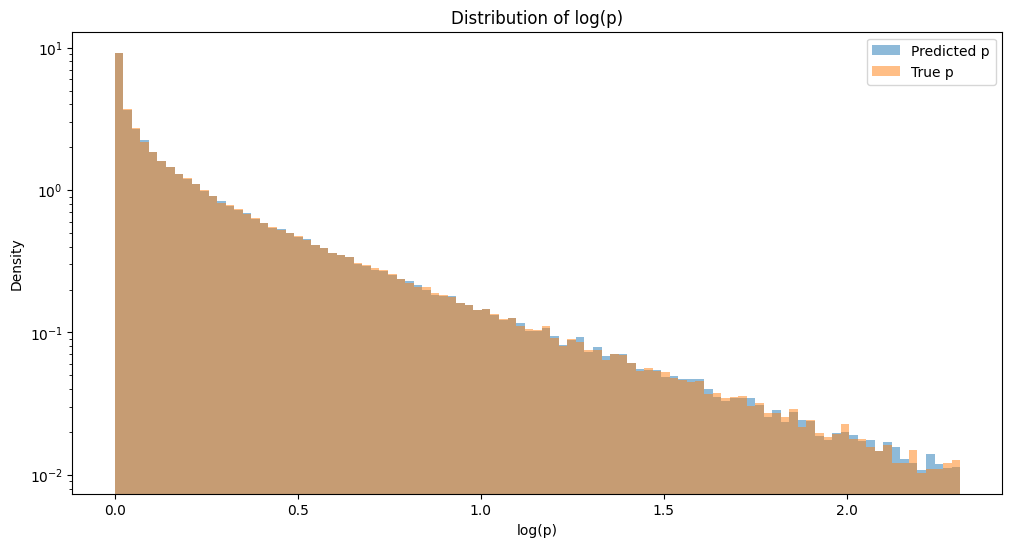

In [ ]:
# Show the distribution of p
plt.figure(figsize=(12, 6))
bins = np.linspace(0, np.max(np.log(p)), 100)
plt.hist(np.log(p), bins=bins, density=True, alpha=0.5, label="Predicted p")
# plt.hist(np.log(p2), bins=bins, density=True, alpha=0.5, label="True p")
plt.hist(np.log(p3), bins=bins, density=True, alpha=0.5, label="True p")
plt.xlabel("log(p)")
plt.ylabel("Density")
plt.title("Distribution of log(p)")
plt.legend()
plt.yscale("log")
# plt.savefig(output_dir / "p_distribution.png", format="png", bbox_inches="tight")
plt.show()

In [ ]:
bin_size = 0.1
eta_bins = np.arange(
    -(config["max_abs_eta"] + bin_size / 2),
    config["max_abs_eta"] + bin_size / 2 + bin_size,
    bin_size,
)
bin_centers = 0.5 * (eta_bins[:-1] + eta_bins[1:])

# model_data_bins = {}
model_data_bins = compute_resolution_bins(
    peta,
    eta_bins,
    pi_true_values,
    model_data["MSE"],
    model_data_bins,
    # model_name="MSE_truth_previous",
    model_name="MSE_truth_previous_finetuned_with_fix",
    # model_name="MSE_truth_previous_2",
    # model_name="MSE_truth_previous_3",
    # model_name="MSE_particles_truth_previous",
    # model_name=f"MSE_particles_truth_previous_batch_size_{dataset_wrapper.hparams.batch_size}",
    # model_name=f"MSE_particles_truth_previous_batch_size_{dataset_wrapper.hparams.batch_size}_unfixed_padding",
    # model_name=f"MSE_particles_truth_previous_batch_size_{dataset_wrapper.hparams.batch_size}_padding_{padding_length}",
)

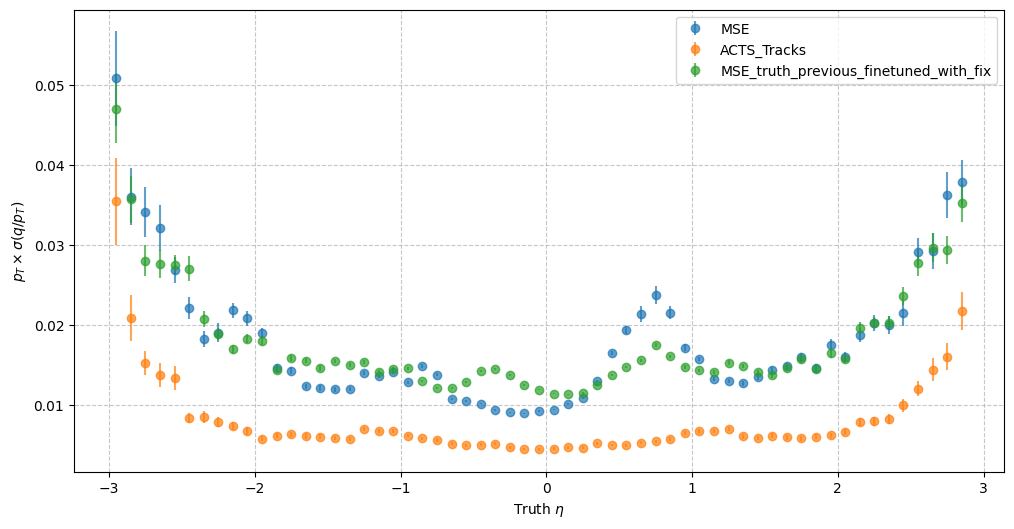

In [39]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name in model_data_bins:
    # if model_name in ["MSE", "ACTS_Tracks"]:
    #     continue
    # if "MSE_particles_truth" == model_name:
    #     continue
    # if "padding_30" in model_name:
    #     continue
    # if "padding_25" in model_name:
    #     continue
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(6e-3, 1)
plt.savefig(
    # output_dir / "relative_error_vs_peta_all_previous.png", format="png", bbox_inches="tight"
    # output_dir / "relative_error_vs_peta_all_previous_tests.png", format="png", bbox_inches="tight"
    output_dir / "relative_error_vs_peta_all_previous_tests_5.png", format="png", bbox_inches="tight"
)
plt.show()

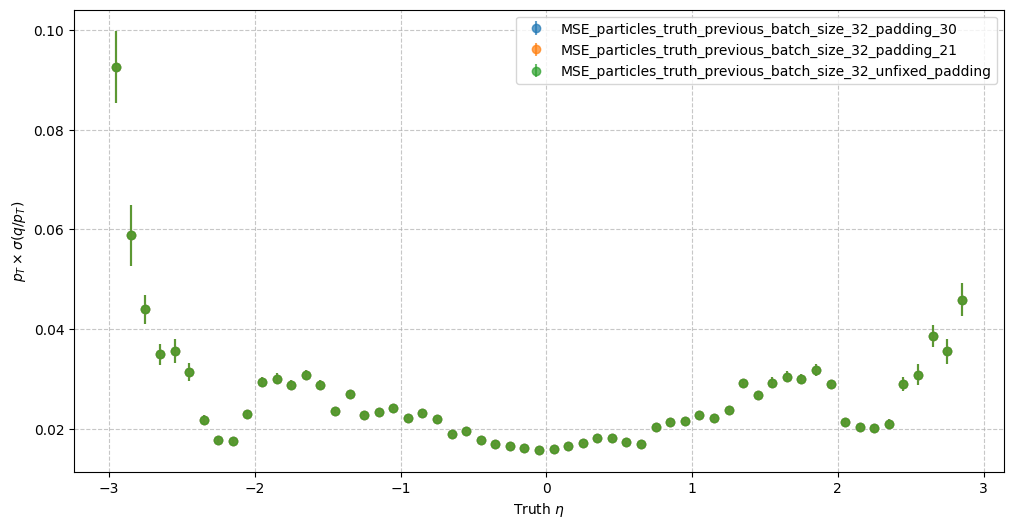

In [ ]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name in model_data_bins:
    # if model_name in ["MSE", "ACTS_Tracks"]:
    #     continue
    # if "MSE_particles_truth" == model_name:
    #     continue
    # if "padding_30" in model_name:
    #     continue
    # if "padding_25" in model_name:
    #     continue
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(6e-3, 1)
plt.savefig(
    # output_dir / "relative_error_vs_peta_all_previous.png", format="png", bbox_inches="tight"
    # output_dir / "relative_error_vs_peta_all_previous_tests.png", format="png", bbox_inches="tight"
    output_dir / "relative_error_vs_peta_all_previous_tests_5.png", format="png", bbox_inches="tight"
)
plt.show()

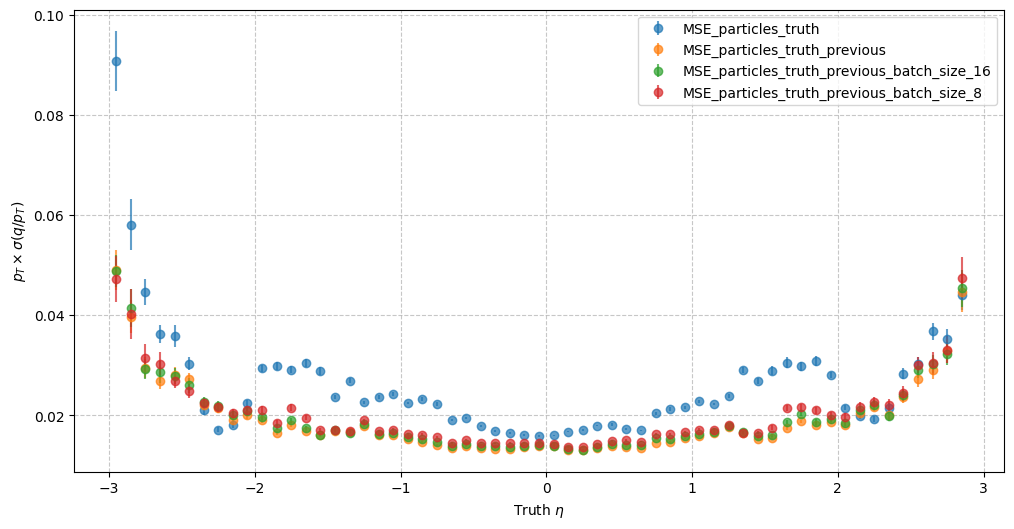

In [ ]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name in model_data_bins:
    if model_name in ["MSE", "ACTS_Tracks"]:
        continue
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(6e-3, 1)
plt.savefig(
    # output_dir / "relative_error_vs_peta_all_previous.png", format="png", bbox_inches="tight"
    # output_dir / "relative_error_vs_peta_all_previous_tests.png", format="png", bbox_inches="tight"
    output_dir / "relative_error_vs_peta_all_previous_tests_2.png", format="png", bbox_inches="tight"
)
plt.show()

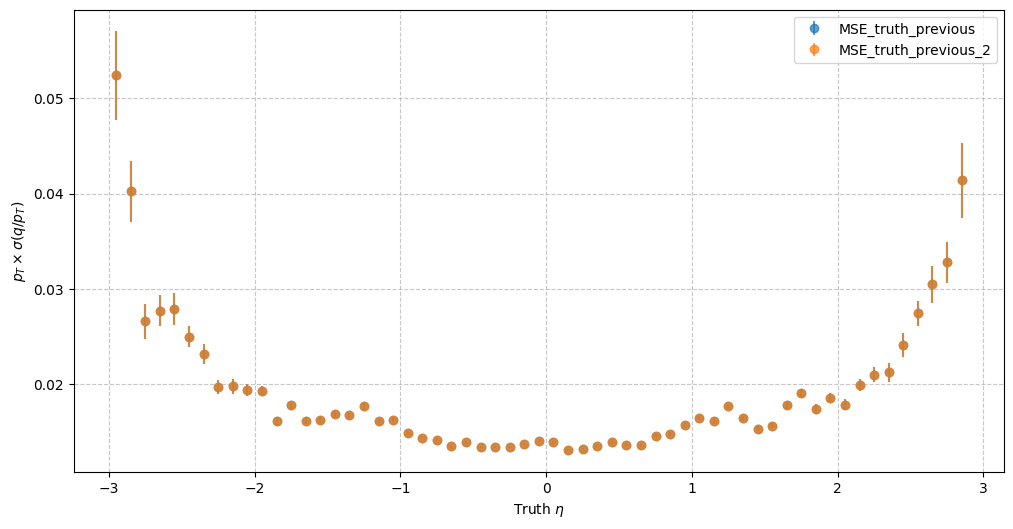

In [ ]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name in model_data_bins:
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(6e-3, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta.png", format="png", bbox_inches="tight"
)
plt.show()

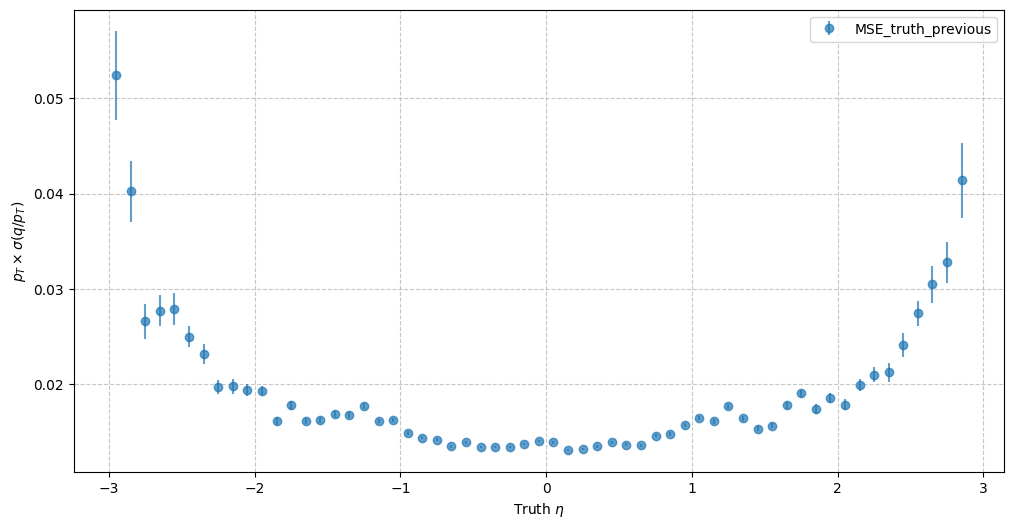

In [35]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name in model_data_bins:
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(6e-3, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta.png", format="png", bbox_inches="tight"
)
plt.show()

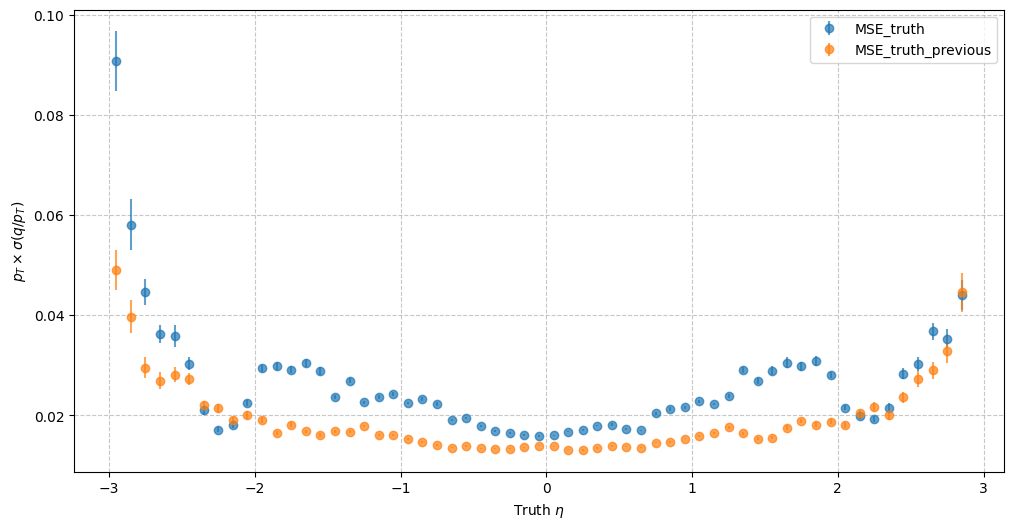

In [ ]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name in model_data_bins:
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(6e-3, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta.png", format="png", bbox_inches="tight"
)
plt.show()